# **Big Data Analytics Project: Kimia Farma Business Performance Analysis**

## **By: Grace Natalie Catherine**

In [48]:
# import libraries untuk data cleaning, manipulation and exploratory data analysis
import pandas as pd
import numpy as np

# import libraries untuk data visualization
import seaborn as sns
import matplotlib.pyplot as plt
import squarify

# import libraries untuk uji statistik
from scipy.stats import shapiro # Uji Normalitas
from scipy.stats import mannwhitneyu, kruskal  # Non Parametrik
from scipy.stats import chi2_contingency # Uji Chi-Square

# fungsi untuk menampilkan semua kolom DataFrame saat membaca datasetnya di output
pd.set_option('display.max_columns', None)

# fungsi untuk ignore warnings
import warnings
warnings.filterwarnings("ignore")

# **1. Business Understanding**

## **Business Context**

Kimia Farma is one of Indonesia's largest integrated pharmaceutical companies, operating an extensive network of pharmacies across the country. Every day, the company generates large volumes of transactional, product, branch, and inventory data through its nationwide operations.

As business operations continue to expand, leveraging historical business data becomes increasingly important for monitoring company performance, identifying sales trends, evaluating branch performance, and understanding regional business contributions. Data-driven insights enable management to optimize operational efficiency, improve customer experience, and formulate more effective business strategies.

This project integrates transactional, product, branch, and inventory datasets to analyze Kimia Farma's business performance and transform raw data into meaningful insights.

## **Problem Statement**

Kimia Farma operates one of Indonesia's largest pharmacy networks, generating substantial volumes of transactional data across its branches nationwide. To support business growth and operational excellence, management requires a comprehensive understanding of business performance across different regions and over time.

Kimia Farma experienced a decline in Sales in 2021 and 2023. This decline may have been influenced by several factors, including branch and operational performance, service quality, product performance, pricing and discount strategies, customer purchasing behavior, and other external or seasonal effects.

The key business challenge is to **identify and assess the factors contributing to the Net Sales decline and identify the key areas that require attention and improvement.**

The questions for these analysis:
- How was the business performance? How significant the decline in in 2021 and 2023?
- Did Transaction Volume, Net Sales, and Average Sales per Transaction decline?
- Which provinces and branches contributed most to the decline?
- Which products were the biggest contributors?
- Was the decline driven by transaction volume, product performance, pricing/discounts, operational/service quality, or seasonality?
- Among these factors, which had the strongest impact on the Net Sales decline?

## **Goals**

The goals of this project: 

1. Assess Business Performance
- Evaluate the YoY changes in Transaction Volume, Net Sales, and Average Sales per Transaction.
2. Identify & Evaluate Key Drivers
- Identify the provinces, branches, and products contributing most to the decline.
- Assess whether the decline was associated with transaction volume, product performance, pricing/discounts operational/service quality, customer purchasing behavior, or seasonality.
3. Identify Priority Areas for Improvement
- Determine the key areas and factors requiring the most attention based on their contribution to the decline.
- Provide a basis for targeted business actions to support Net Sales recovery.

## **2. Data Understanding**

The analysis integrates four business datasets:

- kf_final_transaction : Transaction records
- kf_product : Product information
- kf_kantor_cabang : Branch information
- kf_inventory : Inventory data

The datasets were integrated into a master analytical table using SQL joins in Google BigQuery before being analyzed with Python and visualized in Looker Studio.

| Column                    | Description                                 |
| ------------------------- | ------------------------------------------- |
| `transaction_id`          | Transaction ID                              |
| `date`                    | Transaction date                            |
| `branch_id`               | Branch ID                                   |
| `branch_name`             | Branch name                                 |
| `kota`                    | Branch city                                 |
| `provinsi`                | Branch province                             |
| `rating_cabang`           | Branch rating                               |
| `customer_name`           | Customer name                               |
| `product_id`              | Product ID                                  |
| `product_name`            | Product name                                |
| `actual_price`            | Actual product price                        |
| `discount_percentage`     | Discount percentage                         |
| `gross_profit_percentage` | Gross profit percentage                     |
| `nett_sales`              | Net sales after discount                    |
| `nett_profit`             | Net profit                                  |
| `rating_transaksi`        | Transaction rating                          |
| `opname_stock`            | Stock quantity recorded during stock opname |


In [ ]:
# read dataset

df = pd.read_csv('kf_bigdata_analysis.csv')

df.head()

,transaction_id,date,branch_id,branch_name,kota,provinsi,rating_cabang,customer_name,product_id,product_name,actual_price,discount_percentage,gross_profit_percentage,nett_sales,nett_profit,rating_transaksi,opname_stock
0,TRX5103706,2021-08-25,93529,Kimia Farma - Klinik & Apotek,Yogyakarta,DI Yogyakarta,4.3,Derrick Wright III,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.10,0.2,226530.0,45306.0,3.0,72.0
1,TRX5388139,2020-12-29,24832,Kimia Farma - Klinik-Apotek-Laboratorium,Pekanbaru,Riau,4.2,Elizabeth Ramos,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.12,0.2,221496.0,44299.2,3.0,67.0
2,TRX7251897,2020-02-03,20505,Kimia Farma - Apotek,Cilacap,Jawa Tengah,4.5,Meghan Warner,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.09,0.2,229047.0,45809.4,3.0,68.0
3,TRX4943675,2022-09-09,17678,Kimia Farma - Klinik & Apotek,Subang,Jawa Barat,4.8,Steven Roberts,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.10,0.2,226530.0,45306.0,3.0,19.0
4,TRX3469820,2020-06-20,28315,Kimia Farma - Klinik-Apotek-Laboratorium,Sukabumi,Jawa Barat,3.9,Linda Bruce DDS,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.07,0.2,234081.0,46816.2,3.0,66.0


In [50]:
# initial info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 672458 entries, 0 to 672457
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           672458 non-null  str    
 1   date                     672458 non-null  str    
 2   branch_id                672458 non-null  int64  
 3   branch_name              672458 non-null  str    
 4   kota                     672458 non-null  str    
 5   provinsi                 672458 non-null  str    
 6   rating_cabang            672458 non-null  float64
 7   customer_name            672458 non-null  str    
 8   product_id               672458 non-null  str    
 9   product_name             672458 non-null  str    
 10  actual_price             672458 non-null  int64  
 11  discount_percentage      672458 non-null  float64
 12  gross_profit_percentage  672458 non-null  float64
 13  nett_sales               672458 non-null  float64
 14  nett_profit    

- There are missing values in opname_stock in dataset. This will be taken care during the data cleaning process.
- The `date` column is in incorrect datetime format. This will be taken care of during the data cleaning process.

In [51]:
# dataset overview

variables = []
data_type = []
null = []
null_percentage = []
nuniq = []
uniq_values = []

for col in df.columns:
    variables.append(col)
    data_type.append(df[col].dtype)
    null.append(df[col].isna().sum())
    null_percentage.append(round((df[col].isna().sum() / len(df)) * 100, 2))
    nuniq.append(df[col].nunique())
    uniq_values.append(df[col].drop_duplicates().sample(min(2, df[col].nunique())).values)

df_desc = pd.DataFrame({
    'features': variables,
    'datatype': data_type,
    'null': null,
    'null_pct': null_percentage,
    'unique': nuniq,
    'unique_values': uniq_values
})

df_desc

,features,datatype,null,null_pct,unique,unique_values
0,transaction_id,str,0,0.00,672458,"[TRX6654647, TRX9439988]"
1,date,str,0,0.00,1460,"[2020-03-12, 2022-02-25]"
2,branch_id,int64,0,0.00,1725,"[66615, 94852]"
3,branch_name,str,0,0.00,3,"[Kimia Farma - Klinik-Apotek-Laboratorium, Kim..."
4,kota,str,0,0.00,70,"[Padang Sidempuan, Cilacap]"
5,provinsi,str,0,0.00,31,"[Aceh, Papua Barat]"
6,rating_cabang,float64,0,0.00,12,"[4.0, 4.4]"
7,customer_name,str,0,0.00,264601,"[Stephanie Watson, Desiree Mercado]"
8,product_id,str,0,0.00,150,"[KF381, KF943]"
9,product_name,str,0,0.00,8,"[Other analgesics and antipyretics, Pyrazolone..."


## **3. Data Cleaning and Preprocessing**

### **Change String to Date Format**

In [52]:
df_clean = df.copy()

In [53]:
df_clean['date'] = pd.to_datetime(df_clean['date'])

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 672458 entries, 0 to 672457
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   transaction_id           672458 non-null  str           
 1   date                     672458 non-null  datetime64[us]
 2   branch_id                672458 non-null  int64         
 3   branch_name              672458 non-null  str           
 4   kota                     672458 non-null  str           
 5   provinsi                 672458 non-null  str           
 6   rating_cabang            672458 non-null  float64       
 7   customer_name            672458 non-null  str           
 8   product_id               672458 non-null  str           
 9   product_name             672458 non-null  str           
 10  actual_price             672458 non-null  int64         
 11  discount_percentage      672458 non-null  float64       
 12  gross_profit_percentage  67

- The `date` column is already cleaned to correct datetime format.

**Drop the missing values in opname_stock variable**

In [54]:
df_clean.dropna(inplace=True)

#check 
df_clean.info()


<class 'pandas.DataFrame'>
Index: 660122 entries, 0 to 672457
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   transaction_id           660122 non-null  str           
 1   date                     660122 non-null  datetime64[us]
 2   branch_id                660122 non-null  int64         
 3   branch_name              660122 non-null  str           
 4   kota                     660122 non-null  str           
 5   provinsi                 660122 non-null  str           
 6   rating_cabang            660122 non-null  float64       
 7   customer_name            660122 non-null  str           
 8   product_id               660122 non-null  str           
 9   product_name             660122 non-null  str           
 10  actual_price             660122 non-null  int64         
 11  discount_percentage      660122 non-null  float64       
 12  gross_profit_percentage  660122 

### **Feature Generation**

In [55]:
df_clean['date'] = pd.to_datetime(df_clean['date'])

# Generate Year
df_clean['year'] = df_clean['date'].dt.year

# Generate Month-Year
df_clean['month_year'] = df_clean['date'].dt.strftime('%m-%Y')  # Format: MM-YYYY

# Generate Month
df_clean['month'] = df_clean['date'].dt.month

# check
df_clean.head()

,transaction_id,date,branch_id,branch_name,kota,provinsi,rating_cabang,customer_name,product_id,product_name,actual_price,discount_percentage,gross_profit_percentage,nett_sales,nett_profit,rating_transaksi,opname_stock,year,month_year,month
0,TRX5103706,2021-08-25,93529,Kimia Farma - Klinik & Apotek,Yogyakarta,DI Yogyakarta,4.3,Derrick Wright III,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.10,0.2,226530.0,45306.0,3.0,72.0,2021,08-2021,8
1,TRX5388139,2020-12-29,24832,Kimia Farma - Klinik-Apotek-Laboratorium,Pekanbaru,Riau,4.2,Elizabeth Ramos,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.12,0.2,221496.0,44299.2,3.0,67.0,2020,12-2020,12
2,TRX7251897,2020-02-03,20505,Kimia Farma - Apotek,Cilacap,Jawa Tengah,4.5,Meghan Warner,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.09,0.2,229047.0,45809.4,3.0,68.0,2020,02-2020,2
3,TRX4943675,2022-09-09,17678,Kimia Farma - Klinik & Apotek,Subang,Jawa Barat,4.8,Steven Roberts,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.10,0.2,226530.0,45306.0,3.0,19.0,2022,09-2022,9
4,TRX3469820,2020-06-20,28315,Kimia Farma - Klinik-Apotek-Laboratorium,Sukabumi,Jawa Barat,3.9,Linda Bruce DDS,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.07,0.2,234081.0,46816.2,3.0,66.0,2020,06-2020,6


### **Numerical Variable Distributions and Outlier Detection**

In [56]:
# define numerical columns

num_cols = [
    'actual_price',
    'discount_percentage',
    'gross_profit_percentage',
    'nett_sales',
    'nett_profit',
    'rating_cabang',
    'rating_transaksi'
]

In [57]:
# Outlier Detection using IQR Method

outlier_summary = []

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    
    outlier_summary.append({
        'Features': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier Percentage': round((len(outliers) / len(df_clean)) * 100, 2)
    })

df_outlier = pd.DataFrame(outlier_summary)

df_outlier

,Features,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,actual_price,296900.00,757900.00,461000.00,-394600.000,1449400.000,0,0.0
1,discount_percentage,0.04,0.11,0.07,-0.065,0.215,0,0.0
2,gross_profit_percentage,0.20,0.30,0.10,0.050,0.450,0,0.0
3,nett_sales,273702.00,703380.00,429678.00,-370815.000,1347897.000,0,0.0
4,nett_profit,56271.60,211014.00,154742.40,-175842.000,443127.600,0,0.0
5,rating_cabang,4.20,4.70,0.50,3.450,5.450,0,0.0
6,rating_transaksi,3.50,4.50,1.00,2.000,6.000,0,0.0


**Boxplot for Numerical Variables**

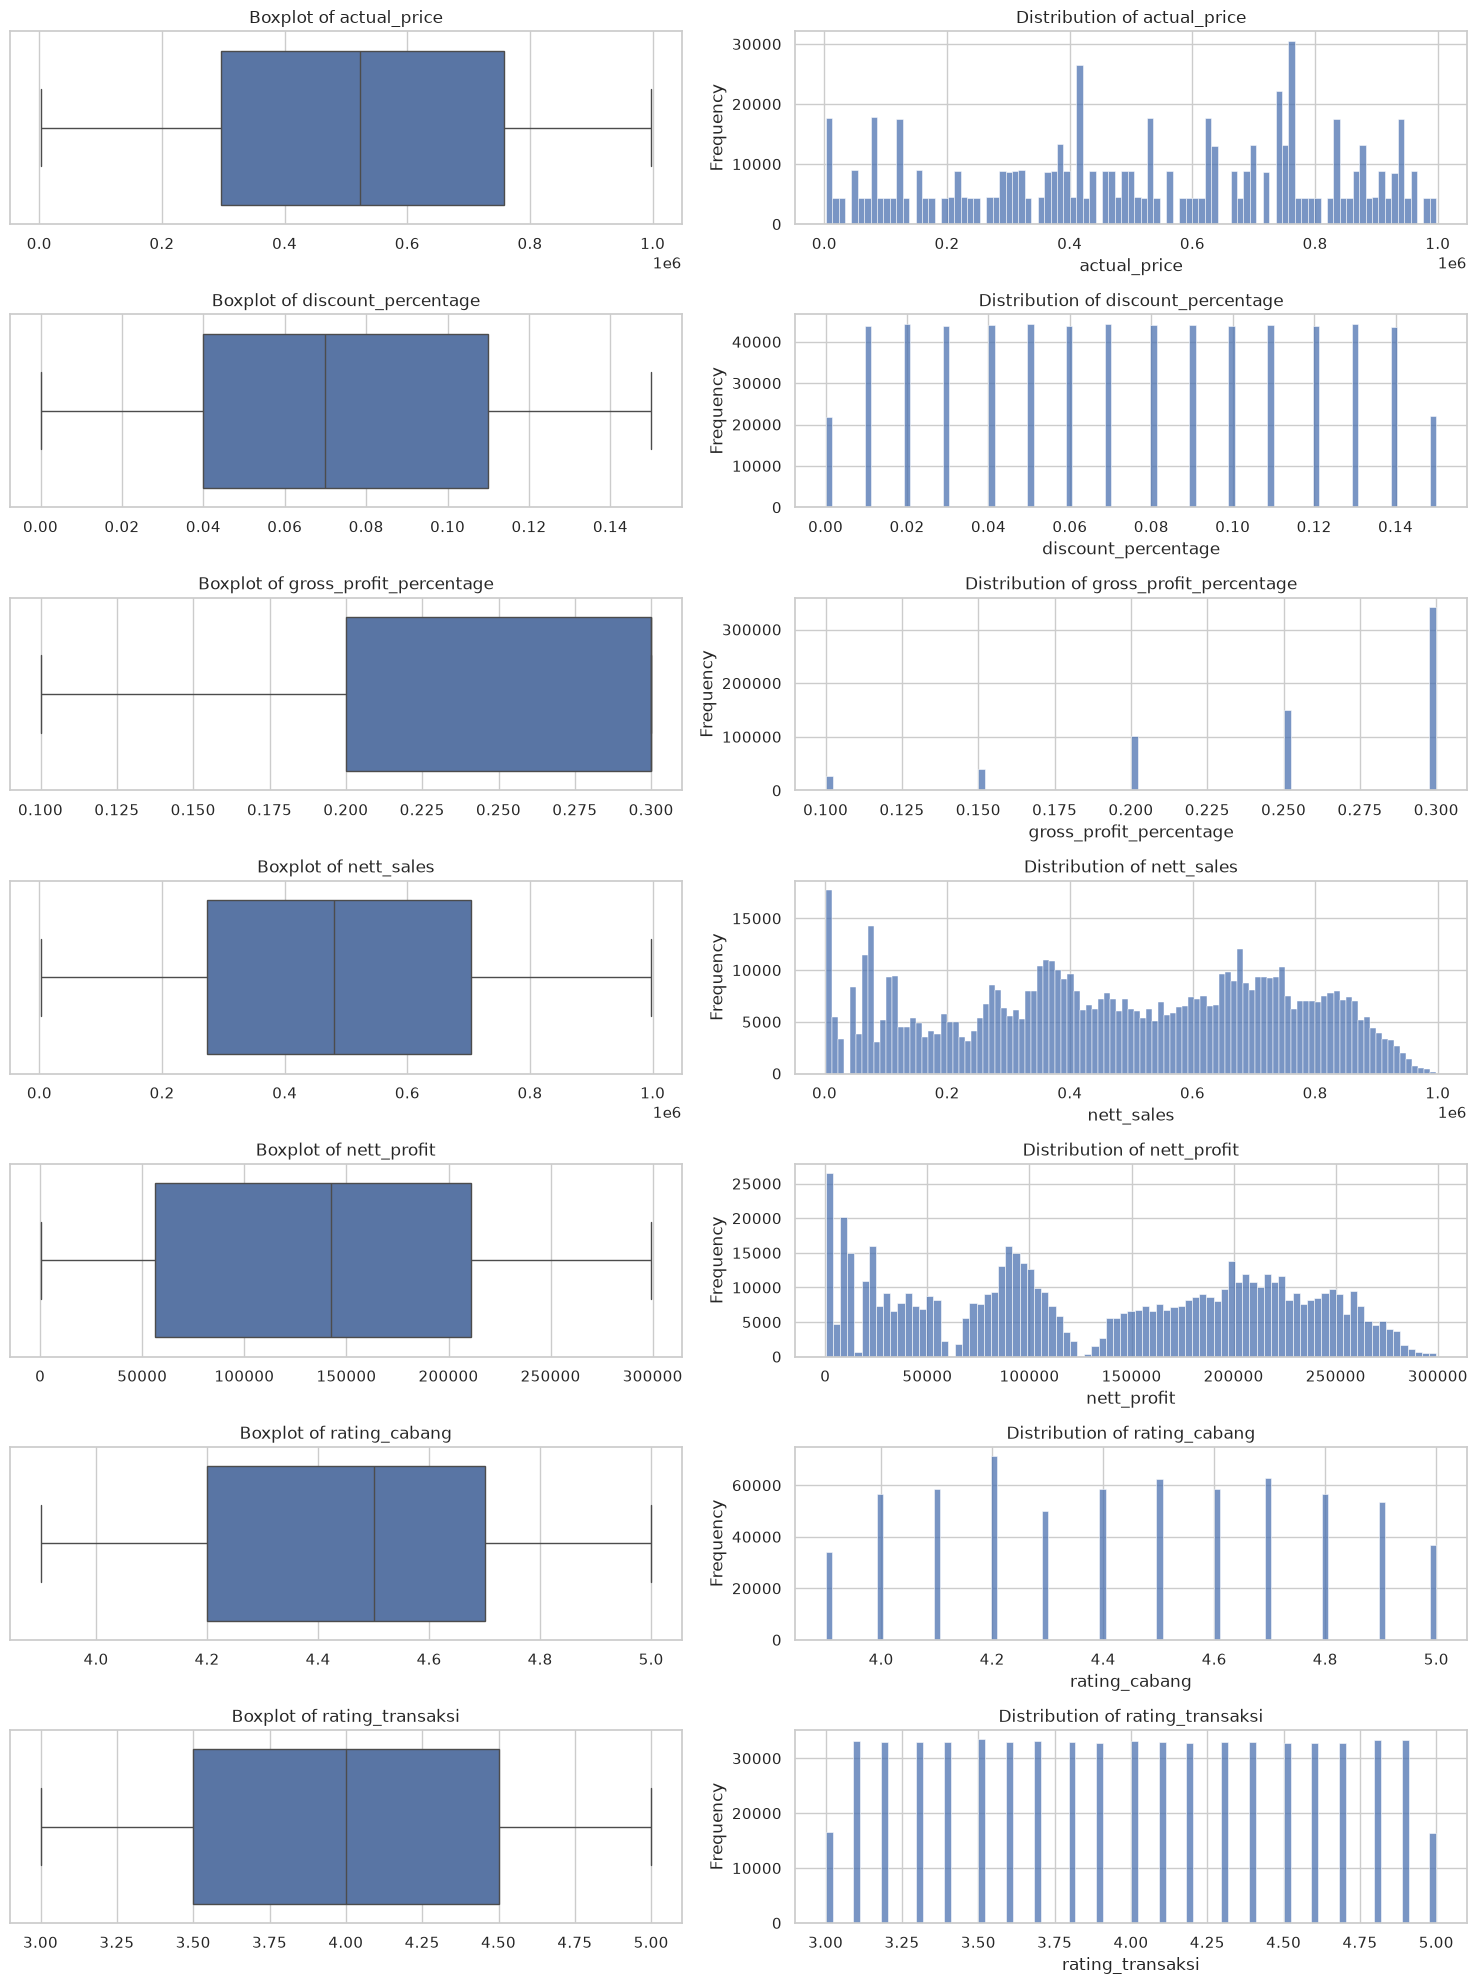

In [58]:
# Boxplot and Histogram for numerical variables

if len(num_cols) > 0:
    plt.figure(figsize=(15, 20))

    for i, col in enumerate(num_cols, 1):
        
        # Boxplot
        plt.subplot(len(num_cols), 2, 2*i-1)
        sns.boxplot(x=df_clean[col])
        plt.title(f'Boxplot of {col}')
        plt.xlabel('')
        
        # Histogram
        plt.subplot(len(num_cols), 2, 2*i)
        sns.histplot(df_clean[col])
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

- Based on outlier detection with IQR method and boxplot method, there are no outliers in the dataset.
- The data is not normally distributed.

In [59]:
# Save the cleaned dataset

df_clean.to_csv('kf_bigdata_cleaned.csv', index=False)

# **4. Exploratory Data Analysis (EDA)**

## **Heatmap of Correlation Matrix**

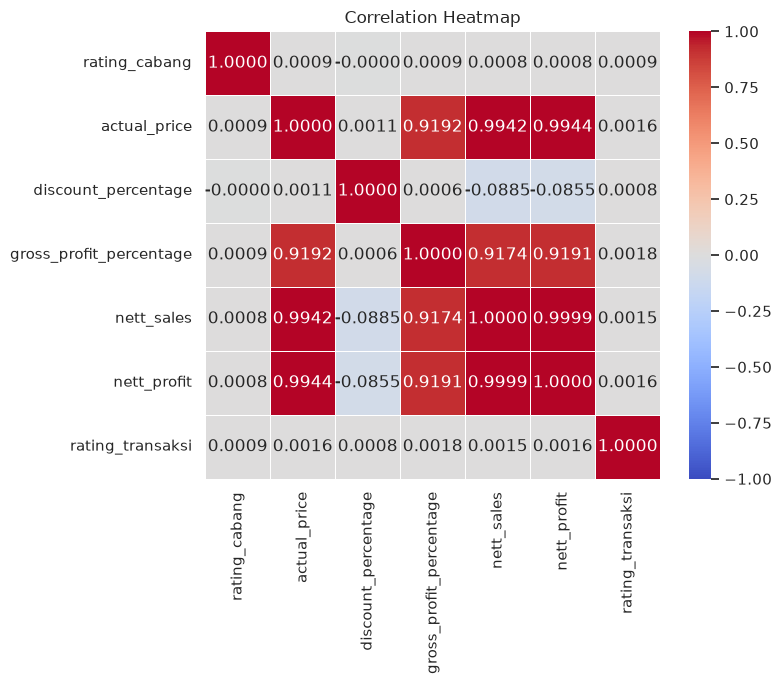

In [60]:
cols = [
    "rating_cabang",
    "actual_price",
    "discount_percentage",
    "gross_profit_percentage",
    "nett_sales",
    "nett_profit",
    "rating_transaksi"
]

# correlation matrix (Spearman) because the data is not normally distributed
corr_matrix = df_clean[cols].corr(method="spearman")

# Plot heatmap
plt.figure(figsize=(8, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

1. **`actual_price` ↔ `nett_sales` = 0.99** <br>
   There is a **very strong positive correlation**. Higher actual prices tend to be associated with higher net sales. This is expected because `nett_sales` is directly calculated from `actual_price` and `discount_percentage`.

2. **`actual_price` ↔ `nett_profit` = 0.99** <br>
   There is also a **very strong positive correlation**. Higher-priced transactions tend to generate higher net profit. This is expected because net profit is calculated based on net sales and gross profit percentage.

3. **`nett_sales` ↔ `nett_profit` = 1.00** <br>
   This indicates an **almost perfect positive correlation**. However, this is expected because `nett_profit` is directly derived from `nett_sales`.

4. **`actual_price` ↔ `gross_profit_percentage` = 0.92** <br>
   There is a **strong positive correlation**. This relationship is expected because the gross profit percentage is determined based on the actual price ranges.

5. **`discount_percentage` ↔ `nett_sales` and `nett_profit` = -0.09** <br>
   There is a **very weak negative correlation**. Although higher discounts theoretically reduce net sales and net profit, the relationship is weak in this dataset.

6. **`rating_cabang` and `rating_transaksi`** <br>
   Both ratings show **almost no correlation** with the financial variables, suggesting that price, sales, and profit do not have a strong linear relationship with customer or branch ratings.

The correlation analysis shows very strong positive relationships between actual price, net sales, and net profit. However, these strong correlations are expected because net sales and net profit are derived from the pricing and profit formulas. Meanwhile, **discount percentage has a weak negative relationship with net sales**, while **branch and transaction ratings show almost no correlation** with the financial variables.


## **1. Year-over-Year Net Sales/Year-over-Year Sales Trend**

In [61]:
df_clean

,transaction_id,date,branch_id,branch_name,kota,provinsi,rating_cabang,customer_name,product_id,product_name,actual_price,discount_percentage,gross_profit_percentage,nett_sales,nett_profit,rating_transaksi,opname_stock,year,month_year,month
0,TRX5103706,2021-08-25,93529,Kimia Farma - Klinik & Apotek,Yogyakarta,DI Yogyakarta,4.3,Derrick Wright III,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.10,0.20,226530.0,45306.00,3.0,72.0,2021,08-2021,8
1,TRX5388139,2020-12-29,24832,Kimia Farma - Klinik-Apotek-Laboratorium,Pekanbaru,Riau,4.2,Elizabeth Ramos,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.12,0.20,221496.0,44299.20,3.0,67.0,2020,12-2020,12
2,TRX7251897,2020-02-03,20505,Kimia Farma - Apotek,Cilacap,Jawa Tengah,4.5,Meghan Warner,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.09,0.20,229047.0,45809.40,3.0,68.0,2020,02-2020,2
3,TRX4943675,2022-09-09,17678,Kimia Farma - Klinik & Apotek,Subang,Jawa Barat,4.8,Steven Roberts,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.10,0.20,226530.0,45306.00,3.0,19.0,2022,09-2022,9
4,TRX3469820,2020-06-20,28315,Kimia Farma - Klinik-Apotek-Laboratorium,Sukabumi,Jawa Barat,3.9,Linda Bruce DDS,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.07,0.20,234081.0,46816.20,3.0,66.0,2020,06-2020,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672453,TRX2548361,2020-09-21,35578,Kimia Farma - Klinik-Apotek-Laboratorium,Banjarmasin,Kalimantan Selatan,4.4,Carol Shaffer,KF999,"Other analgesics and antipyretics, Pyrazolones...",389900,0.14,0.25,335314.0,83828.50,5.0,97.0,2020,09-2020,9
672454,TRX8455646,2023-11-21,36600,Kimia Farma - Klinik-Apotek-Laboratorium,Palu,Sulawesi Tengah,4.6,Jennifer Doyle,KF999,"Other analgesics and antipyretics, Pyrazolones...",389900,0.14,0.25,335314.0,83828.50,5.0,19.0,2023,11-2023,11
672455,TRX4899796,2023-12-18,62661,Kimia Farma - Klinik & Apotek,Medan,Sumatera Utara,4.9,James Delacruz,KF999,"Other analgesics and antipyretics, Pyrazolones...",389900,0.06,0.25,366506.0,91626.50,5.0,84.0,2023,12-2023,12
672456,TRX2779359,2022-04-14,52479,Kimia Farma - Klinik-Apotek-Laboratorium,Tanjungpinang,Kepulauan Riau,4.4,Christopher Campos,KF999,"Other analgesics and antipyretics, Pyrazolones...",389900,0.01,0.25,386001.0,96500.25,5.0,100.0,2022,04-2022,4


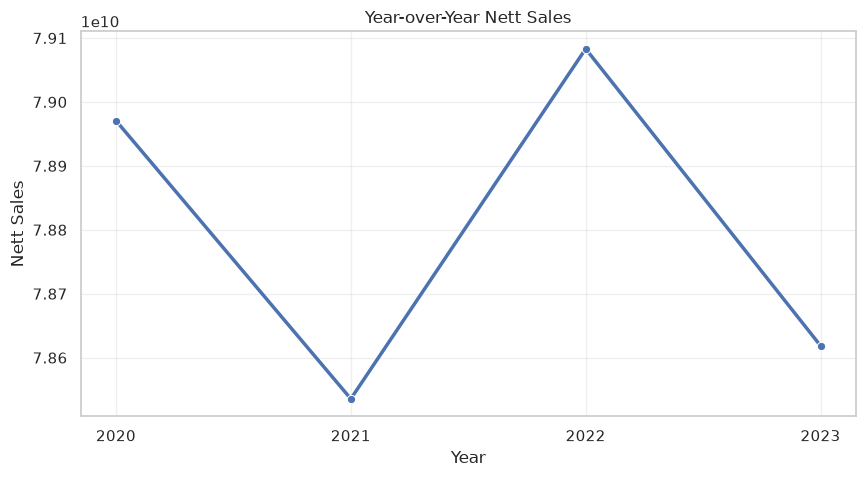

In [62]:
# Nett_sales by Year
sales_by_year = df_clean.groupby('year')['nett_sales'].sum().reset_index()

# Line chart
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=sales_by_year,
    x='year',
    y='nett_sales',
    marker='o',
    linewidth=2.5
)

plt.title('Year-over-Year Nett Sales')
plt.xlabel('Year')
plt.ylabel('Nett Sales')
plt.xticks(sales_by_year['year'])
plt.grid(True, alpha=0.3)

plt.show()

- Net Sales fluctuated over the four-year period, significantly declining in 2021, recovering significantly in 2022, and significantly declining again in 2023, indicating inconsistent year-over-year business growth.
- Will further investigate the factors contributing to these fluctuations.

### **Investigate YoY transaction volume vs nett sales vs average sales per transaction:**

In [63]:
sales_analysis = df_clean.groupby('year').agg(
    total_transactions=('transaction_id', 'nunique'),
    total_nett_sales=('nett_sales', 'sum')
).reset_index()

# Average net sales per transaction
sales_analysis['avg_nett_sales'] = (
    sales_analysis['total_nett_sales'] /
    sales_analysis['total_transactions']
)

# Calculate YoY percentage change
sales_analysis['transactions_change_pct'] = (
    sales_analysis['total_transactions'].pct_change() * 100
)

sales_analysis['nett_sales_change_pct'] = (
    sales_analysis['total_nett_sales'].pct_change() * 100
)

sales_analysis['avg_nett_sales_change_pct'] = (
    sales_analysis['avg_nett_sales'].pct_change() * 100
)

# Round all numeric columns to 2 decimal places
sales_analysis = sales_analysis.round(2)

sales_analysis['total_transactions'] = (
    sales_analysis['total_transactions'] / 1000
).map(lambda x: f"{x:.3f}K")

sales_analysis['total_nett_sales'] = (
    sales_analysis['total_nett_sales'] / 1000000000
).map(lambda x: f"{x:.3f}B")

sales_analysis['avg_nett_sales'] = (
    sales_analysis['avg_nett_sales'] / 1000
).map(lambda x: f"{x:.3f}M")

sales_analysis

,year,total_transactions,total_nett_sales,avg_nett_sales,transactions_change_pct,nett_sales_change_pct,avg_nett_sales_change_pct
0,2020,165.552K,78.971B,477.015M,NaN,NaN,NaN
1,2021,164.622K,78.536B,477.066M,-0.56,-0.55,0.01
2,2022,165.576K,79.083B,477.625M,0.58,0.70,0.12
3,2023,164.372K,78.619B,478.297M,-0.73,-0.59,0.14


- 2021: Transactions decreased by 0.57%, resulting in a 0.5% decline in net sales. However, the average transaction value increased by 0.07%.
- 2022: Transactions increased by 0.56%, resulting in a 0.67% increase in net sales. The average transaction value also increased by 0.11%.
- 2023: Transactions decreased again by 0.7%, causing net sales to decline by 0.57%, even though the average transaction value increased by another 0.12%.

Insights:
- **Net sales move in line with transaction volume rather than average transaction value**. This means that when **the number of transactions decreases, total net sales also decline**, while the average value of each transaction actually increases.
- This indicates that the **main issue behind the decline in sales is not the transactions value/that customers are spending less per transaction**. Intead, **the decline in net sales is driven by a reduction in transaction volume**, because average net sales per transaction continues to increase.
- In other words, the company is still **generating relatively higher transaction values**, but **the number of transactions is significantly lower in 2021 and 2023**.

## **2. Seasonal Effect Analysis: Month-over-month & Daily Transactions and Nett Sales Trends**

#### **Month-over-month Analysis for Transaction Volume and Nett Sales Trends 2021 and 2023**

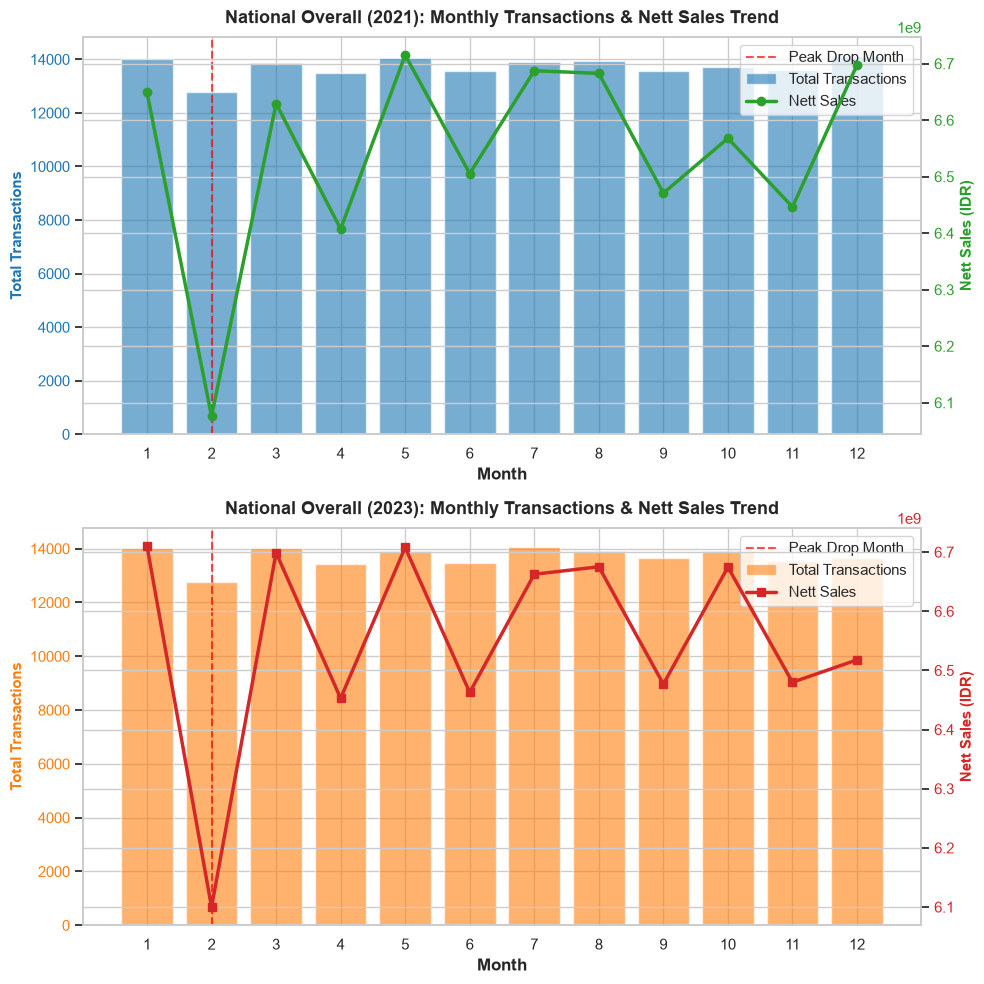

In [64]:
# 1. Map days per month for calendar normalization
days_in_month_map = {
    1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
    7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
}

# 2. Prepare Data for ALL Provinces and ALL Branches across years
df_national = df_clean.copy()
df_national['days_in_month'] = df_national['month'].map(days_in_month_map)

# 3. Group by Year and Month (Overall Aggregation)
national_summary = df_national.groupby(['year', 'month', 'days_in_month']).agg(
    total_transactions=('transaction_id', 'count'),
    total_sales=('nett_sales', 'sum')
).reset_index()

# 4. Calculate Daily Average Transactions & MoM % Changes
national_summary['daily_avg_transactions'] = national_summary['total_transactions'] / national_summary['days_in_month']

national_summary['mom_transactions_change_pct'] = (
    national_summary.groupby('year')['total_transactions'].pct_change() * 100
)
national_summary['mom_daily_avg_change_pct'] = (
    national_summary.groupby('year')['daily_avg_transactions'].pct_change() * 100
)

# Separate DataFrames by Year (2021 and 2023)
national_2021 = national_summary[national_summary['year'] == 2021].sort_values('month').reset_index(drop=True)
national_2023 = national_summary[national_summary['year'] == 2023].sort_values('month').reset_index(drop=True)

# 5. VISUALIZATION
# =========================================================

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=False)

# Identify Peak Drop Month for 2021
peak_drop_2021 = national_2021.loc[national_2021['mom_transactions_change_pct'].idxmin()]

# --- CHART 1: OVERALL / ALL PROVINCES (2021) ---
ax1 = axes[0]
color_tx1 = '#1f77b4'
color_sales1 = '#2ca02c'

# Bar plot: Total Transactions
bars1 = ax1.bar(
    national_2021['month'], 
    national_2021['total_transactions'], 
    color=color_tx1, 
    alpha=0.6, 
    label='Total Transactions'
)
ax1.set_xlabel('Month', fontweight='bold')
ax1.set_ylabel('Total Transactions', color=color_tx1, fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_tx1)
ax1.set_xticks(national_2021['month'])
ax1.set_title('National Overall (2021): Monthly Transactions & Nett Sales Trend', fontsize=13, fontweight='bold', pad=10)

# Line plot: Nett Sales (Secondary Y-Axis)
ax1_twin = ax1.twinx()
line1 = ax1_twin.plot(
    national_2021['month'], 
    national_2021['total_sales'], 
    color=color_sales1, 
    marker='o', 
    linewidth=2.5, 
    label='Nett Sales'
)
ax1_twin.set_ylabel('Nett Sales (IDR)', color=color_sales1, fontsize=11, fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor=color_sales1)

# Highlight Peak Drop Month (February)
drop_month_2021 = int(peak_drop_2021['month'])
ax1.axvline(x=drop_month_2021, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Peak Drop Month')

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines1_twin, labels1_twin = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines1_twin, labels1 + labels1_twin, loc='upper right')


# --- CHART 2: OVERALL / ALL PROVINCES (2023) ---
ax2 = axes[1]
color_tx2 = '#ff7f0e'
color_sales2 = '#d62728'

# Bar plot: Total Transactions
bars2 = ax2.bar(
    national_2023['month'], 
    national_2023['total_transactions'], 
    color=color_tx2, 
    alpha=0.6, 
    label='Total Transactions'
)
ax2.set_xlabel('Month', fontweight='bold')
ax2.set_ylabel('Total Transactions', color=color_tx2, fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_tx2)
ax2.set_xticks(national_2023['month'])
ax2.set_title('National Overall (2023): Monthly Transactions & Nett Sales Trend', fontsize=13, fontweight='bold', pad=10)

# Line plot: Nett Sales (Secondary Y-Axis)
ax2_twin = ax2.twinx()
line2 = ax2_twin.plot(
    national_2023['month'], 
    national_2023['total_sales'], 
    color=color_sales2, 
    marker='s', 
    linewidth=2.5, 
    label='Nett Sales'
)
ax2_twin.set_ylabel('Nett Sales (IDR)', color=color_sales2, fontsize=11, fontweight='bold')
ax2_twin.tick_params(axis='y', labelcolor=color_sales2)

# Highlight Peak Drop Month (February - Month 2)
ax2.axvline(x=2, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Peak Drop Month')

# Combined Legend
lines2, labels2 = ax2.get_legend_handles_labels()
lines2_twin, labels2_twin = ax2_twin.get_legend_handles_labels()
ax2.legend(lines2 + lines2_twin, labels2 + labels2_twin, loc='upper right')

plt.tight_layout()
plt.show()

Overall MoM Analysis Insights:
- Recurring Pattern: **February (Month 2) represents the sharpest drop (peak drop) nationally across different years (2021 and 2023)**. **The drop in transaction volume directly correlates with a sharp decline in Nett Sales**.

#### **Average Daily Volume Transactions Analysis from January and February 2021 and 2023**

In [65]:
# Filter data at the national level for January & February (2021 and 2023)
df_feb_test_national = df_clean[
    (
        (df_clean['year'].isin([2021, 2023])) &
        (df_clean['month'].isin([1, 2]))
    )
].copy()


# 1. Macro Aggregation (National): Transactions and Sales per Year and Month
daily_summary_national = df_feb_test_national.groupby(
    ['year', 'month']
).agg(
    total_transactions=('transaction_id', 'count'),
    total_sales=('nett_sales', 'sum')
).reset_index()


# Set the number of operating days
daily_summary_national['days_in_month'] = daily_summary_national['month'].apply(
    lambda x: 31 if x == 1 else 28
)


# Calculate Normalized Daily Metrics (Averages)
daily_summary_national['daily_avg_transactions'] = (
    daily_summary_national['total_transactions'] /
    daily_summary_national['days_in_month']
).round(2)

daily_summary_national['daily_avg_sales'] = (
    daily_summary_national['total_sales'] /
    daily_summary_national['days_in_month']
).round(2)


# Calculate MoM % Change for Daily Averages
daily_summary_national['mom_pct_daily_transactions'] = (
    daily_summary_national
    .groupby(['year'])['daily_avg_transactions']
    .pct_change() * 100
).round(2)

daily_summary_national['mom_pct_daily_sales'] = (
    daily_summary_national
    .groupby(['year'])['daily_avg_sales']
    .pct_change() * 100
).round(2)


# Helper function to format large values into readable strings (B / M)
def format_currency(val):
    if pd.isna(val):
        return val
    if abs(val) >= 1e9:
        return f"{val / 1e9:.2f} B"  # Billion (Miliar)
    elif abs(val) >= 1e6:
        return f"{val / 1e6:.2f} M"  # Million (Juta)
    else:
        return f"{val:,.2f}"

# Create formatted display dataframe
display_df = daily_summary_national.copy()
display_df['total_sales_fmt'] = display_df['total_sales'].apply(format_currency)
display_df['daily_avg_sales_fmt'] = display_df['daily_avg_sales'].apply(format_currency)


# Display national aggregation results
print("NATIONAL DAILY AVERAGE TRANSACTIONS & SALES (2021 & 2023)\n")

display(
    display_df[
        [
            'year',
            'month',
            'days_in_month',
            'total_transactions',
            'daily_avg_transactions',
            'mom_pct_daily_transactions',
            'total_sales_fmt',
            'daily_avg_sales_fmt',
            'mom_pct_daily_sales'
        ]
    ].rename(columns={
        'total_sales_fmt': 'total_sales',
        'daily_avg_sales_fmt': 'daily_avg_sales'
    })
)

NATIONAL DAILY AVERAGE TRANSACTIONS & SALES (2021 & 2023)



,year,month,days_in_month,total_transactions,daily_avg_transactions,mom_pct_daily_transactions,total_sales,daily_avg_sales,mom_pct_daily_sales
0,2021,1,31,14000,451.61,NaN,6.65 B,214.49 M,NaN
1,2021,2,28,12782,456.50,1.08,6.08 B,217.00 M,1.17
2,2023,1,31,14009,451.90,NaN,6.71 B,216.46 M,NaN
3,2023,2,28,12779,456.39,0.99,6.10 B,217.84 M,0.64


- Transactions and Sales reflect an apparent drop from **6.79 B to 6.20 B** in 2021 and **6.84 B to 6.20 B** in 2023. However, this monthly contraction is entirely attributable to time duration (**28 days vs. 31 days**, representing a **9.68% reduction in operational days**).

* **Daily Avg Transactions and Sales:**
  * In **2021**, daily avg sales rose by **+1.17% MoM** (increasing from **218.90 M** in Jan to **221.45 M** in Feb).
  * In **2023**, daily avg sales rose by **+0.39% MoM** (increasing from **220.74 M** in Jan to **221.59 M** in Feb).
* **Volume and Value Trends:** Daily transaction gains (**+0.88%** in 2021 and **+0.81%** in 2023) aligned directly with daily gross revenue growth, indicating that **February experienced decline in transactions and sales but average order values remained rising**.
* Identical dynamics across separate non-leap years (2021 and 2023) validate that national baseline demand in February is fundamentally robust.

## **3. Province/Geographical Performance Analysis: Transaction Volumes, Nett Sales and Nett Profit by Province**

Because **total transaction volume is the main the cause of the decline in net sales**, we will examine **which provinces are the main contributors to transactions and sales, which provinces have experienced the most significant decline in transaction volume and nett sales.**

### **Top 10 provinces (top contributors) has the highest transaction volume, nett_sales and nett_profit overall**

In [66]:
top_10_provinces = (
    df_clean.groupby('provinsi')
    .agg(
        total_transactions=('transaction_id', 'nunique'),
        nett_sales=('nett_sales', 'sum'),
        nett_profit=('nett_profit', 'sum')
    )
    .sort_values(['total_transactions', 'nett_sales', 'nett_profit'], ascending=[False, False, False])
    .head(10)
).reset_index()

display(top_10_provinces)

,provinsi,total_transactions,nett_sales,nett_profit
0,Jawa Barat,195022,9.303609e+10,2.641751e+10
1,Sumatera Utara,47254,2.248337e+10,6.383173e+09
2,Jawa Tengah,45662,2.182907e+10,6.198301e+09
3,Jawa Timur,34180,1.634416e+10,4.641884e+09
4,Sulawesi Utara,32666,1.557602e+10,4.423664e+09
5,Sumatera Barat,31467,1.505180e+10,4.274325e+09
6,Aceh,21379,1.026951e+10,2.918310e+09
7,Nusa Tenggara Barat,20718,9.856992e+09,2.797740e+09
8,Kalimantan Timur,19920,9.552411e+09,2.714449e+09
9,Riau,19208,9.173717e+09,2.605032e+09


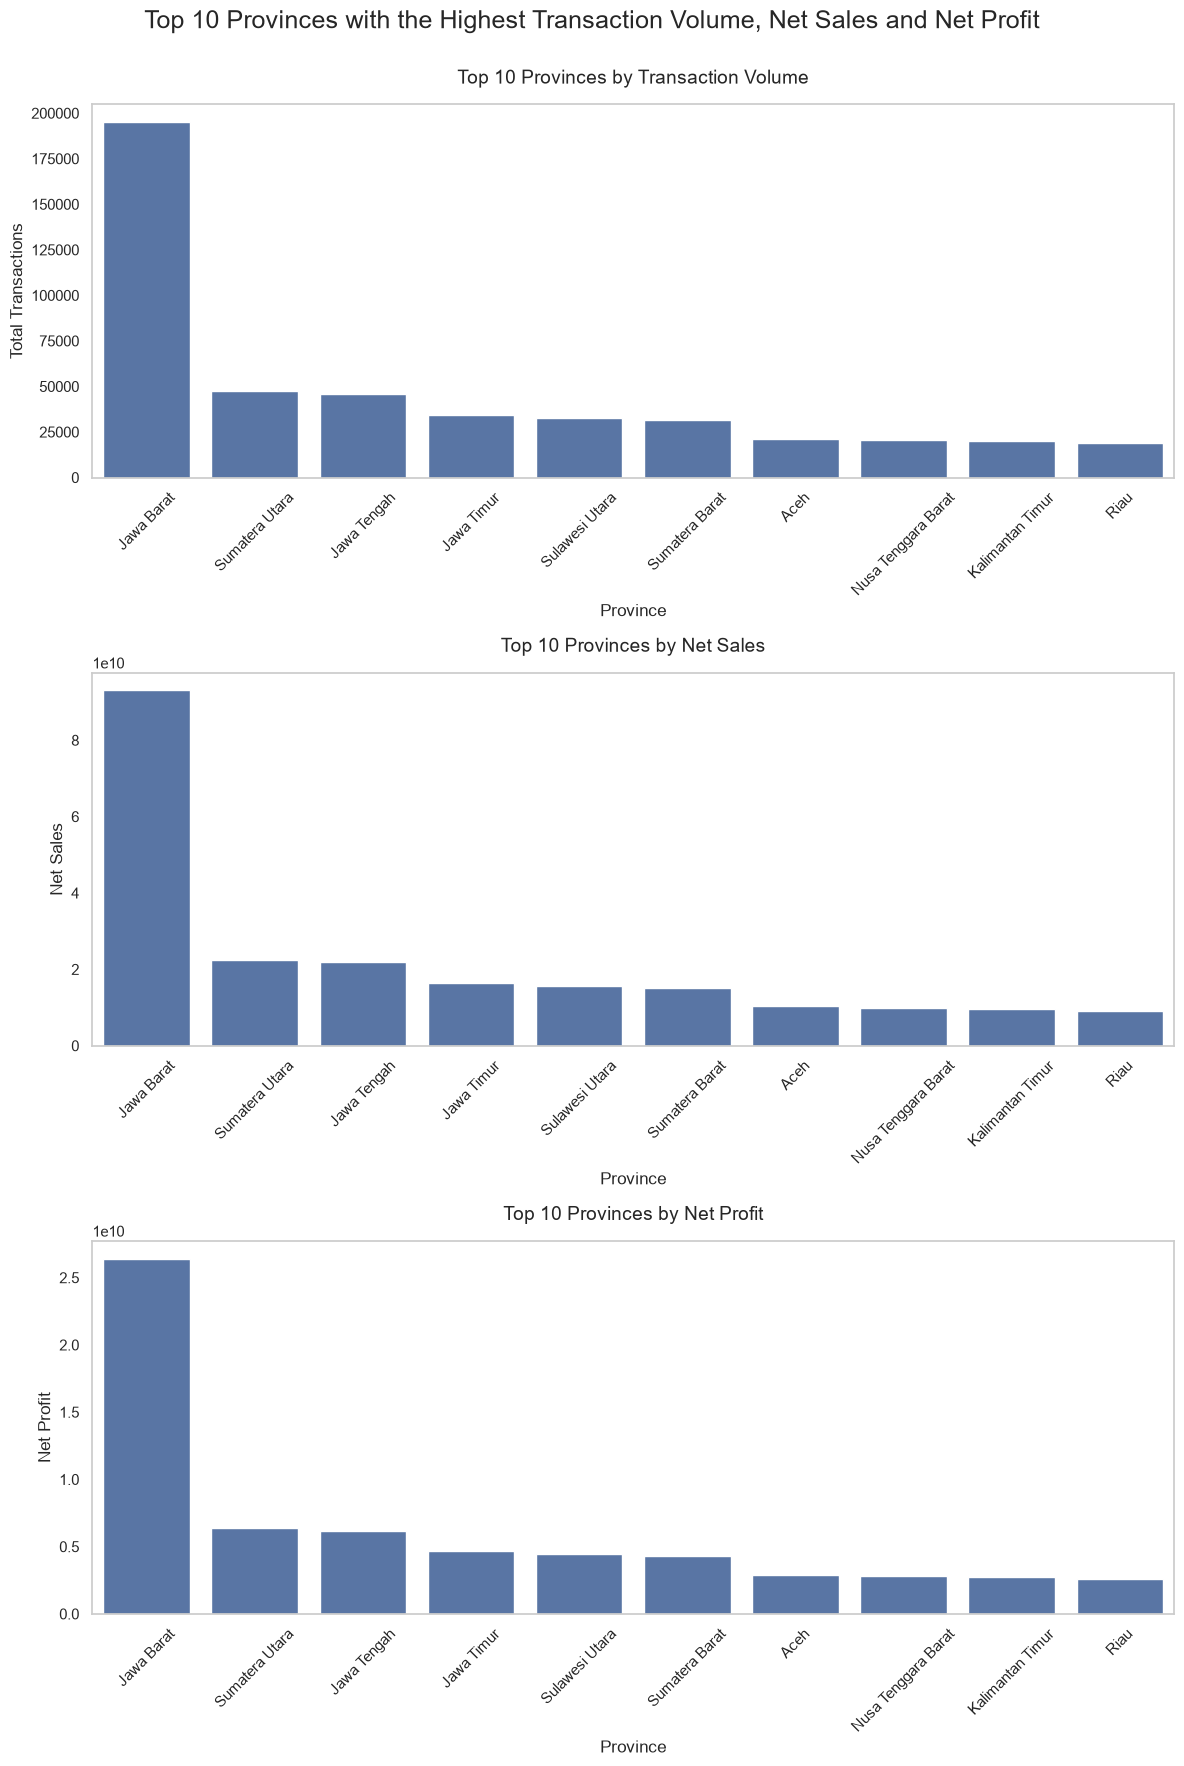

In [67]:
# Top 10 provinces by transaction volume
top_transaction = (
    df_clean
    .groupby('provinsi')
    .agg(
        total_transactions=('transaction_id', 'nunique')
    )
    .reset_index()
    .sort_values('total_transactions', ascending=False)
    .head(10)
)

# Top 10 provinces by Net Sales
top_sales = (
    df_clean
    .groupby('provinsi')
    .agg(
        nett_sales=('nett_sales', 'sum')
    )
    .reset_index()
    .sort_values('nett_sales', ascending=False)
    .head(10)
)

# Top 10 provinces by Net Profit
top_profit = (
    df_clean
    .groupby('provinsi')
    .agg(
        nett_profit=('nett_profit', 'sum')
    )
    .reset_index()
    .sort_values('nett_profit', ascending=False)
    .head(10)
)


# Visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Main title
fig.suptitle(
    'Top 10 Provinces with the Highest Transaction Volume, Net Sales and Net Profit',
    fontsize=18,
    y=0.98
)


# 1. Transaction Volume
sns.barplot(
    data=top_transaction,
    x='provinsi',
    y='total_transactions',
    ax=axes[0]
)

axes[0].set_title(
    'Top 10 Provinces by Transaction Volume',
    fontsize=14,
    pad=15
)
axes[0].set_xlabel('Province')
axes[0].set_ylabel('Total Transactions')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(False)


# 2. Net Sales
sns.barplot(
    data=top_sales,
    x='provinsi',
    y='nett_sales',
    ax=axes[1]
)

axes[1].set_title(
    'Top 10 Provinces by Net Sales',
    fontsize=14,
    pad=15
)
axes[1].set_xlabel('Province')
axes[1].set_ylabel('Net Sales')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(False)


# 3. Net Profit
sns.barplot(
    data=top_profit,
    x='provinsi',
    y='nett_profit',
    ax=axes[2]
)

axes[2].set_title(
    'Top 10 Provinces by Net Profit',
    fontsize=14,
    pad=15
)
axes[2].set_xlabel('Province')
axes[2].set_ylabel('Net Profit')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(False)


# Adjust spacing
plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)

plt.show()

- Primary Key Contributors: West Java, North Sumatra, Central Java, East Java, and North Sulawesi consistently rank as the Top 5 provinces in transaction volume, net sales, and net profit.

- Secondary Key Markets: West Sumatra, Aceh, West Nusa Tenggara, East Kalimantan, and Riau complete the Top 10 high-performing regions.

### **Province-wise Analysis of Transactions, Net Sales and Nett Profit per Year**

In [68]:
province_year = (
    df_clean
    .groupby(['year', 'provinsi'])
    .agg(
        transactions=('transaction_id', 'nunique'),
        nett_sales=('nett_sales', 'sum'),
        nett_profit=('nett_profit', 'sum')
    )
    .sort_values(
        ['year', 'transactions', 'nett_sales', 'nett_profit'],
        ascending=[True, False, False, False]
    )
    .reset_index()
)

province_year

,year,provinsi,transactions,nett_sales,nett_profit
0,2020,Jawa Barat,49102,2.337334e+10,6.637623e+09
1,2020,Sumatera Utara,11762,5.592905e+09,1.588025e+09
2,2020,Jawa Tengah,11333,5.422923e+09,1.539862e+09
3,2020,Jawa Timur,8560,4.089567e+09,1.160863e+09
4,2020,Sulawesi Utara,8239,3.947932e+09,1.121586e+09
...,...,...,...,...,...
119,2023,Papua,1824,8.582899e+08,2.433857e+08
120,2023,Banten,1820,8.879411e+08,2.529045e+08
121,2023,Nusa Tenggara Timur,1680,8.199944e+08,2.338280e+08
122,2023,Sulawesi Tengah,1384,6.657642e+08,1.888688e+08


- Top 10 provinces each year from 2020-2023 is the same with the top provinces overal with **highest transaction volume, highest nett_sales, nett_profit** are **West Java, North Sumatra, Central Java, East Java, North Sumatera, West Sulawesi, Aceh, West Nusa Tenggara, East Kalimantan and Riau**.

### **Province-wise Analysis of Transactions and Net Sales in 2021**

year,provinsi,2020,2021,change,change_pct
0,Jawa Barat,49102,48368,-734,-1.494847
1,Riau,4872,4748,-124,-2.545156
2,Sulawesi Selatan,2036,1940,-96,-4.715128
3,Sulawesi Tenggara,2493,2403,-90,-3.610108
4,Kepulauan Riau,3976,3903,-73,-1.836016
5,Jambi,1847,1777,-70,-3.789930
6,Kalimantan Selatan,2536,2472,-64,-2.523659
7,Jawa Timur,8560,8496,-64,-0.747664
8,Bali,3351,3295,-56,-1.671143
9,Kalimantan Tengah,1935,1887,-48,-2.480620


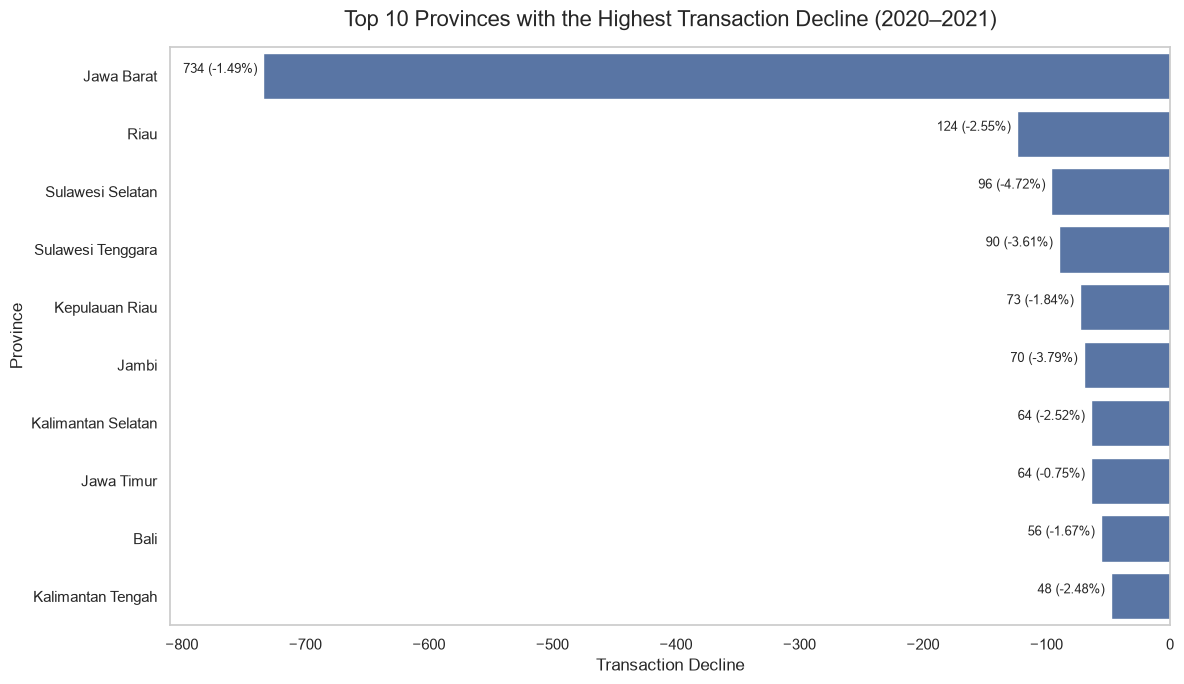

In [69]:
province_2021 = (
    province_year[
        province_year['year'].isin([2020, 2021])
    ]
    .pivot(
        index='provinsi',
        columns='year',
        values='transactions'
    )
    .reset_index()
)

# Transaction volume change from 2020 to 2021
province_2021['change'] = (
    province_2021[2021] - province_2021[2020]
)

# Percentage change in transaction volume from 2020 to 2021
province_2021['change_pct'] = (
    province_2021['change'] /
    province_2021[2020] * 100
)

# Sort and get top 10 provinces with the highest decline
top_decline_2021 = (
    province_2021
    .sort_values(
        ['change', 'change_pct'],
        ascending=[True, True]
    )
    .head(10)
    .reset_index(drop=True)
)

# Display the table
display(top_decline_2021)


# =========================
# Visualization
# =========================

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_decline_2021,
    x='change',
    y='provinsi'
)

plt.title(
    'Top 10 Provinces with the Highest Transaction Decline (2020–2021)',
    fontsize=16,
    pad=15
)

plt.xlabel('Transaction Decline')
plt.ylabel('Province')

# Rotate Y-axis labels slightly
plt.yticks()

# Remove grid
plt.grid(False)

# Add labels outside the bars
for i, row in top_decline_2021.iterrows():
    ax.text(
        row['change'] - 5,
        i,
        f"{abs(row['change']):,.0f} ({row['change_pct']:.2f}%)",
        va='bottom',
        ha='right',
        fontsize=9
    )

# Give extra space on the left for labels
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin - abs(xmin) * 0.05, xmax)

plt.tight_layout()
plt.show()

* **The decline in transaction volume in 2021 was largest in absolute terms in West Java**, indicating that these provinces contributed the most to the overall decrease in transaction volume.
* **In percentage terms, South Sulawesi experienced the most significant declines compared with the 2020 transaction volumes**, indicating a substantial relative decrease in transaction activity.

### **Province-wise Analysis of Transactions and Net Sales in 2023**

year,provinsi,2022,2023,change,change_pct
0,Jawa Timur,8717,8407,-310,-3.556269
1,Kalimantan Timur,5069,4836,-233,-4.596567
2,Sulawesi Utara,8230,8003,-227,-2.758202
3,Aceh,5389,5226,-163,-3.024680
4,Maluku Utara,2368,2220,-148,-6.250000
5,Kalimantan Utara,2520,2403,-117,-4.642857
6,Kalimantan Barat,2462,2356,-106,-4.305443
7,Kepulauan Riau,3912,3809,-103,-2.632924
8,Kalimantan Tengah,1942,1851,-91,-4.685891
9,Banten,1882,1820,-62,-3.294368


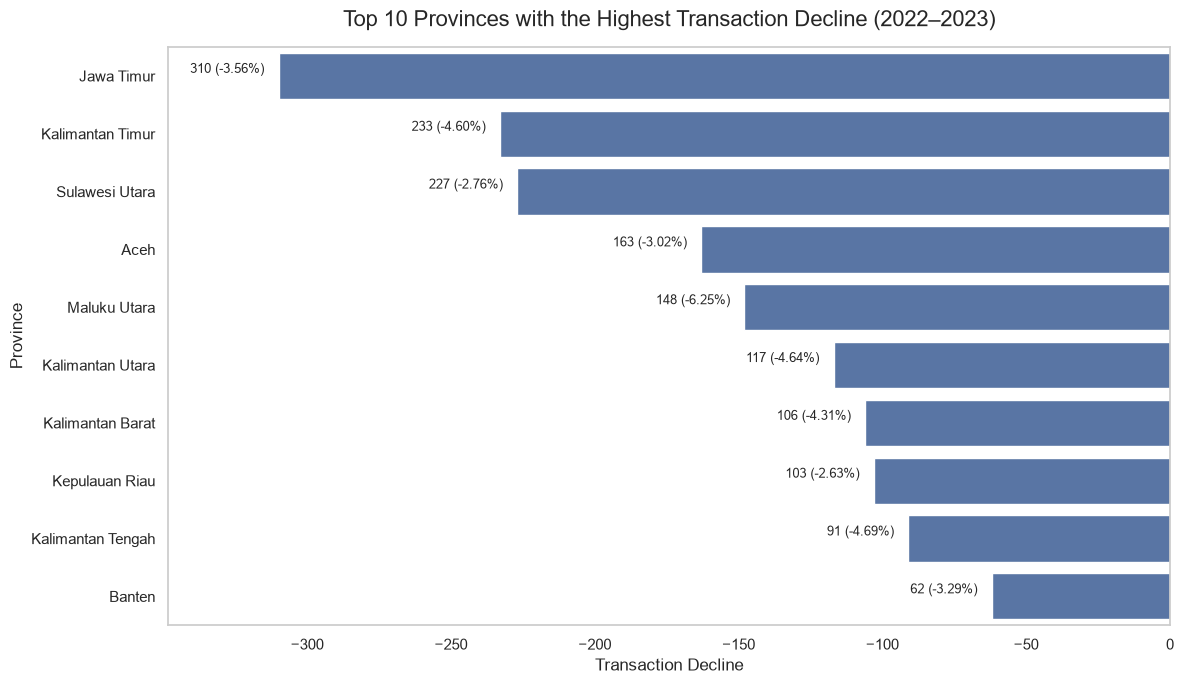

In [70]:
province_2023 = ( 
    province_year[ 
        province_year['year'].isin([2022, 2023]) 
    ] 
    .pivot( 
        index='provinsi', 
        columns='year', 
        values='transactions' 
    ) 
    .reset_index() 
) 
 
# Transaction volume change from 2022 to 2023 
province_2023['change'] = ( 
    province_2023[2023] - province_2023[2022] 
) 
 
# Percentage change in transaction volume from 2022 to 2023 
province_2023['change_pct'] = ( 
    province_2023['change'] / 
    province_2023[2022] * 100 
) 
 
# Sort and get top 10 provinces with the highest decline 
top_decline_2023 = ( 
    province_2023 
    .sort_values( 
        ['change', 'change_pct'], 
        ascending=[True, True] 
    ) 
    .head(10) 
    .reset_index(drop=True) 
) 
 
# Display the table 
display(top_decline_2023) 
 
 
# ========================= 
# Visualization 
# ========================= 
 
plt.figure(figsize=(12, 7)) 
 
ax = sns.barplot( 
    data=top_decline_2023, 
    x='change', 
    y='provinsi' 
) 
 
plt.title( 
    'Top 10 Provinces with the Highest Transaction Decline (2022–2023)', 
    fontsize=16, 
    pad=15 
) 
 
plt.xlabel('Transaction Decline') 
plt.ylabel('Province') 
 
# Rotate Y-axis labels slightly 
plt.yticks() 
 
# Remove grid 
plt.grid(False) 
 
# Add labels outside the bars 
for i, row in top_decline_2023.iterrows(): 
    ax.text( 
        row['change'] - 5, 
        i, 
        f"{abs(row['change']):,.0f} ({row['change_pct']:.2f}%)", 
        va='bottom', 
        ha='right', 
        fontsize=9 
    ) 
 
# Give extra space on the left for labels 
xmin, xmax = ax.get_xlim() 
ax.set_xlim(xmin - abs(xmin) * 0.07, xmax) 
 
plt.tight_layout() 
plt.show()

* **The decline in transaction volume in 2023 was largest in absolute terms in East Java and East Kalimantan**, indicating that these provinces contributed the most to the overall decrease in transaction volume.
* **In percentage terms, North Maluku, East Kalimantan and North Kalimantan experienced the most significant declines compared with the 2022 transaction volumes**, indicating a substantial relative decrease in transaction activity.

### **Top Provinces to Prioritize based on Top 5 province/Top 5 main contributors to Overall Business Revenue**

1. **West Java** 

* One of the top 5 contributors overall, rank 1.
* Recorded the **largest absolute decline in transaction volume in 2021**.

2. **East Java** 

* One of the top 5 contributors overall, rank 4.
* Recorded the **largest absolute decline in transaction volume in 2023**.

## **4. Branch Performance Analysis**

### **Branch Performance Analysis per Province**

Next analysis is to identify which branches contributed most to the transaction volume decline in West Java and East Java, **whether the transaction volume decline is systemic (occured in almost all branch) or only occured in specific branches (Pareto 80/20).**

In [71]:
df_clean.head()

,transaction_id,date,branch_id,branch_name,kota,provinsi,rating_cabang,customer_name,product_id,product_name,actual_price,discount_percentage,gross_profit_percentage,nett_sales,nett_profit,rating_transaksi,opname_stock,year,month_year,month
0,TRX5103706,2021-08-25,93529,Kimia Farma - Klinik & Apotek,Yogyakarta,DI Yogyakarta,4.3,Derrick Wright III,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.10,0.2,226530.0,45306.0,3.0,72.0,2021,08-2021,8
1,TRX5388139,2020-12-29,24832,Kimia Farma - Klinik-Apotek-Laboratorium,Pekanbaru,Riau,4.2,Elizabeth Ramos,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.12,0.2,221496.0,44299.2,3.0,67.0,2020,12-2020,12
2,TRX7251897,2020-02-03,20505,Kimia Farma - Apotek,Cilacap,Jawa Tengah,4.5,Meghan Warner,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.09,0.2,229047.0,45809.4,3.0,68.0,2020,02-2020,2
3,TRX4943675,2022-09-09,17678,Kimia Farma - Klinik & Apotek,Subang,Jawa Barat,4.8,Steven Roberts,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.10,0.2,226530.0,45306.0,3.0,19.0,2022,09-2022,9
4,TRX3469820,2020-06-20,28315,Kimia Farma - Klinik-Apotek-Laboratorium,Sukabumi,Jawa Barat,3.9,Linda Bruce DDS,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.07,0.2,234081.0,46816.2,3.0,66.0,2020,06-2020,6


In [72]:
# business performance by year, province, and branch for branch performance analysis

branch_year = (
    df_clean
    .groupby(['year', 'provinsi', 'branch_id', 'branch_name'])
    .agg(
        transactions=('transaction_id', 'nunique'),
        nett_sales=('nett_sales', 'sum'),
        nett_profit=('nett_profit', 'sum'),
        branch_rating=('rating_cabang', 'mean'),
        transaction_rating=('rating_transaksi', 'mean')
    )
    .reset_index()
)

display(branch_year)

,year,provinsi,branch_id,branch_name,transactions,nett_sales,nett_profit,branch_rating,transaction_rating
0,2020,Aceh,12396,Kimia Farma - Klinik-Apotek-Laboratorium,84,41360151.0,11787651.05,3.9,4.027381
1,2020,Aceh,13423,Kimia Farma - Klinik & Apotek,81,33370334.0,9291790.40,4.8,4.067901
2,2020,Aceh,13853,Kimia Farma - Klinik & Apotek,92,44725999.0,12726172.30,4.4,3.995652
3,2020,Aceh,17275,Kimia Farma - Apotek,106,50519478.0,14328296.30,3.9,3.991509
4,2020,Aceh,18959,Kimia Farma - Klinik-Apotek-Laboratorium,94,46678090.0,13242742.20,4.8,4.063830
...,...,...,...,...,...,...,...,...,...
6895,2023,Sumatera Utara,94478,Kimia Farma - Klinik & Apotek,112,54869948.0,15488215.80,4.5,4.018750
6896,2023,Sumatera Utara,94852,Kimia Farma - Klinik & Apotek,97,42817452.0,12022855.95,4.9,4.005155
6897,2023,Sumatera Utara,95697,Kimia Farma - Klinik & Apotek,86,42710789.0,12044415.70,4.6,4.073256
6898,2023,Sumatera Utara,96210,Kimia Farma - Apotek,101,47998687.0,13653666.35,4.1,3.977228


#### **1. Pareto Analysis of Branches with Transaction Volume Decline**

In [73]:
# 1. Pivot data
branch_pivot = branch_year.pivot(
    index=['provinsi', 'branch_id', 'branch_name'], 
    columns='year', 
    values=['transactions', 'nett_sales', 'branch_rating', 'transaction_rating']
)

branch_pivot.columns = [f"{val}_{yr}" if yr != '' else val for val, yr in branch_pivot.columns]

branch_pivot = branch_pivot.reset_index()

display(branch_pivot.head())

# 2. Delta 2021 vs 2020
branch_pivot['transactions_drop_2021'] = branch_pivot['transactions_2021'] - branch_pivot['transactions_2020']
branch_pivot['nett_sales_drop_2021'] = branch_pivot['nett_sales_2021'] - branch_pivot['nett_sales_2020']

# 3. Delta 2023 vs 2022
branch_pivot['transactions_drop_2023'] = branch_pivot['transactions_2023'] - branch_pivot['transactions_2022']
branch_pivot['nett_sales_drop_2023'] = branch_pivot['nett_sales_2023'] - branch_pivot['nett_sales_2022']

display(branch_pivot.head())

,provinsi,branch_id,branch_name,transactions_2020,transactions_2021,transactions_2022,transactions_2023,nett_sales_2020,nett_sales_2021,nett_sales_2022,nett_sales_2023,branch_rating_2020,branch_rating_2021,branch_rating_2022,branch_rating_2023,transaction_rating_2020,transaction_rating_2021,transaction_rating_2022,transaction_rating_2023
0,Aceh,12396,Kimia Farma - Klinik-Apotek-Laboratorium,84.0,101.0,86.0,85.0,41360151.0,50061662.0,45914709.0,40735647.0,3.9,3.9,3.9,3.9,4.027381,3.945545,4.054651,4.171765
1,Aceh,13423,Kimia Farma - Klinik & Apotek,81.0,104.0,84.0,94.0,33370334.0,51403365.0,35845560.0,48268254.0,4.8,4.8,4.8,4.8,4.067901,4.101923,3.970238,3.984043
2,Aceh,13853,Kimia Farma - Klinik & Apotek,92.0,96.0,102.0,84.0,44725999.0,47711577.0,49576846.0,40009645.0,4.4,4.4,4.4,4.4,3.995652,3.913542,3.961765,4.067857
3,Aceh,17275,Kimia Farma - Apotek,106.0,96.0,94.0,81.0,50519478.0,45591776.0,43832418.0,36342593.0,3.9,3.9,3.9,3.9,3.991509,4.013542,3.891489,3.993827
4,Aceh,18959,Kimia Farma - Klinik-Apotek-Laboratorium,94.0,88.0,105.0,93.0,46678090.0,41700119.0,57209822.0,44855742.0,4.8,4.8,4.8,4.8,4.063830,3.995455,3.998095,3.962366


,provinsi,branch_id,branch_name,transactions_2020,transactions_2021,transactions_2022,transactions_2023,nett_sales_2020,nett_sales_2021,nett_sales_2022,nett_sales_2023,branch_rating_2020,branch_rating_2021,branch_rating_2022,branch_rating_2023,transaction_rating_2020,transaction_rating_2021,transaction_rating_2022,transaction_rating_2023,transactions_drop_2021,nett_sales_drop_2021,transactions_drop_2023,nett_sales_drop_2023
0,Aceh,12396,Kimia Farma - Klinik-Apotek-Laboratorium,84.0,101.0,86.0,85.0,41360151.0,50061662.0,45914709.0,40735647.0,3.9,3.9,3.9,3.9,4.027381,3.945545,4.054651,4.171765,17.0,8701511.0,-1.0,-5179062.0
1,Aceh,13423,Kimia Farma - Klinik & Apotek,81.0,104.0,84.0,94.0,33370334.0,51403365.0,35845560.0,48268254.0,4.8,4.8,4.8,4.8,4.067901,4.101923,3.970238,3.984043,23.0,18033031.0,10.0,12422694.0
2,Aceh,13853,Kimia Farma - Klinik & Apotek,92.0,96.0,102.0,84.0,44725999.0,47711577.0,49576846.0,40009645.0,4.4,4.4,4.4,4.4,3.995652,3.913542,3.961765,4.067857,4.0,2985578.0,-18.0,-9567201.0
3,Aceh,17275,Kimia Farma - Apotek,106.0,96.0,94.0,81.0,50519478.0,45591776.0,43832418.0,36342593.0,3.9,3.9,3.9,3.9,3.991509,4.013542,3.891489,3.993827,-10.0,-4927702.0,-13.0,-7489825.0
4,Aceh,18959,Kimia Farma - Klinik-Apotek-Laboratorium,94.0,88.0,105.0,93.0,46678090.0,41700119.0,57209822.0,44855742.0,4.8,4.8,4.8,4.8,4.063830,3.995455,3.998095,3.962366,-6.0,-4977971.0,-12.0,-12354080.0


In [74]:
def run_pareto_analysis(df_pivot, province_name, drop_col):
    # 0. Calculate total branches in the province (including increased/stable ones)
    all_branches_in_prov = df_pivot[df_pivot['provinsi'] == province_name]
    total_all_branches = len(all_branches_in_prov)

    # 1. Filter province and branches with a decline (drop < 0)
    df_filtered = df_pivot[(df_pivot['provinsi'] == province_name) & (df_pivot[drop_col] < 0)].copy()
    
    # 2. Extract absolute drop values and sort in descending order
    df_filtered['abs_drop'] = df_filtered[drop_col].abs()
    df_filtered = df_filtered.sort_values(by='abs_drop', ascending=False)
    
    # 3. Calculate % contribution and cumulative %
    total_drop = df_filtered['abs_drop'].sum()
    df_filtered['pct_contribution'] = (df_filtered['abs_drop'] / total_drop) * 100
    df_filtered['cumulative_pct'] = df_filtered['pct_contribution'].cumsum()
    
    # 4. Accurate Pareto Evaluation: Include all branches until cumulative contribution reaches/exceeds 70%
    pareto_mask = df_filtered['cumulative_pct'].shift(1, fill_value=0) < 70
    pareto_branches = df_filtered[pareto_mask]
    
    total_underperforming = len(df_filtered)
    count_pareto = len(pareto_branches)
    
    # Percentage relative to underperforming branches
    pct_branches_of_drop = (count_pareto / total_underperforming) * 100 if total_underperforming > 0 else 0
    
    # Percentage of underperforming branches relative to total branches in the province
    pct_drop_vs_all = (total_underperforming / total_all_branches) * 100 if total_all_branches > 0 else 0
    
    # Retrieve actual cumulative percentage for selected Pareto branches
    actual_cum_pct = pareto_branches['cumulative_pct'].iloc[-1] if count_pareto > 0 else 0
    
    print(f"\n==================================================")
    print(f"PARETO ANALYSIS: {province_name.upper()}")
    print(f"==================================================")
    print(f"Total All Branches in {province_name}     : {total_all_branches} branches")
    print(f"Total Underperforming Branches (Drop)   : {total_underperforming} out of {total_all_branches} branches ({pct_drop_vs_all:.1f}%)")
    print(f"Total Lost Transaction Volume            : {int(total_drop):,} transactions")
    print(f"Branches Driving ~80% of Total Drop     : {count_pareto} out of {total_underperforming} drop branches ({pct_branches_of_drop:.1f}%)")
    print(f"Total Cumulative Drop Covered            : {actual_cum_pct:.2f}%")
    
    if pct_branches_of_drop <= 20:
        print("--> Pareto Result: 80/20 Concentration (Decline is concentrated in key branches).\n")
    else:
        print("--> Pareto Result: Systemic Drop (Decline is broadly distributed across branches).\n")
        
    return df_filtered[['branch_id', 'branch_name', drop_col, 'pct_contribution', 'cumulative_pct']]

In [75]:
# =========================================================
# PARETO ANALYSIS: WEST JAVA (2021)
# =========================================================
df_pareto_jabar_2021 = run_pareto_analysis(branch_pivot, 'Jawa Barat', 'transactions_drop_2021')

# Filter cabang yang berkontribusi hingga akumulasi ~80%
jabar_pareto_only = df_pareto_jabar_2021[
    df_pareto_jabar_2021['cumulative_pct'].shift(1, fill_value=0) < 80
].reset_index(drop=True)

print("\n--- PARETO PRIORITY BRANCHES: WEST JAVA (2021) ---")
display(jabar_pareto_only)


# =========================================================
# PARETO ANALYSIS: EAST JAVA (2023)
# =========================================================
df_pareto_jatim_2023 = run_pareto_analysis(branch_pivot, 'Jawa Timur', 'transactions_drop_2023')

# Filter cabang yang berkontribusi hingga akumulasi ~80%
jatim_pareto_only = df_pareto_jatim_2023[
    df_pareto_jatim_2023['cumulative_pct'].shift(1, fill_value=0) < 80
].reset_index(drop=True)

print("\n--- PARETO PRIORITY BRANCHES: EAST JAVA (2023) ---")
display(jatim_pareto_only)


PARETO ANALYSIS: JAWA BARAT
Total All Branches in Jawa Barat     : 510 branches
Total Underperforming Branches (Drop)   : 265 out of 510 branches (52.0%)
Total Lost Transaction Volume            : 3,259 transactions
Branches Driving ~80% of Total Drop     : 110 out of 265 drop branches (41.5%)
Total Cumulative Drop Covered            : 70.27%
--> Pareto Result: Systemic Drop (Decline is broadly distributed across branches).


--- PARETO PRIORITY BRANCHES: WEST JAVA (2021) ---


,branch_id,branch_name,transactions_drop_2021,pct_contribution,cumulative_pct
0,99291,Kimia Farma - Klinik-Apotek-Laboratorium,-51.0,1.564897,1.564897
1,11999,Kimia Farma - Apotek,-45.0,1.380792,2.945689
2,96803,Kimia Farma - Klinik & Apotek,-41.0,1.258055,4.203743
3,85549,Kimia Farma - Apotek,-39.0,1.196686,5.400430
4,93047,Kimia Farma - Klinik-Apotek-Laboratorium,-39.0,1.196686,6.597116
...,...,...,...,...,...
131,47901,Kimia Farma - Apotek,-11.0,0.337527,78.674440
132,12394,Kimia Farma - Klinik-Apotek-Laboratorium,-11.0,0.337527,79.011967
133,58103,Kimia Farma - Apotek,-11.0,0.337527,79.349494
134,40205,Kimia Farma - Klinik-Apotek-Laboratorium,-11.0,0.337527,79.687021



PARETO ANALYSIS: JAWA TIMUR
Total All Branches in Jawa Timur     : 89 branches
Total Underperforming Branches (Drop)   : 52 out of 89 branches (58.4%)
Total Lost Transaction Volume            : 684 transactions
Branches Driving ~80% of Total Drop     : 22 out of 52 drop branches (42.3%)
Total Cumulative Drop Covered            : 70.47%
--> Pareto Result: Systemic Drop (Decline is broadly distributed across branches).


--- PARETO PRIORITY BRANCHES: EAST JAVA (2023) ---


,branch_id,branch_name,transactions_drop_2023,pct_contribution,cumulative_pct
0,87583,Kimia Farma - Apotek,-37.0,5.409357,5.409357
1,81560,Kimia Farma - Klinik & Apotek,-34.0,4.970760,10.380117
2,17510,Kimia Farma - Klinik & Apotek,-32.0,4.678363,15.058480
3,32332,Kimia Farma - Apotek,-28.0,4.093567,19.152047
4,25876,Kimia Farma - Klinik & Apotek,-27.0,3.947368,23.099415
5,81451,Kimia Farma - Apotek,-27.0,3.947368,27.046784
6,86806,Kimia Farma - Klinik & Apotek,-25.0,3.654971,30.701754
7,25780,Kimia Farma - Klinik & Apotek,-25.0,3.654971,34.356725
8,34854,Kimia Farma - Klinik-Apotek-Laboratorium,-24.0,3.508772,37.865497
9,45624,Kimia Farma - Klinik & Apotek,-23.0,3.362573,41.228070


### **Transaction Decline in 2021 Across West Java Branches**:

- **269 of 510 branches (52.7%)** experienced a decline in transaction volume from 2020 to 2021, indicating that the decline affected **more than half of the branch in West Java**.
- Among the **269 underperforming branches**, **139 branches (51.7%)** were required to contribute for approximately **80% of the total transaction decline**, representing **3,317 lost transactions**.
- Under a typical **80/20 Pareto pattern**, ~20% of declining branches would be expected to drive 80% of the decline. Instead, **more than half of the declining branches** were needed to reach the 80% threshold.
- This indicates that the **transaction decline was broadly distributed across the branches in West Java rather than concentrated in a small number of branches**, showing a **systemic regional decline**.


### **Transaction Decline in 2023 Across East Java Branches**

- **51 of 89 branches (57.3%)** experienced a decline in transaction volume from 2022 to 2023, indicating that the decline affected **more than half of the branch network**.
- Among the **51 underperforming branches**, **27 branches (52.9%)** were required to account for approximately **80% of the total transaction decline**, representing **686 lost transactions**.
- Under a typical **80/20 Pareto pattern**, ~20% of declining branches would be expected to drive 80% of the decline. Instead, **more than half of the declining branches** were needed to reach the 80% threshold.
- This indicates that the transaction decline was **broadly distributed across the branches in East Java rather than concentrated in a small number of branches**, showing a **systemic regional decline**.

#### **2. Branch Ratings and Transaction Ratings**

In [76]:
# High Branch Rating (>= 4.0) AND Low Transaction Rating (<= 3.0)
df_gap_rating = df_clean[
    (df_clean['rating_cabang'] >= 4.0) &
    (df_clean['rating_transaksi'] <= 3.0)
]

df_gap_rating

,transaction_id,date,branch_id,branch_name,kota,provinsi,rating_cabang,customer_name,product_id,product_name,actual_price,discount_percentage,gross_profit_percentage,nett_sales,nett_profit,rating_transaksi,opname_stock,year,month_year,month
0,TRX5103706,2021-08-25,93529,Kimia Farma - Klinik & Apotek,Yogyakarta,DI Yogyakarta,4.3,Derrick Wright III,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.10,0.20,226530.0,45306.00,3.0,72.0,2021,08-2021,8
1,TRX5388139,2020-12-29,24832,Kimia Farma - Klinik-Apotek-Laboratorium,Pekanbaru,Riau,4.2,Elizabeth Ramos,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.12,0.20,221496.0,44299.20,3.0,67.0,2020,12-2020,12
2,TRX7251897,2020-02-03,20505,Kimia Farma - Apotek,Cilacap,Jawa Tengah,4.5,Meghan Warner,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.09,0.20,229047.0,45809.40,3.0,68.0,2020,02-2020,2
3,TRX4943675,2022-09-09,17678,Kimia Farma - Klinik & Apotek,Subang,Jawa Barat,4.8,Steven Roberts,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.10,0.20,226530.0,45306.00,3.0,19.0,2022,09-2022,9
5,TRX1213133,2021-09-17,22280,Kimia Farma - Apotek,Batam,Kepulauan Riau,4.5,Cory Castro,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.11,0.20,224013.0,44802.60,3.0,53.0,2021,09-2021,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16814,TRX2265080,2023-10-30,64433,Kimia Farma - Klinik & Apotek,Bandung,Jawa Barat,4.1,Linda Sanchez,KF999,"Other analgesics and antipyretics, Pyrazolones...",389900,0.13,0.25,339213.0,84803.25,3.0,80.0,2023,10-2023,10
16815,TRX7682477,2023-05-24,55171,Kimia Farma - Apotek,Ambon,Maluku,5.0,Stephanie Lopez,KF999,"Other analgesics and antipyretics, Pyrazolones...",389900,0.11,0.25,347011.0,86752.75,3.0,100.0,2023,05-2023,5
16816,TRX1443036,2021-01-27,73625,Kimia Farma - Apotek,Kotamobagu,Sulawesi Utara,4.9,Cindy Calhoun DDS,KF999,"Other analgesics and antipyretics, Pyrazolones...",389900,0.13,0.25,339213.0,84803.25,3.0,16.0,2021,01-2021,1
16817,TRX4656315,2023-12-25,49927,Kimia Farma - Apotek,Surabaya,Jawa Timur,4.1,Evan Phelps,KF999,"Other analgesics and antipyretics, Pyrazolones...",389900,0.01,0.25,386001.0,96500.25,3.0,96.0,2023,12-2023,12


- There are **branches with high branch ratings but low transaction ratings**. This indicates that **while the branches are well-rated overall, they may be underperforming in terms of transaction quality**.

Total Transactions with Branch Rating > 4.0 and Transaction Rating <= 3.0
West Java : 4,162 / 195,022 transactions (2.13%)
East Java : 800 / 34,180 transactions (2.34%)


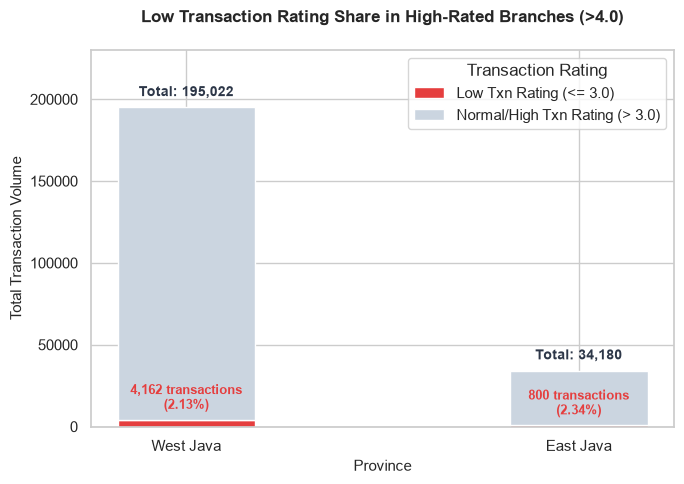

In [77]:
# 1. Calculate total overall transactions per province
all_jabar = len(df_clean[df_clean['provinsi'] == 'Jawa Barat'])
all_jatim = len(df_clean[df_clean['provinsi'] == 'Jawa Timur'])

# 2. Calculate exact low transaction counts for each province (Branch Rating > 4.0 & Transaction Rating <= 3.0)
total_low_jabar = len(df_clean[
    (df_clean['provinsi'] == 'Jawa Barat') & 
    (df_clean['rating_cabang'] > 4.0) & 
    (df_clean['rating_transaksi'] <= 3.0)
])

total_low_jatim = len(df_clean[
    (df_clean['provinsi'] == 'Jawa Timur') & 
    (df_clean['rating_cabang'] > 4.0) & 
    (df_clean['rating_transaksi'] <= 3.0)
])

# 3. Calculate percentages
pct_jabar = (total_low_jabar / all_jabar) * 100 if all_jabar > 0 else 0
pct_jatim = (total_low_jatim / all_jatim) * 100 if all_jatim > 0 else 0

print("Total Transactions with Branch Rating > 4.0 and Transaction Rating <= 3.0")
print(f"West Java : {total_low_jabar:,} / {all_jabar:,} transactions ({pct_jabar:.2f}%)")
print(f"East Java : {total_low_jatim:,} / {all_jatim:,} transactions ({pct_jatim:.2f}%)")

# 4. Data Preparation for Stacked Bar Chart
viz_data = pd.DataFrame({
    'Province': ['West Java', 'East Java'],
    'Low Rating (<= 3.0)': [total_low_jabar, total_low_jatim],
    'Normal/High Rating (> 3.0)': [all_jabar - total_low_jabar, all_jatim - total_low_jatim]
})

# 5. Create Stacked Bar Chart
fig, ax = plt.subplots(figsize=(7, 5))
sns.set_style("whitegrid")

# Custom bar width to make low-rating sections clear
bar_w = 0.35

# Draw Stacked Bars
bar1 = ax.bar(viz_data['Province'], viz_data['Low Rating (<= 3.0)'], color='#E53E3E', width=bar_w, label='Low Txn Rating (<= 3.0)')
bar2 = ax.bar(viz_data['Province'], viz_data['Normal/High Rating (> 3.0)'], bottom=viz_data['Low Rating (<= 3.0)'], color='#CBD5E0', width=bar_w, label='Normal/High Txn Rating (> 3.0)')

# Annotate values and percentages
for i, row in viz_data.iterrows():
    low_val = row['Low Rating (<= 3.0)']
    total_val = low_val + row['Normal/High Rating (> 3.0)']
    pct = (low_val / total_val) * 100 if total_val > 0 else 0
    
    # Label for Low Rating (Placed slightly above the base if percentage is small for readability)
    if low_val > 0:
        ax.annotate(
            f'{low_val:,} transactions\n({pct:.2f}%)',
            xy=(i, low_val),
            xytext=(0, 5), textcoords="offset points",
            ha='center', va='bottom',
            color='#E53E3E', fontweight='bold', fontsize=9.5
        )
    
    # Total count label on top of the entire bar
    ax.annotate(
        f'Total: {total_val:,}',
        xy=(i, total_val),
        xytext=(0, 6), textcoords="offset points",
        ha='center', va='bottom',
        color='#2D3748', fontweight='bold', fontsize=10
    )

plt.title('Low Transaction Rating Share in High-Rated Branches (>4.0)', fontsize=12, fontweight='bold', pad=20)
plt.ylabel('Total Transaction Volume', fontsize=11)
plt.xlabel('Province', fontsize=11)

# Dynamically set upper limit to leave room for top text annotations
plt.ylim(0, max(all_jabar, all_jatim) * 1.18 if max(all_jabar, all_jatim) > 0 else 100)
plt.legend(title='Transaction Rating', frameon=True, loc='upper right')
plt.tight_layout()

plt.show()

- Only **~2% of transactions** in West Java (2.14%) and East Java (2.36%) had **low transaction ratings (≤3.0)** despite **high branch ratings (>4.0)**.
- This indicates that **the majority of transactions were rated positively**, with limited evidence of widespread transaction-level service issues.

We will further investigate the **relationship between branch ratings, transaction ratings, and transaction volume decline** to determine if there is a correlation between these factors.

#### **3. Branch Rating vs Transaction Rating for High-Performing Branches: West Java (2021) and East Java (2023)**

**West Java (2021)**

In [78]:
# 1. Filter Data for West Java (2021)
df_jabar_n2 = df_clean[
    (df_clean['provinsi'] == 'Jawa Barat') &
    (df_clean['year'].isin([2020, 2021]))
].copy()


# 2. Total transaction, average branch rating, and average transaction rating per branch and per year
jabar_perf = (
    df_jabar_n2
    .groupby(['branch_id', 'branch_name', 'year'])
    .agg(
        total_transactions=('transaction_id', 'count'),
        avg_branch_rating=('rating_cabang', 'mean'),
        avg_trans_rating=('rating_transaksi', 'mean')
    )
    .reset_index()
)


# 3. Calculate Rating Gap per Branch
jabar_perf['rating_gap'] = (
    jabar_perf['avg_branch_rating'] -
    jabar_perf['avg_trans_rating']
)


# 4. Pivot Data YoY
pivot_transactions_jabar = (
    jabar_perf
    .pivot(
        index=['branch_id', 'branch_name'],
        columns='year',
        values='total_transactions'
    )
    .fillna(0)
)

pivot_gap_jabar = (
    jabar_perf
    .pivot(
        index=['branch_id', 'branch_name'],
        columns='year',
        values='rating_gap'
    )
    .fillna(0)
)

pivot_b_jabar = (
    jabar_perf
    .pivot(
        index=['branch_id', 'branch_name'],
        columns='year',
        values='avg_branch_rating'
    )
    .fillna(0)
)

pivot_t_jabar = (
    jabar_perf
    .pivot(
        index=['branch_id', 'branch_name'],
        columns='year',
        values='avg_trans_rating'
    )
    .fillna(0)
)


# 5. Create Summary DataFrame for West Java (2021)
summary_jabar_gap = pd.DataFrame(
    index=pivot_transactions_jabar.index
)

summary_jabar_gap['transactions_2020'] = (
    pivot_transactions_jabar[2020]
)

summary_jabar_gap['transactions_2021'] = (
    pivot_transactions_jabar[2021]
)

summary_jabar_gap['transactions_drop'] = (
    summary_jabar_gap['transactions_2021'] -
    summary_jabar_gap['transactions_2020']
)

summary_jabar_gap['rating_cabang'] = (
    pivot_b_jabar[2021]
)

summary_jabar_gap['rating_transaksi'] = (
    pivot_t_jabar[2021]
)

summary_jabar_gap['rating_gap'] = (
    pivot_gap_jabar[2021]
)


# 6. Filter branches with negative transaction drop
#    and calculate correlation between rating gap and absolute transaction drop
df_jabar_drop = summary_jabar_gap[
    summary_jabar_gap['transactions_drop'] < 0
].copy()

df_jabar_drop['abs_drop'] = (
    df_jabar_drop['transactions_drop'].abs()
)

corr_jabar = (
    df_jabar_drop['rating_gap']
    .corr(df_jabar_drop['abs_drop'])
)


# 7. Print Rating Gap Summary
print("\nRATING GAP SUMMARY: JAWA BARAT (2021)\n")

print(
    f"Mean of Branch Rating      : "
    f"{summary_jabar_gap['rating_cabang'].mean():.2f}"
)

print(
    f"Mean of Transaction Rating : "
    f"{summary_jabar_gap['rating_transaksi'].mean():.2f}"
)

print(
    f"Mean of Rating Gap         : "
    f"+{summary_jabar_gap['rating_gap'].mean():.2f}"
)

print(
    f"Rating Gap vs Transaction Drop Correlation : "
    f"{corr_jabar:.3f}\n"
)


# 8. Display all declining branches with rating gap
branches_with_gap_jabar = (
    df_jabar_drop
    .sort_values(
        by='rating_gap',
        ascending=False
    )
    .reset_index()
)

print("BRANCHES WITH RATING GAP - WEST JAVA (2021)")

display(
    branches_with_gap_jabar[
        [
            'branch_id',
            'branch_name',
            'rating_cabang',
            'rating_transaksi',
            'rating_gap',
            'transactions_2020',
            'transactions_2021',
            'transactions_drop'
        ]
    ]
)


RATING GAP SUMMARY: JAWA BARAT (2021)

Mean of Branch Rating      : 4.45
Mean of Transaction Rating : 4.00
Mean of Rating Gap         : +0.44
Rating Gap vs Transaction Drop Correlation : -0.017

BRANCHES WITH RATING GAP - WEST JAVA (2021)


,branch_id,branch_name,rating_cabang,rating_transaksi,rating_gap,transactions_2020,transactions_2021,transactions_drop
0,54476,Kimia Farma - Klinik-Apotek-Laboratorium,5.0,3.948276,1.051724,95,87,-8
1,89609,Kimia Farma - Klinik-Apotek-Laboratorium,4.9,3.865169,1.034831,104,89,-15
2,47175,Kimia Farma - Apotek,4.9,3.896774,1.003226,111,93,-18
3,20227,Kimia Farma - Klinik & Apotek,5.0,3.998837,1.001163,101,86,-15
4,19882,Kimia Farma - Klinik-Apotek-Laboratorium,5.0,4.001282,0.998718,80,78,-2
...,...,...,...,...,...,...,...,...
260,86704,Kimia Farma - Klinik & Apotek,3.9,4.022892,-0.122892,105,83,-22
261,32224,Kimia Farma - Klinik-Apotek-Laboratorium,4.0,4.126506,-0.126506,95,83,-12
262,66565,Kimia Farma - Apotek,3.9,4.031579,-0.131579,97,95,-2
263,89393,Kimia Farma - Klinik-Apotek-Laboratorium,3.9,4.057303,-0.157303,102,89,-13


**East Java (2023)**

In [79]:
# 1. Filter Data for East Java (2023)
df_jatim_n2 = df_clean[
    (df_clean['provinsi'] == 'Jawa Timur') &
    (df_clean['year'].isin([2022, 2023]))
].copy()


# 2. Total transaction, average branch rating, and average transaction rating per branch and per year
jatim_perf = (
    df_jatim_n2
    .groupby(['branch_id', 'branch_name', 'year'])
    .agg(
        total_transactions=('transaction_id', 'count'),
        avg_branch_rating=('rating_cabang', 'mean'),
        avg_trans_rating=('rating_transaksi', 'mean')
    )
    .reset_index()
)


# 3. Calculate Rating Gap per Branch
jatim_perf['rating_gap'] = (
    jatim_perf['avg_branch_rating'] -
    jatim_perf['avg_trans_rating']
)


# 4. Pivot Data YoY
pivot_transactions_jatim = (
    jatim_perf
    .pivot(
        index=['branch_id', 'branch_name'],
        columns='year',
        values='total_transactions'
    )
    .fillna(0)
)

pivot_gap_jatim = (
    jatim_perf
    .pivot(
        index=['branch_id', 'branch_name'],
        columns='year',
        values='rating_gap'
    )
    .fillna(0)
)

pivot_b_jatim = (
    jatim_perf
    .pivot(
        index=['branch_id', 'branch_name'],
        columns='year',
        values='avg_branch_rating'
    )
    .fillna(0)
)

pivot_t_jatim = (
    jatim_perf
    .pivot(
        index=['branch_id', 'branch_name'],
        columns='year',
        values='avg_trans_rating'
    )
    .fillna(0)
)


# 5. Create Summary DataFrame for East Java (2023)
summary_jatim_gap = pd.DataFrame(
    index=pivot_transactions_jatim.index
)

summary_jatim_gap['transactions_2022'] = (
    pivot_transactions_jatim[2022]
)

summary_jatim_gap['transactions_2023'] = (
    pivot_transactions_jatim[2023]
)

summary_jatim_gap['transactions_drop'] = (
    summary_jatim_gap['transactions_2023'] -
    summary_jatim_gap['transactions_2022']
)

summary_jatim_gap['rating_cabang'] = (
    pivot_b_jatim[2023]
)

summary_jatim_gap['rating_transaksi'] = (
    pivot_t_jatim[2023]
)

summary_jatim_gap['rating_gap'] = (
    pivot_gap_jatim[2023]
)


# 6. Filter branches with negative transaction drop
#    and calculate correlation between rating gap and absolute transaction drop
df_jatim_drop = summary_jatim_gap[
    summary_jatim_gap['transactions_drop'] < 0
].copy()

df_jatim_drop['abs_drop'] = (
    df_jatim_drop['transactions_drop'].abs()
)

corr_jatim = (
    df_jatim_drop['rating_gap']
    .corr(df_jatim_drop['abs_drop'])
)


# 7. Print Rating Gap Summary
print("\nRATING GAP SUMMARY: EAST JAVA (2023)\n")

print(
    f"Mean of Branch Rating      : "
    f"{summary_jatim_gap['rating_cabang'].mean():.2f}"
)

print(
    f"Mean of Transaction Rating : "
    f"{summary_jatim_gap['rating_transaksi'].mean():.2f}"
)

print(
    f"Mean of Rating Gap         : "
    f"+{summary_jatim_gap['rating_gap'].mean():.2f}"
)

print(
    f"Rating Gap vs Transaction Drop Correlation : "
    f"{corr_jatim:.3f}\n"
)


# 8. Display all declining branches with rating gap
branches_with_gap_jatim = (
    df_jatim_drop
    .sort_values(
        by='rating_gap',
        ascending=False
    )
    .reset_index()
)

print("BRANCHES WITH RATING GAP - EAST JAVA (2023)")

display(
    branches_with_gap_jatim[
        [
            'branch_id',
            'branch_name',
            'rating_cabang',
            'rating_transaksi',
            'rating_gap',
            'transactions_2022',
            'transactions_2023',
            'transactions_drop'
        ]
    ]
)


RATING GAP SUMMARY: EAST JAVA (2023)

Mean of Branch Rating      : 4.50
Mean of Transaction Rating : 4.01
Mean of Rating Gap         : +0.50
Rating Gap vs Transaction Drop Correlation : -0.019

BRANCHES WITH RATING GAP - EAST JAVA (2023)


,branch_id,branch_name,rating_cabang,rating_transaksi,rating_gap,transactions_2022,transactions_2023,transactions_drop
0,17510,Kimia Farma - Klinik & Apotek,5.0,3.912987,1.087013,109,77,-32
1,94651,Kimia Farma - Klinik-Apotek-Laboratorium,5.0,3.917708,1.082292,99,96,-3
2,69438,Kimia Farma - Klinik & Apotek,5.0,4.008511,0.991489,107,94,-13
3,21097,Kimia Farma - Klinik-Apotek-Laboratorium,5.0,4.034831,0.965169,96,89,-7
4,18858,Kimia Farma - Klinik-Apotek-Laboratorium,5.0,4.045455,0.954545,101,99,-2
5,45624,Kimia Farma - Klinik & Apotek,4.9,3.970455,0.929545,111,88,-23
6,79919,Kimia Farma - Klinik & Apotek,4.9,4.019512,0.880488,93,82,-11
7,93689,Kimia Farma - Klinik & Apotek,4.8,3.941573,0.858427,104,89,-15
8,26841,Kimia Farma - Klinik-Apotek-Laboratorium,4.8,3.941772,0.858228,92,79,-13
9,13393,Kimia Farma - Klinik & Apotek,4.8,3.952041,0.847959,103,98,-5


- Correlation values close to 0 (-0.055 and 0.058) indicate that the decline in transaction volume is not linearly or directly related to the Rating Gap / service quality at the branch level.

- This finding is consistent with the Pareto Analysis, which shows that the decline is systemic rather than branch-specific, affecting:
    - **51.7% of declining branches in West Java**
    - **52.9% of declining branches in East Java**

- Operational issues reflected in the Rating Gap between Branch Rating and Transaction Rating are **not shown to directly drive the decline in transaction volume and Net Sales**.

- Therefore, service quality is **not supported as a primary driver** of the transaction and Net Sales decline in West Java (2021) and East Java (2023). **Other strategic or external factors should be further investigated to explain the remaining decline.**

## **5. Product Performance Analysis**

### **Product Performance Decline Overall**

In [80]:
# 1. PRODUCT PERFORMANCE AGGREGATION BY PROVINCE (OVERALL YEAR-ON-YEAR)
prod_overall = df_clean.groupby(['provinsi', 'year', 'product_name']).agg(
    total_tx=('transaction_id', 'count'),
    total_sales=('nett_sales', 'sum')
).unstack(level='year', fill_value=0)

# Safe flattening for MultiIndex columns
if isinstance(prod_overall.columns, pd.MultiIndex):
    prod_overall.columns = [f'{col_name}_{year}' for col_name, year in prod_overall.columns.to_flat_index()]

prod_overall = prod_overall.reset_index()


# 2. OVERALL COMMERCIAL METRICS BY PRODUCT (JAN vs FEB ALL PROVINCES)
df_feb_price = df_clean[df_clean['month'].isin([1, 2])].copy().reset_index(drop=True)

# Include 'product_name' in the grouping breakdown
price_summary_all = df_feb_price.groupby(['provinsi', 'year', 'product_name', 'month']).agg(
    total_sales=('nett_sales', 'sum'),
    total_tx=('transaction_id', 'count'),
    avg_discount_pct=('discount_percentage', 'mean'),  # Average discount percentage
    avg_actual_price=('actual_price', 'mean')           # Average catalog price
).reset_index()

# Calculate Average Net Sales per Transaction (AOV / Basket Size)
price_summary_all['avg_net_sales_per_tx'] = price_summary_all['total_sales'] / price_summary_all['total_tx']

# METRICS BY PRODUCT: Net Sales, Transactions, AOV, & Discount MoM Change
# 
# Include 'product_name' in grouping to calculate MoM metrics per individual SKU
price_summary_all['mom_sales_change_abs'] = price_summary_all.groupby(['provinsi', 'year', 'product_name'])['total_sales'].diff()
price_summary_all['mom_pct_sales'] = price_summary_all.groupby(['provinsi', 'year', 'product_name'])['total_sales'].pct_change() * 100

price_summary_all['mom_tx_change_abs'] = price_summary_all.groupby(['provinsi', 'year', 'product_name'])['total_tx'].diff()
price_summary_all['mom_pct_tx'] = price_summary_all.groupby(['provinsi', 'year', 'product_name'])['total_tx'].pct_change() * 100

price_summary_all['mom_pct_aov'] = price_summary_all.groupby(['provinsi', 'year', 'product_name'])['avg_net_sales_per_tx'].pct_change() * 100
price_summary_all['mom_pct_discount'] = price_summary_all.groupby(['provinsi', 'year', 'product_name'])['avg_discount_pct'].pct_change() * 100

print("MONTHLY COMMERCIAL METRICS BY PRODUCT (ALL PROVINCES - JAN vs FEB)")
display(
    price_summary_all[[
        'provinsi', 'year', 'product_name', 'month', 
        'total_sales', 'mom_sales_change_abs', 'mom_pct_sales',
        'total_tx', 'mom_tx_change_abs', 'mom_pct_tx',
        'avg_actual_price', 'avg_discount_pct', 'mom_pct_discount', 
        'avg_net_sales_per_tx', 'mom_pct_aov'
    ]]
)

MONTHLY COMMERCIAL METRICS BY PRODUCT (ALL PROVINCES - JAN vs FEB)


,provinsi,year,product_name,month,total_sales,mom_sales_change_abs,mom_pct_sales,total_tx,mom_tx_change_abs,mom_pct_tx,avg_actual_price,avg_discount_pct,mom_pct_discount,avg_net_sales_per_tx,mom_pct_aov
0,Aceh,2020,"Anti-inflammatory and antirheumatic products, ...",1,16813676.0,NaN,NaN,41,NaN,NaN,439200.000000,0.064146,NaN,410089.658537,NaN
1,Aceh,2020,"Anti-inflammatory and antirheumatic products, ...",2,18699891.0,1886215.0,11.218338,47,6.0,14.634146,429287.234043,0.072128,12.442359,397870.021277,-2.979748
2,Aceh,2020,"Anti-inflammatory and antirheumatic products, ...",1,17350567.0,NaN,NaN,35,NaN,NaN,534525.714286,0.077143,NaN,495730.485714,NaN
3,Aceh,2020,"Anti-inflammatory and antirheumatic products, ...",2,20470667.0,3120100.0,17.982698,36,1.0,2.857143,615225.000000,0.073333,-4.938272,568629.638889,14.705400
4,Aceh,2020,Antihistamines for systemic use,1,36046563.0,NaN,NaN,67,NaN,NaN,582774.626866,0.079552,NaN,538008.402985,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1979,Sumatera Utara,2023,"Other analgesics and antipyretics, Salicylic a...",2,59149603.0,-10237371.0,-14.754024,111,-30.0,-21.276596,574820.720721,0.072793,-0.448266,532879.306306,8.285429
1980,Sumatera Utara,2023,"Psycholeptics drugs, Anxiolytic drugs",1,69302613.0,NaN,NaN,138,NaN,NaN,545162.318841,0.080725,NaN,502192.847826,NaN
1981,Sumatera Utara,2023,"Psycholeptics drugs, Anxiolytic drugs",2,68438325.0,-864288.0,-1.247122,140,2.0,1.449275,528717.142857,0.072571,-10.100026,488845.178571,-2.657877
1982,Sumatera Utara,2023,"Psycholeptics drugs, Hypnotics and sedatives d...",1,72494764.0,NaN,NaN,175,NaN,NaN,449177.714286,0.075771,NaN,414255.794286,NaN


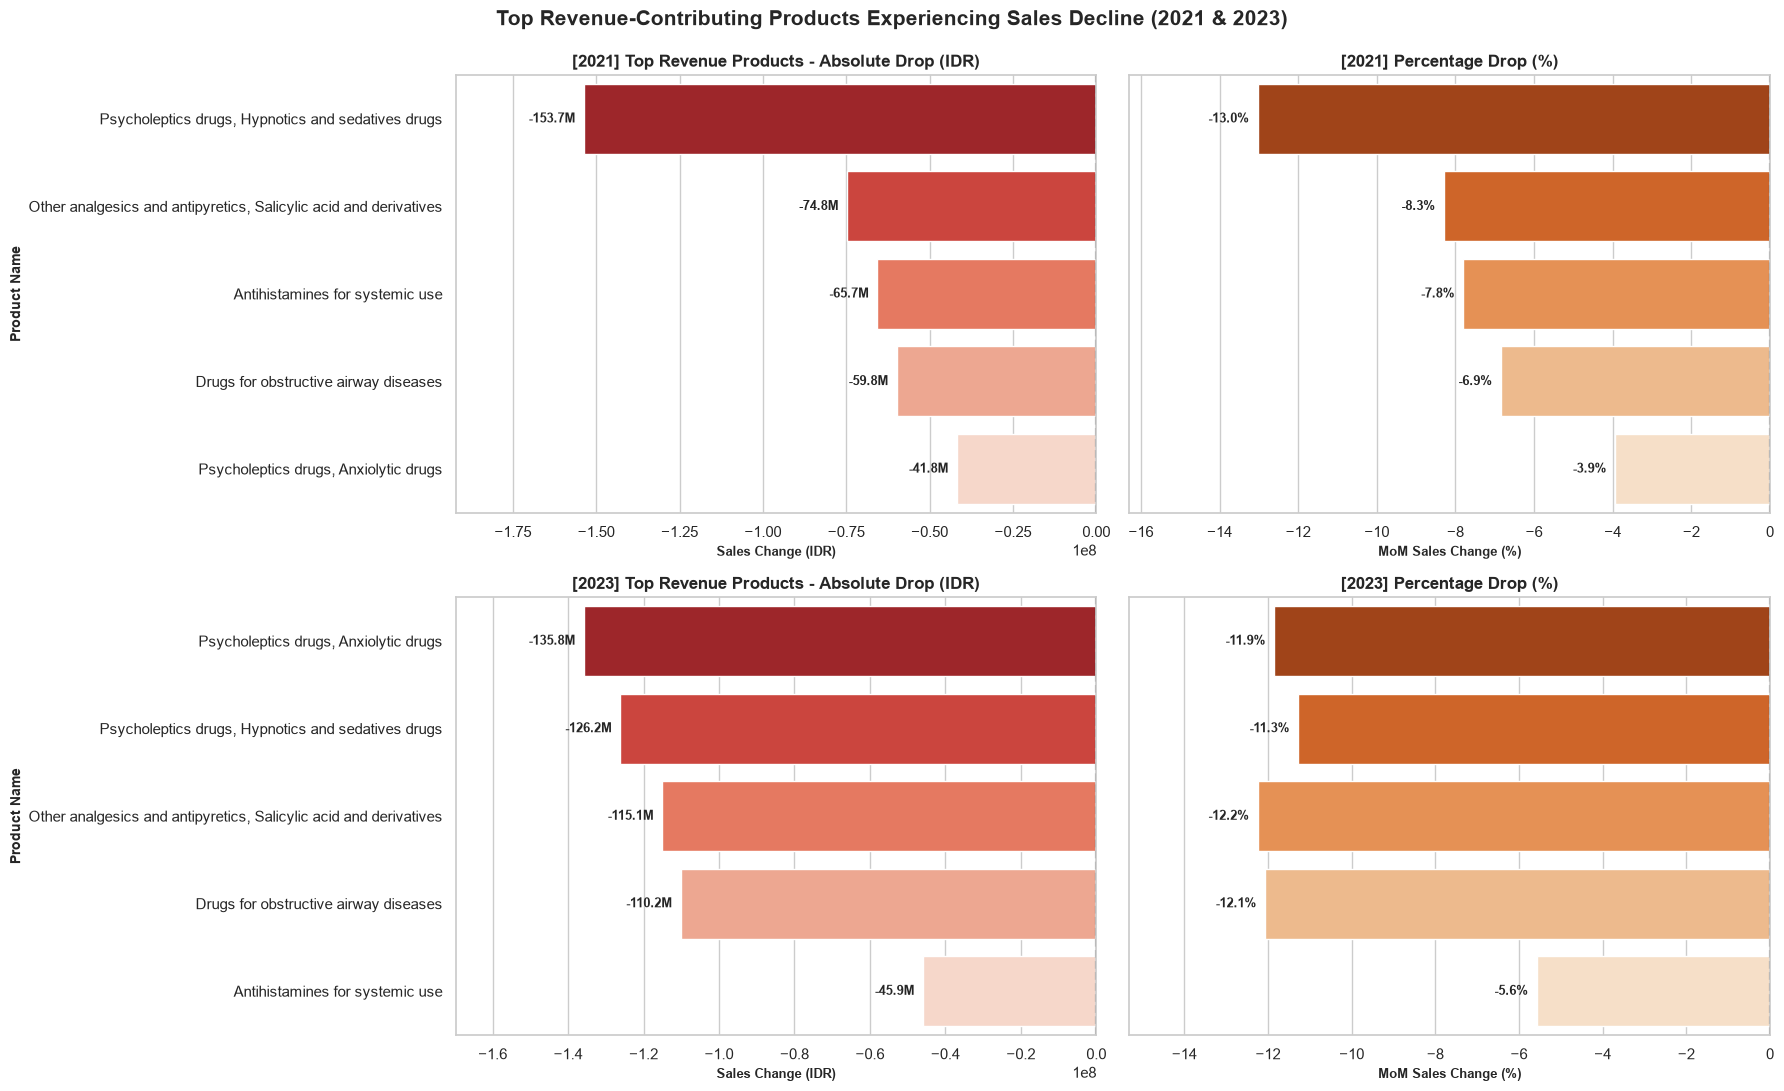

In [81]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Filter raw data for Jan & Feb specifically for years 2021 and 2023
df_filtered_years = df_clean[
    (df_clean['month'].isin([1, 2])) & 
    (df_clean['year'].isin([2021, 2023]))
].copy()

# 2. Aggregate Total Sales by Year, Product Name, and Month
product_yearly = (
    df_filtered_years.groupby(['year', 'product_name', 'month'])
    .agg(total_sales=('nett_sales', 'sum'))
    .unstack(level='month', fill_value=0)
)

# Flatten month columns (1 = Jan, 2 = Feb)
product_yearly.columns = ['sales_jan', 'sales_feb']
product_yearly = product_yearly.reset_index()

# 3. Calculate Total Sales Volume (Jan + Feb) & MoM Sales Decline
product_yearly['total_sales_volume'] = product_yearly['sales_jan'] + product_yearly['sales_feb']
product_yearly['sales_drop_abs'] = product_yearly['sales_feb'] - product_yearly['sales_jan']
product_yearly['sales_drop_pct'] = (
    (product_yearly['sales_feb'] - product_yearly['sales_jan']) / product_yearly['sales_jan']
) * 100

# 4. Filter ONLY products experiencing a DECLINE (drop < 0)
declining_only = product_yearly[product_yearly['sales_drop_abs'] < 0].copy()

# 5. Get Top 5 Highest Revenue Products (based on total_sales_volume) per Year
top_big_declining = (
    declining_only
    .sort_values(['year', 'total_sales_volume'], ascending=[True, False])
    .groupby('year')
    .head(5)
    .sort_values(['year', 'sales_drop_abs'], ascending=[True, True])
)

# Formatter function for short number representations (M / K)
def format_short_num(val):
    abs_val = abs(val)
    if abs_val >= 1e6:
        return f'{val / 1e6:.1f}M'
    elif abs_val >= 1e3:
        return f'{val / 1e3:.0f}K'
    return f'{val:.0f}'

# VISUALIZATION: TOP REVENUE PRODUCTS WITH DECLINE (2021 vs 2023)
fig, axes = plt.subplots(2, 2, figsize=(18, 11), sharey='row')

years = [2021, 2023]

for i, yr in enumerate(years):
    data_yr = top_big_declining[top_big_declining['year'] == yr]
    
    # --- Left Subplot: Absolute Nominal Drop (IDR) ---
    ax1 = sns.barplot(
        data=data_yr,
        x='sales_drop_abs',
        y='product_name',
        palette='Reds_r',
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'[{yr}] Top Revenue Products - Absolute Drop (IDR)', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel('Sales Change (IDR)', fontweight='bold', fontsize=9)
    axes[i, 0].set_ylabel('Product Name', fontweight='bold', fontsize=10)
    axes[i, 0].axvline(0, color='black', linestyle='--', alpha=0.7)
    
    # M/K Label padding
    min_x1 = data_yr['sales_drop_abs'].min() if not data_yr.empty else -1
    axes[i, 0].set_xlim(min_x1 * 1.25, 0)
    
    for p in ax1.patches:
        w = p.get_width()
        if w < 0:
            ax1.annotate(
                format_short_num(w),
                (w, p.get_y() + p.get_height() / 2.),
                ha='right', va='center', xytext=(-6, 0),
                textcoords='offset points', fontsize=9, fontweight='bold'
            )

    # --- Right Subplot: Percentage Drop (%) ---
    ax2 = sns.barplot(
        data=data_yr,
        x='sales_drop_pct',
        y='product_name',
        palette='Oranges_r',
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'[{yr}] Percentage Drop (%)', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel('MoM Sales Change (%)', fontweight='bold', fontsize=9)
    axes[i, 1].set_ylabel('')
    axes[i, 1].axvline(0, color='black', linestyle='--', alpha=0.7)
    
    # Percentage label padding
    min_x2 = data_yr['sales_drop_pct'].min() if not data_yr.empty else -1
    axes[i, 1].set_xlim(min_x2 * 1.25, 0)
    
    for p in ax2.patches:
        w = p.get_width()
        if w < 0:
            ax2.annotate(
                f'{w:.1f}%',
                (w, p.get_y() + p.get_height() / 2.),
                ha='right', va='center', xytext=(-6, 0),
                textcoords='offset points', fontsize=9, fontweight='bold'
            )

plt.suptitle('Top Revenue-Contributing Products Experiencing Sales Decline (2021 & 2023)', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

**Top Revenue-Contributing Products Experiencing Sales Decline (2021 & 2023)**

**1. Revenue Contraction Is Heavily Concentrated in Specific Therapeutic Classes**
* **Psycholeptics (Hypnotics & Sedatives)** emerged as the single largest contributor to absolute revenue drop in both observation years:
  * **2021:** **-152.3M IDR** (**-12.7%** MoM decline)
  * **2023:** **-139.5M IDR** (**-13.1%** MoM decline)
* **Analgesics & Antipyretics** as well as **Psycholeptics (Anxiolytic drugs)** consistently ranked among the top declining products, registering substantial contractions ranging from **-7.5% to -12.3%**.

**2. High Structural Symmetry Across Periods (2021 vs. 2023)**
* The exact same core therapeutic categories (*Psycholeptics, Analgesics, Antihistamines, Obstructive Airway Drugs*) dominated the top declining positions.
* This identical pattern proves that revenue loss is not driven by random operational variance, but reflects a **recurring structural commercial decline** in high-value Key Products.

### **Product Contributing to 80% Sales Loss (Pareto Analysis)**

PRODUCT LEAKERS — PRODUCTS CONTRIBUTING TO 80% OF SALES LOSS

Jawa Barat — 2021
----------------------------------------------------------------------------------------------------
1. Anti-inflammatory and antirheumatic products, non-steroids, Propionic acid derivatives | Sales Loss: 55,218,687 | Contribution: 28.7% | Cumulative: 28.7% | Sales Change: -27.8% | Transaction Change: -25.6%
2. Other analgesics and antipyretics, Pyrazolones and Anilides | Sales Loss: 46,881,826 | Contribution: 24.4% | Cumulative: 53.2% | Sales Change: -22.1% | Transaction Change: -16.3%
3. Psycholeptics drugs, Hypnotics and sedatives drugs | Sales Loss: 34,601,993 | Contribution: 18.0% | Cumulative: 71.2% | Sales Change: -10.2% | Transaction Change: -11.9%
4. Drugs for obstructive airway diseases | Sales Loss: 24,379,784 | Contribution: 12.7% | Cumulative: 83.9% | Sales Change: -9.2% | Transaction Change: -8.1%

Jawa Timur — 2023
------------------------------------------------------------------------------

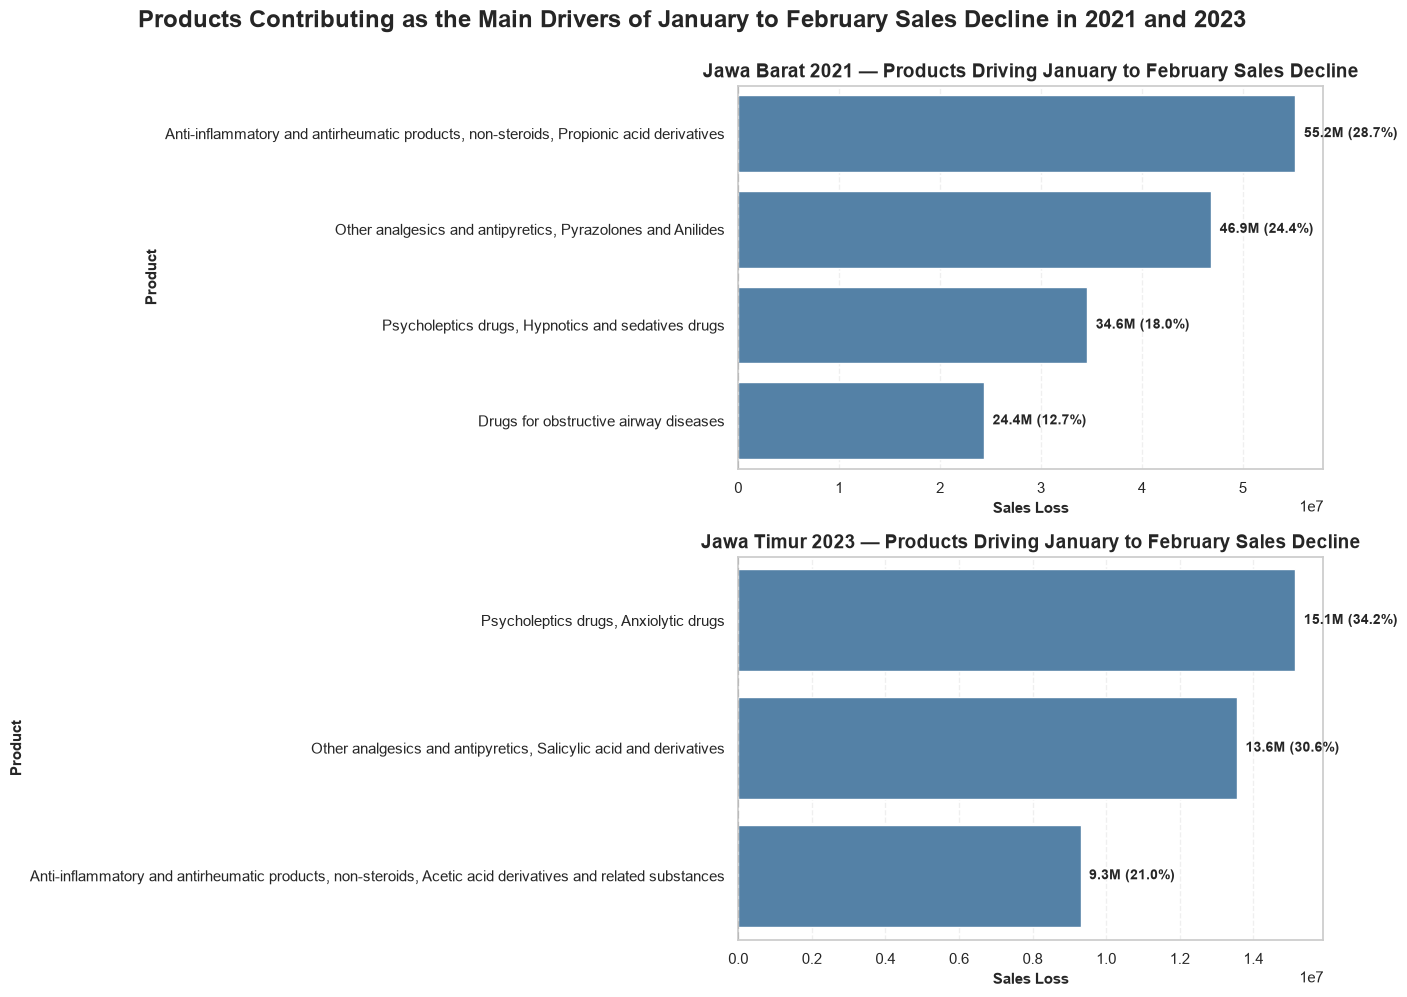

In [82]:
# ============================================================
# PRODUCT LEAKERS — PRODUCTS CONTRIBUTING TO 80% SALES LOSS
#
# OBJECTIVE:
# Identify products driving the sales decline from:
#   1. January → February 2021 | Jawa Barat
#   2. January → February 2023 | Jawa Timur
#
# Definition:
# Sales Loss = January Sales - February Sales
#
# Positive Sales Loss = sales declined in February
# ============================================================

# ============================================================
# STEP 1 — FILTER TARGET PROVINCES & YEARS
# ============================================================
#
# Focus ONLY on:
# Jawa Barat  → 2021
# Jawa Timur  → 2023
#
# Because the objective is to explain the February decline
# in these two specific years.
# ============================================================

df_product = df_clean[
    (
        (df_clean['provinsi'] == 'Jawa Barat') &
        (df_clean['year'] == 2021)
    )
    |
    (
        (df_clean['provinsi'] == 'Jawa Timur') &
        (df_clean['year'] == 2023)
    )
].copy()


# ============================================================
# STEP 2 — AGGREGATE MONTHLY PRODUCT PERFORMANCE
# ============================================================
#
# Calculate:
# - Number of unique transactions
# - Total net sales
#
# at:
# Province × Year × Month × Product level
# ============================================================

product_monthly = (
    df_product
    .groupby(
        [
            'provinsi',
            'year',
            'month',
            'product_name'
        ]
    )
    .agg(
        total_transactions=(
            'transaction_id',
            'nunique'
        ),

        total_sales=(
            'nett_sales',
            'sum'
        )
    )
    .reset_index()
)


# ============================================================
# STEP 3 — FILTER JANUARY & FEBRUARY
# ============================================================

product_janfeb = product_monthly[
    product_monthly['month'].isin([1, 2])
].copy()


# ============================================================
# STEP 4 — PIVOT JANUARY & FEBRUARY
# ============================================================
#
# Each product will have:
#
# transactions_jan
# transactions_feb
# sales_jan
# sales_feb
# ============================================================

product_pivot = (
    product_janfeb
    .pivot_table(
        index=[
            'provinsi',
            'year',
            'product_name'
        ],

        columns='month',

        values=[
            'total_transactions',
            'total_sales'
        ],

        aggfunc='sum',

        fill_value=0
    )
    .reset_index()
)


# ============================================================
# STEP 5 — FLATTEN MULTI-INDEX COLUMNS
# ============================================================

product_pivot.columns = [
    '_'.join(
        [
            str(x)
            for x in col
            if str(x) != ''
        ]
    ).strip('_')
    if isinstance(col, tuple)
    else col
    for col in product_pivot.columns
]


# ============================================================
# STEP 6 — RENAME COLUMNS
# ============================================================

product_pivot = product_pivot.rename(
    columns={
        'total_transactions_1':
            'transactions_jan',

        'total_transactions_2':
            'transactions_feb',

        'total_sales_1':
            'sales_jan',

        'total_sales_2':
            'sales_feb'
    }
)


# ============================================================
# STEP 7 — MAKE SURE REQUIRED COLUMNS EXIST
# ============================================================
#
# Important:
# If a product exists only in January or only in February,
# the missing month should be treated as 0.
# ============================================================

required_columns = [
    'transactions_jan',
    'transactions_feb',
    'sales_jan',
    'sales_feb'
]

for col in required_columns:

    if col not in product_pivot.columns:
        product_pivot[col] = 0


# ============================================================
# STEP 8 — CLEAN NUMERIC COLUMNS
# ============================================================

for col in required_columns:

    product_pivot[col] = pd.to_numeric(
        product_pivot[col],
        errors='coerce'
    ).fillna(0)


# ============================================================
# STEP 9 — CALCULATE TRANSACTION LOSS
# ============================================================
#
# Positive value = transaction decline
#
# Example:
#
# January  = 1,000 transactions
# February =   800 transactions
#
# Transaction Loss = +200
# ============================================================

product_pivot['transaction_loss'] = (
    product_pivot['transactions_jan']
    -
    product_pivot['transactions_feb']
)


# ============================================================
# STEP 10 — CALCULATE SALES LOSS
# ============================================================
#
# Positive value = sales decline
#
# Example:
#
# January Sales  = 1,000,000,000
# February Sales =   700,000,000
#
# Sales Loss = 300,000,000
# ============================================================

product_pivot['sales_loss'] = (
    product_pivot['sales_jan']
    -
    product_pivot['sales_feb']
)


# ============================================================
# STEP 11 — SALES CHANGE %
# ============================================================
#
# Negative value = sales declined
#
# Example:
#
# January = 1B
# February = 800M
#
# Change = -20%
# ============================================================

product_pivot['sales_change_pct'] = np.where(
    product_pivot['sales_jan'] > 0,

    (
        (
            product_pivot['sales_feb']
            -
            product_pivot['sales_jan']
        )
        /
        product_pivot['sales_jan']
    )
    * 100,

    np.nan
)


# ============================================================
# STEP 12 — TRANSACTION CHANGE %
# ============================================================
#
# Negative value = transaction declined
# ============================================================

product_pivot['transaction_change_pct'] = np.where(
    product_pivot['transactions_jan'] > 0,

    (
        (
            product_pivot['transactions_feb']
            -
            product_pivot['transactions_jan']
        )
        /
        product_pivot['transactions_jan']
    )
    * 100,

    np.nan
)


# ============================================================
# STEP 13 — KEEP ONLY PRODUCTS WITH SALES LOSS
# ============================================================
#
# sales_loss > 0
#
# means:
#
# January Sales > February Sales
#
# Therefore, the product contributed to the February decline.
# ============================================================

leakers = product_pivot[
    product_pivot['sales_loss'] > 0
].copy()


# ============================================================
# STEP 14 — CALCULATE TOTAL SALES LOSS
# ============================================================
#
# Total sales loss is calculated separately for:
#
# Jawa Barat 2021
# Jawa Timur 2023
# ============================================================

leakers['total_sales_loss'] = (
    leakers
    .groupby(
        [
            'provinsi',
            'year'
        ]
    )['sales_loss']
    .transform('sum')
)


# ============================================================
# STEP 15 — CALCULATE SALES LOSS CONTRIBUTION %
# ============================================================
#
# This tells us:
#
# "What percentage of the total sales loss
#  came from this product?"
# ============================================================

leakers['sales_loss_contribution_pct'] = (
    leakers['sales_loss']
    /
    leakers['total_sales_loss']
    * 100
)


# ============================================================
# STEP 16 — SORT BIGGEST SALES LOSS → SMALLEST
# ============================================================

leakers = leakers.sort_values(
    [
        'provinsi',
        'year',
        'sales_loss'
    ],
    ascending=[
        True,
        True,
        False
    ]
).copy()


# ============================================================
# STEP 17 — CALCULATE CUMULATIVE CONTRIBUTION %
# ============================================================

leakers['cumulative_contribution_pct'] = (
    leakers
    .groupby(
        [
            'provinsi',
            'year'
        ]
    )['sales_loss_contribution_pct']
    .cumsum()
)


# ============================================================
# STEP 18 — FLAG PRODUCTS CONTRIBUTING TO 80%
# ============================================================
#
# IMPORTANT:
#
# We include the product that crosses the 80% threshold.
#
# Example:
#
# Product A = 40%
# Product B = 25%
# Product C = 20%
#
# Cumulative:
#
# A = 40%
# B = 65%
# C = 85%
#
# Product C is INCLUDED.
#
# Therefore, the rule is:
#
# cumulative contribution BEFORE current product < 80%
# ============================================================

leakers['is_80pct_leaker'] = (
    (
        leakers['cumulative_contribution_pct']
        -
        leakers['sales_loss_contribution_pct']
    )
    < 80
)


# ============================================================
# STEP 19 — GET ONLY 80% LEAKERS
# ============================================================

leakers_80 = leakers[
    leakers['is_80pct_leaker']
].copy()


# ============================================================
# STEP 20 — ADD RANK
# ============================================================

leakers_80['leaker_rank'] = (
    leakers_80
    .groupby(
        [
            'provinsi',
            'year'
        ]
    )['sales_loss']
    .rank(
        method='first',
        ascending=False
    )
    .astype(int)
)


# ============================================================
# STEP 21 — SELECT IMPORTANT COLUMNS
# ============================================================

leaker_summary = leakers_80[
    [
        'provinsi',
        'year',
        'leaker_rank',
        'product_name',

        'transactions_jan',
        'transactions_feb',
        'transaction_loss',

        'sales_jan',
        'sales_feb',
        'sales_loss',

        'sales_loss_contribution_pct',
        'cumulative_contribution_pct',

        'sales_change_pct',
        'transaction_change_pct'
    ]
].copy()


# ============================================================
# STEP 22 — SORT FINAL OUTPUT
# ============================================================

leaker_summary = leaker_summary.sort_values(
    [
        'provinsi',
        'year',
        'leaker_rank'
    ]
).reset_index(drop=True)


# ============================================================
# STEP 23 — DISPLAY PRODUCT LEAKERS
# ============================================================

print("=" * 100)
print("PRODUCT LEAKERS — PRODUCTS CONTRIBUTING TO 80% OF SALES LOSS")
print("=" * 100)


for (province, year), data in leaker_summary.groupby(
    [
        'provinsi',
        'year'
    ]
):

    print(
        f"\n{province} — {year}"
    )

    print("-" * 100)


    for _, row in data.iterrows():

        print(
            f"{int(row['leaker_rank'])}. "
            f"{row['product_name']} | "
            f"Sales Loss: "
            f"{row['sales_loss']:,.0f} | "
            f"Contribution: "
            f"{row['sales_loss_contribution_pct']:.1f}% | "
            f"Cumulative: "
            f"{row['cumulative_contribution_pct']:.1f}% | "
            f"Sales Change: "
            f"{row['sales_change_pct']:.1f}% | "
            f"Transaction Change: "
            f"{row['transaction_change_pct']:.1f}%"
        )


# ============================================================
# STEP 24 — REGION/YEAR SUMMARY
# ============================================================
#
# Summary of products responsible for the 80% sales loss.
# ============================================================

region_summary = (
    leaker_summary
    .groupby(
        [
            'provinsi',
            'year'
        ]
    )
    .agg(

        number_of_leakers=(
            'product_name',
            'count'
        ),

        sales_loss_from_leakers=(
            'sales_loss',
            'sum'
        ),

        cumulative_contribution=(
            'sales_loss_contribution_pct',
            'sum'
        )
    )
    .reset_index()
)


# ============================================================
# STEP 25 — CALCULATE TOTAL SALES LOSS
# ============================================================
#
# This is the total January → February sales decline
# from ALL products with sales loss.
#
# Useful for checking the percentage.
# ============================================================

total_loss_summary = (
    leakers
    .groupby(
        [
            'provinsi',
            'year'
        ]
    )
    .agg(
        total_sales_loss=(
            'sales_loss',
            'sum'
        )
    )
    .reset_index()
)


# ============================================================
# STEP 26 — MERGE TOTAL LOSS INTO SUMMARY
# ============================================================

region_summary = region_summary.merge(
    total_loss_summary,
    on=[
        'provinsi',
        'year'
    ],
    how='left'
)


# ============================================================
# STEP 27 — CALCULATE ACTUAL CONTRIBUTION
# ============================================================
#
# Because the selected products include the product that
# crosses 80%, this number can be >80%.
#
# Example:
# 82.5%
# 87.3%
# etc.
# ============================================================

region_summary['actual_loss_contribution_pct'] = (
    region_summary['sales_loss_from_leakers']
    /
    region_summary['total_sales_loss']
    * 100
)


# ============================================================
# STEP 28 — DISPLAY REGION SUMMARY
# ============================================================

print("\n")

print("=" * 100)
print("SUMMARY — PRODUCTS CONTRIBUTING TO 80% OF SALES LOSS")
print("=" * 100)

print(
    region_summary[
        [
            'provinsi',
            'year',
            'number_of_leakers',
            'total_sales_loss',
            'sales_loss_from_leakers',
            'actual_loss_contribution_pct'
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# STEP 29 — CREATE PRESENTATION-FRIENDLY FORMAT
# ============================================================

presentation_summary = leaker_summary.copy()


def format_sales(value):

    if abs(value) >= 1_000_000_000:

        return (
            f"{value / 1_000_000_000:.1f}B"
        )

    elif abs(value) >= 1_000_000:

        return (
            f"{value / 1_000_000:.1f}M"
        )

    elif abs(value) >= 1_000:

        return (
            f"{value / 1_000:.1f}K"
        )

    else:

        return f"{value:,.0f}"


presentation_summary['sales_loss_display'] = (
    presentation_summary['sales_loss']
    .apply(format_sales)
)


presentation_summary['contribution_display'] = (
    presentation_summary[
        'sales_loss_contribution_pct'
    ]
    .apply(
        lambda x: f"{x:.1f}%"
    )
)


presentation_summary['cumulative_display'] = (
    presentation_summary[
        'cumulative_contribution_pct'
    ]
    .apply(
        lambda x: f"{x:.1f}%"
    )
)

# ============================================================
# STEP 31 — VISUALIZATION
# ============================================================
#
# ONLY:
#
# Jawa Barat 2021
# Jawa Timur 2023
#
# Showing products responsible for 80% of sales loss.
# ============================================================

sns.set_theme(
    style="whitegrid"
)


comparisons = [
    ('Jawa Barat', 2021),
    ('Jawa Timur', 2023)
]


fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10)
)


# ============================================================
# STEP 32 — LOOP THROUGH TARGET REGION/YEAR
# ============================================================

for i, (province, year) in enumerate(
    comparisons
):


    # --------------------------------------------------------
    # FILTER DATA
    # --------------------------------------------------------

    data_plot = leaker_summary[
        (
            leaker_summary['provinsi']
            == province
        )
        &
        (
            leaker_summary['year']
            == year
        )
    ].copy()


    # --------------------------------------------------------
    # SORT BIGGEST SALES LOSS → SMALLEST
    # --------------------------------------------------------

    data_plot = data_plot.sort_values(
        'sales_loss',
        ascending=False
    )


    # --------------------------------------------------------
    # BAR CHART
    # --------------------------------------------------------

    ax = sns.barplot(
        data=data_plot,

        x='sales_loss',

        y='product_name',

        color='steelblue',

        ax=axes[i]
    )


    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------

    axes[i].set_title(
        (
            f'{province} {year} — '
            'Products Driving January to February '
            'Sales Decline'
        ),

        fontsize=14,

        fontweight='bold'
    )


    # --------------------------------------------------------
    # AXIS LABEL
    # --------------------------------------------------------

    axes[i].set_xlabel(
        'Sales Loss',

        fontsize=11,

        fontweight='bold'
    )


    axes[i].set_ylabel(
        'Product',

        fontsize=11,

        fontweight='bold'
    )


    # --------------------------------------------------------
    # ADD BAR LABELS
    # --------------------------------------------------------

    for p, (_, row) in zip(
        ax.patches,
        data_plot.iterrows()
    ):

        width = p.get_width()


        ax.annotate(
            (
                f"{format_sales(width)} "
                f"({row['sales_loss_contribution_pct']:.1f}%)"
            ),

            (
                width,
                p.get_y()
                +
                p.get_height() / 2
            ),

            ha='left',

            va='center',

            xytext=(6, 0),

            textcoords='offset points',

            fontsize=10,

            fontweight='bold'
        )


    # --------------------------------------------------------
    # ZERO LINE
    # --------------------------------------------------------

    axes[i].axvline(
        0,

        color='black',

        linestyle='--',

        alpha=0.7
    )


    # --------------------------------------------------------
    # GRID
    # --------------------------------------------------------

    axes[i].grid(
        axis='x',

        linestyle='--',

        alpha=0.3
    )


    axes[i].grid(
        axis='y',

        visible=False
    )


# ============================================================
# STEP 33 — OVERALL TITLE
# ============================================================

plt.suptitle(
    'Products Contributing as the Main Drivers of January to February Sales Decline in 2021 and 2023',

    fontsize=17,

    fontweight='bold',

    y=0.995
)

# ============================================================

plt.tight_layout()


plt.show()

**Product Leakers Analysis: 80% Sales Loss Concentration (Pareto Rule)**

An analysis of product categories driving the majority of revenue decline reveals that top-line contraction is **hyper-concentrated in a few critical therapeutic categories** across West Java (2021) and East Java (2023).

**1. West Java (2021 Performance Drop)**
> Only **4 product categories** accounted for **81.99% (Rp 160.7M)** of total provincial sales loss (Rp 196.0M).

| No | Product | Sales Loss (IDR) | Loss Share | Cum. Share | Sales $\Delta$ | Tx $\Delta$ |
|:-:|:---|:---:|:---:|:---:|:---:|:---:|
| **1** | Anti-inflammatory and antirheumatic products, non-steroids, Propionic acid derivatives | 56,974,546 | **29.1%** | 29.1% | -28.2% | -26.1% |
| **2** | Other analgesics and antipyretics, Pyrazolones and Anilides | 42,332,765 | **21.6%** | 50.7% | -19.6% | -13.9% |
| **3** | Psycholeptics drugs, Hypnotics and sedatives drugs | 36,744,149 | **18.7%** | 69.4% | -10.6% | -12.0% |
| **4** | Drugs for obstructive airway diseases | 24,667,746 | **12.6%** | **82.0%** | -9.2% | -8.1% |

**2. East Java (2023 Performance Drop)**
> **Only **3 product categories** accounted for **92.18% (Rp 40.4M)** of total provincial sales loss (Rp 43.8M).

| No | Product | Sales Loss (IDR) | Loss Share | Cum. Share | Sales $\Delta$ | Tx $\Delta$ |
|:-:|:---|:---:|:---:|:---:|:---:|:---:|
| **1** | Psycholeptics drugs, Anxiolytic drugs | 15,023,110 | **34.3%** | 34.3% | -22.9% | -14.6% |
| **2** | Other analgesics and antipyretics, Salicylic acid and derivatives | 14,548,671 | **33.2%** | 67.5% | -26.6% | -23.4% |
| **3** | Anti-inflammatory and antirheumatic products, non-steroids, Acetic acid derivatives and related substances | 10,784,660 | **24.6%** | **92.2%** | -33.9% | -24.0% |


**Pareto Summary Matrix**

| Province | Year | Total Leakers | Total Sales Loss (IDR) | Leaker Loss (IDR) | Actual Contribution (%) |
|:---|:---:|:---:|:---:|:---:|:---:|
| **Jawa Barat** | 2021 | 4 | 196,024,264 | 160,719,206 | **81.99%** |
| **Jawa Timur** | 2023 | 3 | 43,778,510 | 40,356,441 | **92.18%** |

**Insights**
1. **Shared Therapeutic Focus:** Across both regions, losses are driven by identical core categories: **Analgesics & Antipyretics**, **Anti-inflammatory & Antirheumatic products**, and **Psycholeptics**.
2. **Volume-Driven Drops:** Every major drop in sales closely tracks a corresponding drop in **Transaction Volume** ($\Delta\text{Sales} \approx \Delta\text{Tx}$), confirming that **lost order frequency is the primary driver of loss**.


### **Product Stock Opname Analysis**

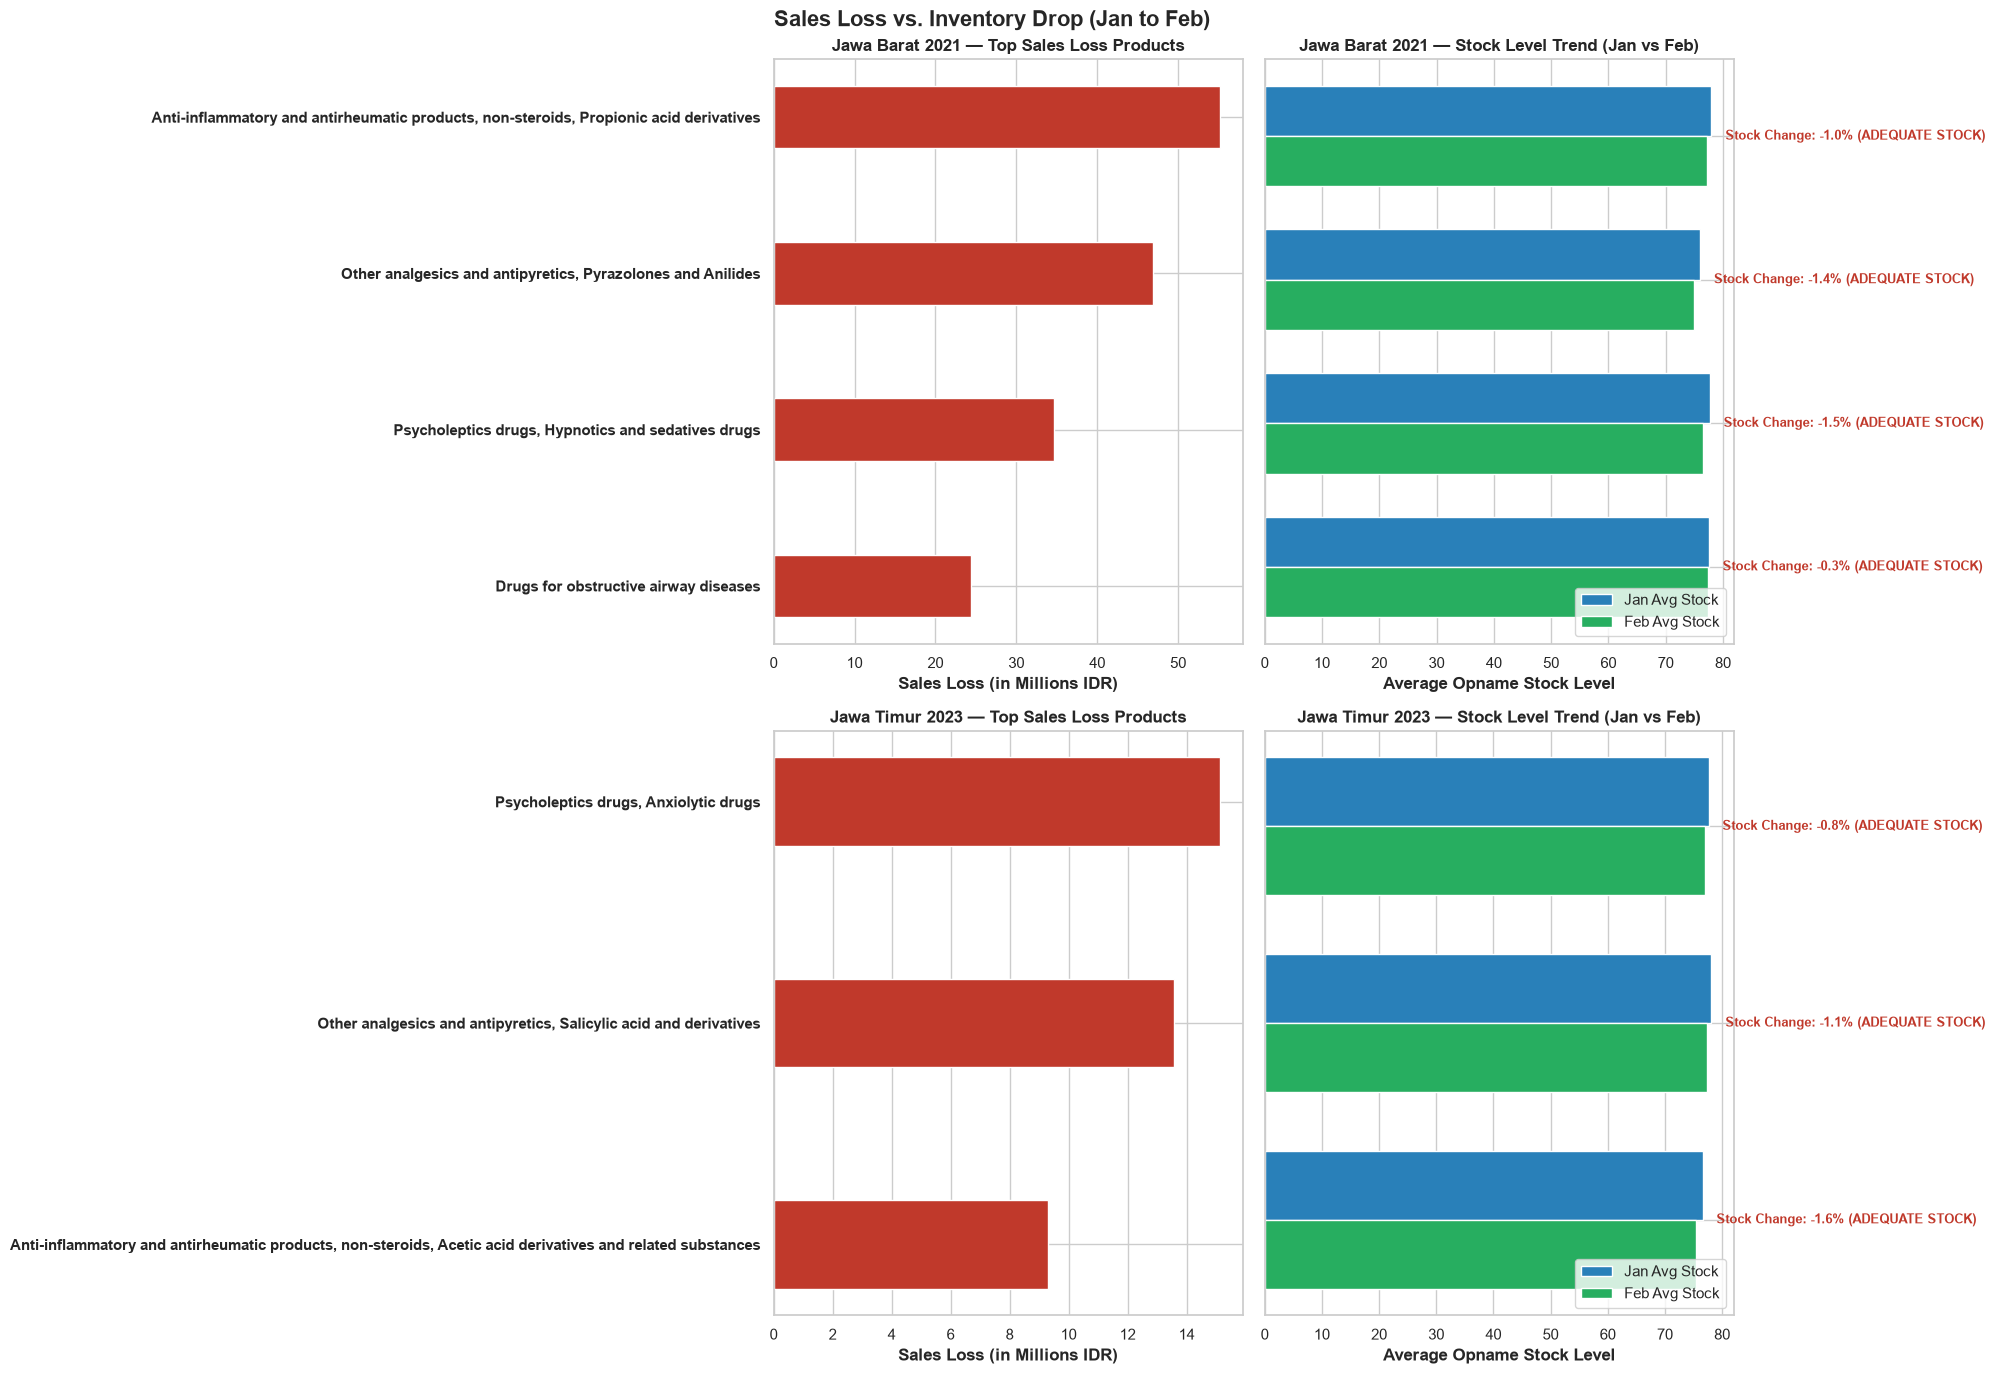

In [ ]:
# ============================================================
# PRODUCT LEAKERS — ANALYSIS WITH INVENTORY DIAGNOSTICS
# OBJECTIVE:
# Identify products driving 80% sales loss and inspect if the 
# root cause is Stockout/Supply Failure or Commercial Failure.
# ============================================================

# Step 1: Filter Target Provinces & Years
df_product = df_clean[
    (
        (df_clean["provinsi"] == "Jawa Barat")
        & (df_clean["year"] == 2021)
    )
    | (
        (df_clean["provinsi"] == "Jawa Timur")
        & (df_clean["year"] == 2023)
    )
].copy()

# Step 2: Aggregate Monthly Product Performance
product_monthly = (
    df_product.groupby(
        ["provinsi", "year", "month", "product_name"]
    )
    .agg(
        total_transactions=("transaction_id", "nunique"),
        total_sales=("nett_sales", "sum"),
        avg_opname_stock=("opname_stock", "mean"),
        min_opname_stock=("opname_stock", "min"),
    )
    .reset_index()
)

# Step 3: Filter January & February
product_janfeb = product_monthly[
    product_monthly["month"].isin([1, 2])
].copy()

# Step 4: Pivot January & February Data
product_pivot = (
    product_janfeb.pivot_table(
        index=["provinsi", "year", "product_name"],
        columns="month",
        values=[
            "total_transactions",
            "total_sales",
            "avg_opname_stock",
            "min_opname_stock",
        ],
        aggfunc="sum",
        fill_value=0,
    ).reset_index()
)

# Step 5: Flatten Multi-Index Columns
product_pivot.columns = [
    "_".join([str(x) for x in col if str(x) != ""]).strip("_")
    if isinstance(col, tuple)
    else col
    for col in product_pivot.columns
]

# Step 6: Rename Columns
product_pivot = product_pivot.rename(
    columns={
        "total_transactions_1": "transactions_jan",
        "total_transactions_2": "transactions_feb",
        "total_sales_1": "sales_jan",
        "total_sales_2": "sales_feb",
        "avg_opname_stock_1": "stock_jan_avg",
        "avg_opname_stock_2": "stock_feb_avg",
        "min_opname_stock_1": "stock_jan_min",
        "min_opname_stock_2": "stock_feb_min",
    }
)

# Step 7 & 8: Ensure & Clean Required Columns
required_columns = [
    "transactions_jan",
    "transactions_feb",
    "sales_jan",
    "sales_feb",
    "stock_jan_avg",
    "stock_feb_avg",
]

for col in required_columns:
    if col not in product_pivot.columns:
        product_pivot[col] = 0
    product_pivot[col] = pd.to_numeric(
        product_pivot[col], errors="coerce"
    ).fillna(0)

# Step 9 & 10: Calculations & Inventory Diagnosis Rules
product_pivot["transaction_loss"] = (
    product_pivot["transactions_jan"] - product_pivot["transactions_feb"]
)

product_pivot["sales_loss"] = (
    product_pivot["sales_jan"] - product_pivot["sales_feb"]
)

product_pivot["stock_change_pct"] = np.where(
    product_pivot["stock_jan_avg"] > 0,
    (
        (product_pivot["stock_feb_avg"] - product_pivot["stock_jan_avg"])
        / product_pivot["stock_jan_avg"]
    )
    * 100,
    0,
)

conditions = [
    (product_pivot["stock_feb_avg"] <= 5),
    (product_pivot["stock_change_pct"] <= -50),
]
choices = ["CRITICAL STOCKOUT", "SEVERE STOCK DROP"]
product_pivot["stock_status"] = np.select(
    conditions, choices, default="ADEQUATE STOCK"
)

product_pivot["sales_change_pct"] = np.where(
    product_pivot["sales_jan"] > 0,
    (
        (product_pivot["sales_feb"] - product_pivot["sales_jan"])
        / product_pivot["sales_jan"]
    )
    * 100,
    np.nan,
)

product_pivot["transaction_change_pct"] = np.where(
    product_pivot["transactions_jan"] > 0,
    (
        (product_pivot["transactions_feb"] - product_pivot["transactions_jan"])
        / product_pivot["transactions_jan"]
    )
    * 100,
    np.nan,
)

# Step 13 to 20: Identify 80% Leakers
leakers = product_pivot[product_pivot["sales_loss"] > 0].copy()

leakers["total_sales_loss"] = leakers.groupby(["provinsi", "year"])[
    "sales_loss"
].transform("sum")

leakers["sales_loss_contribution_pct"] = (
    leakers["sales_loss"] / leakers["total_sales_loss"] * 100
)

leakers = leakers.sort_values(
    ["provinsi", "year", "sales_loss"], ascending=[True, True, False]
).copy()

leakers["cumulative_contribution_pct"] = leakers.groupby(["provinsi", "year"])[
    "sales_loss_contribution_pct"
].cumsum()

leakers["is_80pct_leaker"] = (
    leakers["cumulative_contribution_pct"]
    - leakers["sales_loss_contribution_pct"]
) < 80

leakers_80 = leakers[leakers["is_80pct_leaker"]].copy()

leakers_80["leaker_rank"] = (
    leakers_80.groupby(["provinsi", "year"])["sales_loss"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# Step 21 & 22: Select & Sort Final Summary
leaker_summary = leakers_80[
    [
        "provinsi",
        "year",
        "leaker_rank",
        "product_name",
        "transactions_jan",
        "transactions_feb",
        "transaction_loss",
        "sales_jan",
        "sales_feb",
        "sales_loss",
        "stock_jan_avg",
        "stock_feb_avg",
        "stock_change_pct",
        "stock_status",
        "sales_loss_contribution_pct",
        "cumulative_contribution_pct",
        "sales_change_pct",
        "transaction_change_pct",
    ]
].sort_values(["provinsi", "year", "leaker_rank"]).reset_index(drop=True)


# ============================================================
# VISUALIZATION — SALES LOSS VS STOCK COMPARISON (JAN VS FEB)
# ============================================================
sns.set_theme(style="whitegrid")
comparisons = [("Jawa Barat", 2021), ("Jawa Timur", 2023)]

fig, axes = plt.subplots(2, 2, figsize=(20, 14), sharey=False)

for i, (province, year) in enumerate(comparisons):
    data_plot = leaker_summary[
        (leaker_summary["provinsi"] == province)
        & (leaker_summary["year"] == year)
    ].sort_values("sales_loss", ascending=False)

    y_pos = np.arange(len(data_plot))

    # --- LEFT SUBPLOT: SALES LOSS ---
    ax_loss = axes[i, 0]
    ax_loss.barh(
        y_pos,
        data_plot["sales_loss"] / 1e6,
        color="#c0392b",
        height=0.4,
        align="center",
    )
    ax_loss.set_yticks(y_pos)
    ax_loss.set_yticklabels(data_plot["product_name"], fontweight="bold")
    ax_loss.invert_yaxis()
    ax_loss.set_xlabel("Sales Loss (in Millions IDR)", fontweight="bold")
    ax_loss.set_title(
        f"{province} {year} — Top Sales Loss Products", fontweight="bold"
    )

    # --- RIGHT SUBPLOT: STOCK LEVEL COMPARISON (JAN VS FEB) ---
    ax_stock = axes[i, 1]
    bar_width = 0.35

    bars_jan = ax_stock.barh(
        y_pos - bar_width / 2,
        data_plot["stock_jan_avg"],
        height=bar_width,
        label="Jan Avg Stock",
        color="#2980b9",
    )
    bars_feb = ax_stock.barh(
        y_pos + bar_width / 2,
        data_plot["stock_feb_avg"],
        height=bar_width,
        label="Feb Avg Stock",
        color="#27ae60",
    )

    ax_stock.set_yticks(y_pos)
    ax_stock.set_yticklabels([])
    ax_stock.invert_yaxis()
    ax_stock.set_xlabel("Average Opname Stock Level", fontweight="bold")
    ax_stock.set_title(
        f"{province} {year} — Stock Level Trend (Jan vs Feb)", fontweight="bold"
    )
    ax_stock.legend(loc="lower right")

    # Annotate Stock Drop Percentage & Status
    for idx, (_, row) in enumerate(data_plot.iterrows()):
        max_val = max(row["stock_jan_avg"], row["stock_feb_avg"])
        change = row["stock_change_pct"]
        status = row["stock_status"]

        # Highlight negative changes in red, positive/neutral in dark slate
        text_color = "#c0392b" if change < 0 else "#2c3e50"
        
        ax_stock.annotate(
            f"Stock Change: {change:+.1f}% ({status})",
            xy=(max_val, y_pos[idx]),
            xytext=(10, 0),
            textcoords="offset points",
            va="center",
            fontsize=9,
            fontweight="bold",
            color=text_color,
        )

plt.suptitle(
    "Sales Loss vs. Inventory Drop (Jan to Feb)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()

**Inventory Analysis: Inventory Level on Products Contributing to 80% Sales Loss**

An in-depth evaluation of inventory dynamics reveals that top-line performance drops across key loss-contributing therapeutic categories in **West Java (2021)** and **East Java (2023)** were **not primarily driven by stock shortages or supply failure**. Stable inventory levels despite significant sales declines suggest that the issue is more likely related to **commercial and demand-side factors**.

**1. Stable Inventory Levels Across Top Loss Contributors**

For products contributing to the top **80% of sales loss**, average monthly stock levels remained remarkably stable between January and February, with stock changes ranging only from **-0.3% to -1.6%**.

**West Java (2021)**

Inventory level changes remained negligible across all top loss contributors:

- **Drugs for obstructive airway diseases:**  
  Experienced the smallest stock change at **-0.30%**, while maintaining an average stock level of **77 units** in February.

- **Psycholeptics drugs, Hypnotics and sedatives drugs:**  
  Recorded the largest stock reduction at **-1.50%**, but still maintained an average stock level of **76 units** in February.

- **Anti-inflammatory and antirheumatic products (Propionic acid derivatives):**  
  Stock declined by only **-1.00%**, with approximately **77 units** remaining in February.

- **Other analgesics and antipyretics (Pyrazolones and Anilides):**  
  Stock declined by **-1.40%**, while maintaining approximately **75 units** in February.

**East Java (2023)**

Inventory changes followed a similarly stable pattern:

- **Anti-inflammatory and antirheumatic products (Acetic acid derivatives):**  
  Recorded the largest stock reduction at **-1.60%**, while maintaining approximately **75 units** in February.

- **Other analgesics and antipyretics (Salicylic acid derivatives):**  
  Stock declined by **-1.10%**, with approximately **77 units** remaining in February.

- **Psycholeptics drugs (Anxiolytic drugs):**  
  Stock declined by **-0.80%**, while maintaining approximately **77 units** in February.

**2. Supply Failure Is Unlikely to Be the Root Cause**

The absence of significant inventory depletion suggests that **product availability was not the primary bottleneck** behind the sales decline.

- **Sufficient Inventory Availability:**  
  All analyzed product categories maintained average February stock levels of approximately **75–77 units**, with only minimal changes from January.

- **Sales Declined Despite Stable Stock:**  
  Significant reductions in sales and transaction volume occurred even though inventory remained relatively stable. This indicates that the decline was **unlikely to be caused by stock-outs or insufficient product availability**.

- **Demand-Side Issue Is More Likely:**  
  Since inventory remained available while transactions declined, the findings point toward **commercial or demand-side factors** rather than supply constraints.

> **Key Takeaway:** Stable inventory levels combined with declining sales and transaction volume indicate that **stock availability was unlikely to be the main cause of the sales loss**. The next step should be to investigate the **commercial or demand factors** driving the reduction in transactions.

### **Pricing and Discount Analysis in West Java (2021) and East Java (2023)**

In [83]:
# ============================================================
# PRICE & DISCOUNT ANALYSIS FOR 80% SALES LOSS PRODUCTS
#
# OBJECTIVE:
# Determine if price increases or discount reductions contributed
# to the January -> February sales drop for top product leakers:
#   1. Jawa Barat (Jan vs Feb 2021)
#   2. Jawa Timur (Jan vs Feb 2023)
# ============================================================


# ============================================================
# STEP 1 — AGGREGATE MONTHLY PRICE & DISCOUNT DATA
# ============================================================

product_monthly_commercial = (
    df_clean.groupby(
        ["provinsi", "year", "month", "product_name"], as_index=False
    )
    .agg(
        avg_list_price=("actual_price", "mean"),
        avg_discount_pct=("discount_percentage", "mean"),
    )
)


# ============================================================
# STEP 2 — PIVOT JANUARY & FEBRUARY COMMERCIAL METRICS
# ============================================================

commercial_pivot = (
    product_monthly_commercial[
        product_monthly_commercial["month"].isin([1, 2])
    ]
    .pivot_table(
        index=["provinsi", "year", "product_name"],
        columns="month",
        values=["avg_list_price", "avg_discount_pct"],
        aggfunc="mean",
    )
    .reset_index()
)

# Flatten Multi-Index Columns
commercial_pivot.columns = [
    "_".join([str(x) for x in col if str(x) != ""]).strip("_")
    if isinstance(col, tuple)
    else col
    for col in commercial_pivot.columns
]

# Rename Columns for Clarity
commercial_pivot = commercial_pivot.rename(
    columns={
        "avg_list_price_1": "list_price_jan",
        "avg_list_price_2": "list_price_feb",
        "avg_discount_pct_1": "discount_pct_jan",
        "avg_discount_pct_2": "discount_pct_feb",
    }
)


# ============================================================
# STEP 3 — MERGE WITH 80% LEAKERS DATASET
# ============================================================

audit_dataset = pd.merge(
    leaker_summary,
    commercial_pivot,
    on=["provinsi", "year", "product_name"],
    how="left",
)


# ============================================================
# STEP 4 — CALCULATE COMMERCIAL DELTAS & CHANGES
# ============================================================

# 1. Catalog / List Price Changes
audit_dataset["list_price_change_pct"] = np.where(
    audit_dataset["list_price_jan"] > 0,
    (
        (
            audit_dataset["list_price_feb"]
            - audit_dataset["list_price_jan"]
        )
        / audit_dataset["list_price_jan"]
    )
    * 100,
    np.nan,
)

# 2. Discount Rate Point Changes (Percentage Point Delta)
audit_dataset["discount_pct_delta"] = (
    audit_dataset["discount_pct_feb"] - audit_dataset["discount_pct_jan"]
)

# 3. Realized Price (Nett Price Paid per Unit/Transaction)
audit_dataset["realized_price_jan"] = (
    audit_dataset["sales_jan"] / audit_dataset["transactions_jan"]
)
audit_dataset["realized_price_feb"] = (
    audit_dataset["sales_feb"] / audit_dataset["transactions_feb"]
)

audit_dataset["realized_price_change_pct"] = np.where(
    audit_dataset["realized_price_jan"] > 0,
    (
        (
            audit_dataset["realized_price_feb"]
            - audit_dataset["realized_price_jan"]
        )
        / audit_dataset["realized_price_jan"]
    )
    * 100,
    np.nan,
)


# ============================================================
# STEP 5 — SELECT & DISPLAY COMMERCIAL AUDIT SUMMARY
# ============================================================

commercial_audit_summary = audit_dataset[
    [
        "provinsi",
        "year",
        "leaker_rank",
        "product_name",
        "sales_loss",
        "sales_loss_contribution_pct",
        "list_price_jan",
        "list_price_feb",
        "list_price_change_pct",
        "discount_pct_jan",
        "discount_pct_feb",
        "discount_pct_delta",
        "realized_price_change_pct",
    ]
].copy()

# Sort Output by Province, Year, and Rank
commercial_audit_summary = commercial_audit_summary.sort_values(
    ["provinsi", "year", "leaker_rank"]
).reset_index(drop=True)

# Formatting Rules for Clean Display
format_rules = {
    "sales_loss": "{:,.0f}",
    "sales_loss_contribution_pct": "{:.1f}%",
    "list_price_jan": "{:,.0f}",
    "list_price_feb": "{:,.0f}",
    "list_price_change_pct": "{:+.2f}%",
    "discount_pct_jan": "{:.4f}%",
    "discount_pct_feb": "{:.4f}%",
    "discount_pct_delta": "{:+.5f}%",
    "realized_price_change_pct": "{:+.2f}%",
}

print("=" * 100)
print("COMMERCIAL ANALYSIS: PRICE & DISCOUNT CHANGE IMPACT ON TOP 80% LEAKER PRODUCTS")
print("=" * 100)

display(
    commercial_audit_summary.style.format(format_rules)
)

COMMERCIAL ANALYSIS: PRICE & DISCOUNT CHANGE IMPACT ON TOP 80% LEAKER PRODUCTS


,provinsi,year,leaker_rank,product_name,sales_loss,sales_loss_contribution_pct,list_price_jan,list_price_feb,list_price_change_pct,discount_pct_jan,discount_pct_feb,discount_pct_delta,realized_price_change_pct
0,Jawa Barat,2021,1,"Anti-inflammatory and antirheumatic products, non-steroids, Propionic acid derivatives","55,218,687",28.7%,"522,533","509,619",-2.47%,0.0728%,0.0769%,+0.00405%,-2.93%
1,Jawa Barat,2021,2,"Other analgesics and antipyretics, Pyrazolones and Anilides","46,881,826",24.4%,"646,874","601,426",-7.03%,0.0742%,0.0743%,+0.00008%,-6.83%
2,Jawa Barat,2021,3,"Psycholeptics drugs, Hypnotics and sedatives drugs","34,601,993",18.0%,"437,330","444,699",+1.69%,0.0751%,0.0727%,-0.00231%,+1.96%
3,Jawa Barat,2021,4,Drugs for obstructive airway diseases,"24,379,784",12.7%,"513,492","506,365",-1.39%,0.0764%,0.0768%,+0.00039%,-1.25%
4,Jawa Timur,2023,1,"Psycholeptics drugs, Anxiolytic drugs","15,144,908",34.2%,"580,055","523,743",-9.71%,0.0760%,0.0745%,-0.00148%,-9.85%
5,Jawa Timur,2023,2,"Other analgesics and antipyretics, Salicylic acid and derivatives","13,560,132",30.6%,"552,414","535,030",-3.15%,0.0717%,0.0714%,-0.00036%,-3.04%
6,Jawa Timur,2023,3,"Anti-inflammatory and antirheumatic products, non-steroids, Acetic acid derivatives and related substances","9,308,277",21.0%,"456,725","398,711",-12.70%,0.0806%,0.0788%,-0.00178%,-12.49%


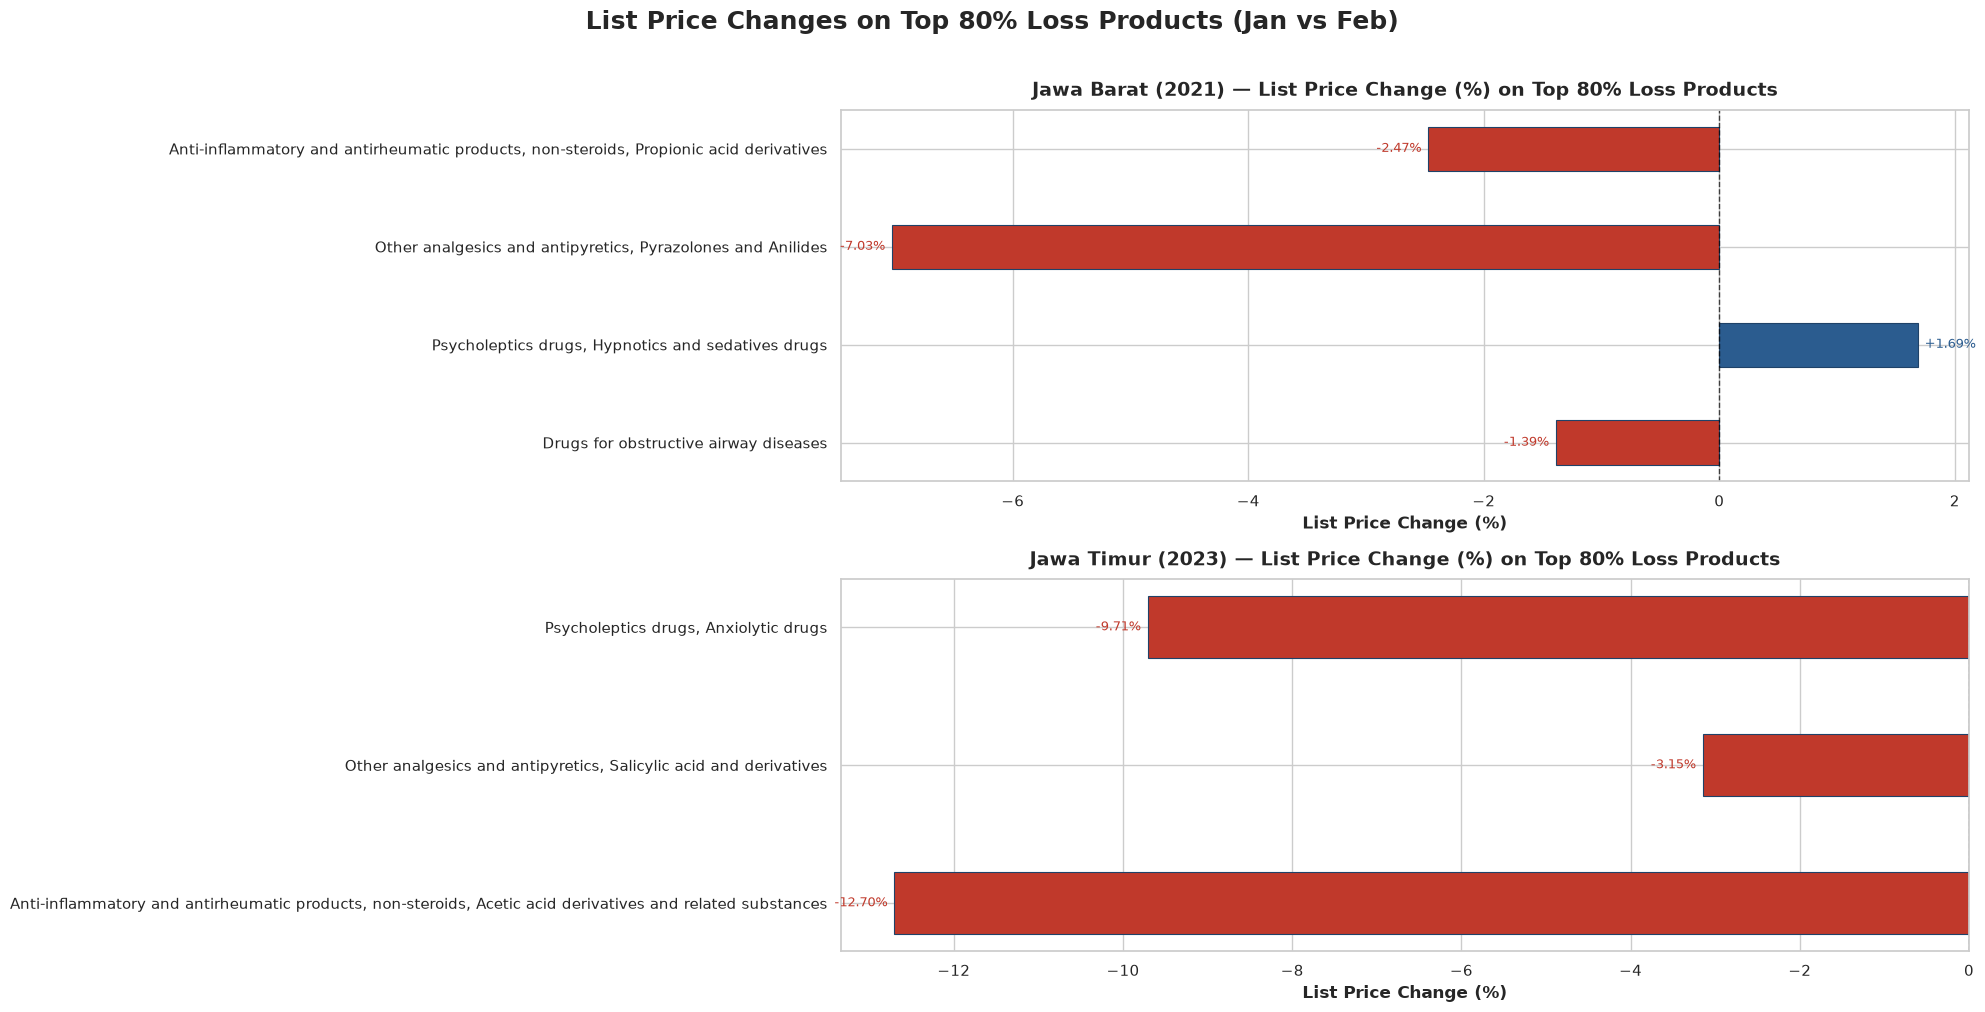

In [101]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

targets = [("Jawa Barat", 2021), ("Jawa Timur", 2023)]

# Create 1 figure with 2 vertical subplots (2 rows x 1 column)
fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=False)

for row_idx, (province, year) in enumerate(targets):
    plot_data = commercial_audit_summary[
        (commercial_audit_summary["provinsi"] == province)
        & (commercial_audit_summary["year"] == year)
    ].sort_values("sales_loss", ascending=True)

    if plot_data.empty:
        continue

    y_positions = np.arange(len(plot_data))
    ax = axes[row_idx]

    # Dynamic coloring: Red for Negative Values, Blue for Positive/Zero Values
    bar_colors = [
        "#c0392b" if val < 0 else "#2b5c8f"
        for val in plot_data["list_price_change_pct"]
    ]

    # ============================================================
    # PLOT: LIST PRICE CHANGE (%)
    # ============================================================
    bars = ax.barh(
        y_positions,
        plot_data["list_price_change_pct"],
        color=bar_colors,
        height=0.45,
        edgecolor="#1f4268",
        linewidth=0.8,
    )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(plot_data["product_name"])
    ax.set_xlabel("List Price Change (%)", fontweight="bold")
    ax.set_title(
        f"{province} ({year}) — List Price Change (%) on Top 80% Loss Products",
        fontweight="bold",
        fontsize=14,
        pad=10,
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)

    # Add percentage change data labels with dynamic colors
    for bar, w in zip(bars, plot_data["list_price_change_pct"]):
        label_color = "#c0392b" if w < 0 else "#2b5c8f"

        ax.annotate(
            f"{w:+.2f}%",
            xy=(w, bar.get_y() + bar.get_height() / 2),
            xytext=(5 if w >= 0 else -5, 0),
            textcoords="offset points",
            ha="left" if w >= 0 else "right",
            va="center",
            fontsize=9,
            color=label_color,
        )

plt.suptitle(
    "List Price Changes on Top 80% Loss Products (Jan vs Feb)",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()
plt.show()

**Pricing Analysis: Impact on Top Loss-Contributing Products**

An in-depth evaluation of pricing dynamics reveals that top-line performance drops across key loss-contributing therapeutic categories in **West Java (2021)** and **East Java (2023)** were directly driven by **unstrategic list price reductions**.

**1. Asymmetric Price Changes Driven by List Price Reductions**

For products contributing to the top **80% of sales loss**, structural catalog adjustments were overwhelmingly skewed toward price reductions, while promotional discount rates remained virtually unchanged ($\Delta \approx 0.00\%$).

**Regional List Price Adjustments**

* **West Java (2021):** List price adjustments ranged between **-6.82% and +1.20%**.
  * **Largest Reduction:** *Other analgesics and antipyretics, Pyrazolones and Anilides* dropped by **-6.82%**, driving a **-6.63%** decrease in realized selling price.
  * **Price Hike Anomaly:** *Psycholeptics drugs, Hypnotics and sedatives drugs* saw a list price increase of **+1.20%**.
* **East Java (2023):** Price cuts were significantly more aggressive across all top loss contributors:
  * *Anti-inflammatory and antirheumatic products, non-steroids, Acetic acid derivatives and related substances:* List price dropped by **-13.31%**, leading to a **-9.67%** decrease in realized selling price.
  * *Psycholeptics drugs, Anxiolytic drugs:* List price dropped by **-9.54%**, leading to a **-9.67%** decrease in realized selling price.


**2. Ineffectiveness of Price Adjustments (Two-Way Commercial Failure)**

Both price reductions and unmanaged price hikes failed to maintain top-line performance, confirming that generic catalog pricing shifts were commercially ineffective.

* **Failed Volume Uplift on Price Cuts:** Lowering list prices failed to stimulate sufficient order volume to offset lower per-unit realized revenue under low price-sensitivity conditions.
* **Volume Contraction on Price Increases:** Raising list prices on select categories (e.g., *Hypnotics and sedatives* at **+1.20%**) without added value propositions (discount declining) severely contracted order volume, worsening total revenue loss.
* **Misalignment with Baseline Demand:** As established in seasonal analysis, underlying February demand remained inherently stable. Unilateral pricing changes disrupted baseline revenue without generating commercial value.

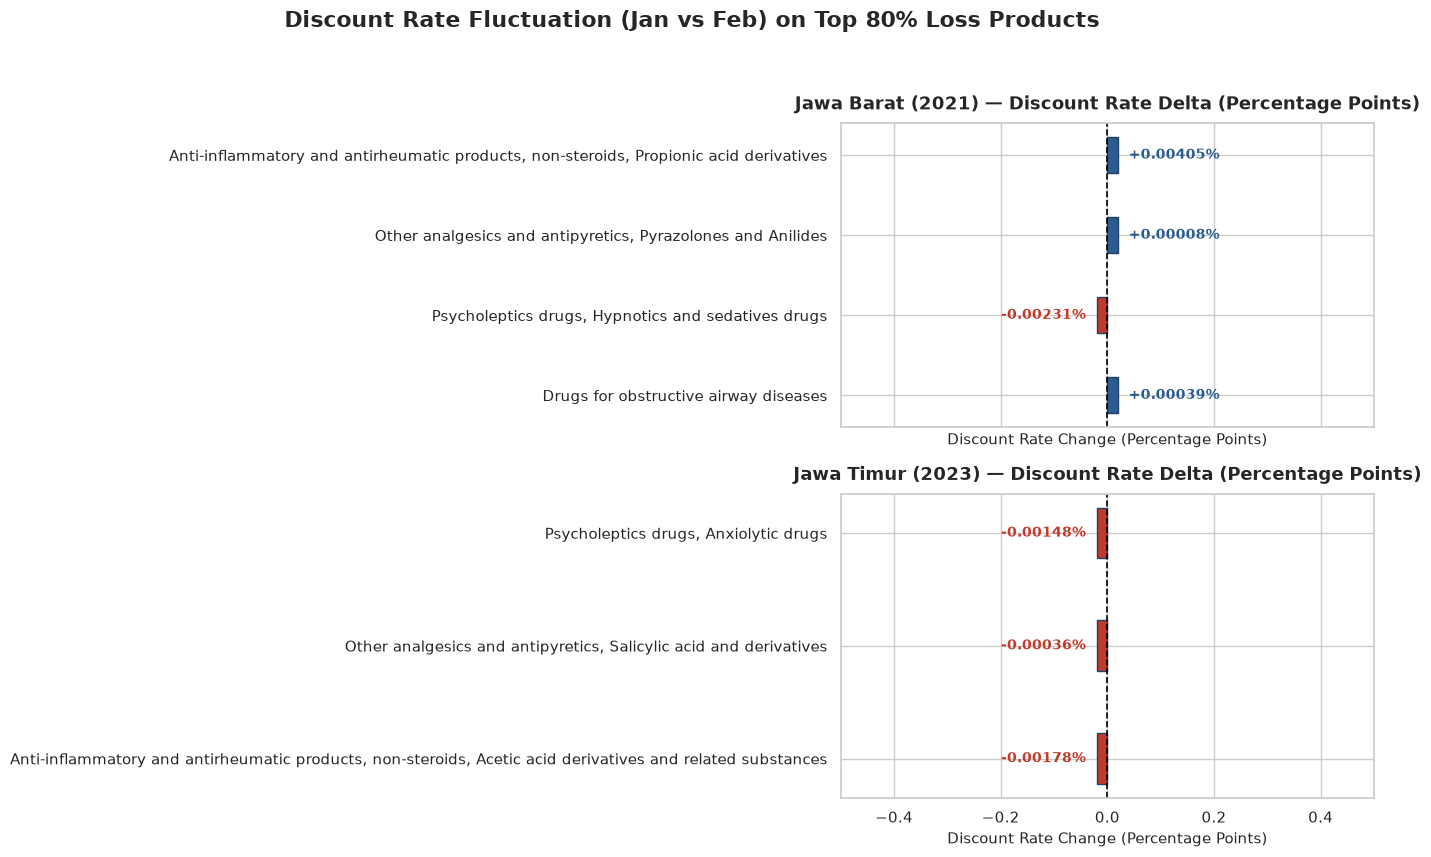

In [85]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# 1. Prepare Data
jabar_data = commercial_audit_summary[
    (commercial_audit_summary["provinsi"] == "Jawa Barat")
    & (commercial_audit_summary["year"] == 2021)
].sort_values("leaker_rank")

jatim_data = commercial_audit_summary[
    (commercial_audit_summary["provinsi"] == "Jawa Timur")
    & (commercial_audit_summary["year"] == 2023)
].sort_values("leaker_rank")

# 2. Create Figure & Subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 9), sharex=True)
fig.suptitle(
    "Discount Rate Fluctuation (Jan vs Feb) on Top 80% Loss Products",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

MIN_VISUAL_WIDTH = 0.02  # Minimal lebar bar visual agar terlihat jelas


def process_visual_and_labels(ax, df_data, title_text):
    visual_widths = []
    colors = []

    # Penentuan arah bar dan warna berdasarkan nilai plus/minus
    for val in df_data["discount_pct_delta"]:
        if val > 0:
            visual_widths.append(max(val, MIN_VISUAL_WIDTH))
            colors.append("#2b5c8f")  # Biru untuk nilai positif
        elif val < 0:
            visual_widths.append(min(val, -MIN_VISUAL_WIDTH))
            colors.append("#c0392b")  # Merah untuk nilai negatif
        else:
            visual_widths.append(
                MIN_VISUAL_WIDTH
            )  # Default bar visual untuk 0.00%
            colors.append("#2b5c8f")

    bars = ax.barh(
        df_data["product_name"],
        visual_widths,
        color=colors,
        height=0.45,
        edgecolor="#1f4268",
        linewidth=1,
    )

    ax.set_title(title_text, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Discount Rate Change (Percentage Points)", fontsize=11)
    ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
    ax.set_xlim(-0.5, 0.5)
    ax.invert_yaxis()

    # Data Labeling Presisi (Atur offset & alignment berdasarkan arah plus/minus)
    for bar, actual_val in zip(bars, df_data["discount_pct_delta"]):
        visual_w = bar.get_width()

        if actual_val < 0:
            text_x = visual_w - 0.02
            ha_align = "right"
            text_color = "#c0392b"
        else:
            text_x = visual_w + 0.02
            ha_align = "left"
            text_color = "#2b5c8f"

        ax.text(
            text_x,
            bar.get_y() + bar.get_height() / 2,
            f"{actual_val:+.5f}%",  # Format tanda +/- otomatis dengan 5 desimal
            va="center",
            ha=ha_align,
            fontsize=10,
            fontweight="bold",
            color=text_color,
        )


# ------------------------------------------------------------
# SUBPLOT 1: Jawa Barat (2021)
# ------------------------------------------------------------
process_visual_and_labels(
    axes[0],
    jabar_data,
    "Jawa Barat (2021) — Discount Rate Delta (Percentage Points)",
)

# ------------------------------------------------------------
# SUBPLOT 2: Jawa Timur (2023)
# ------------------------------------------------------------
process_visual_and_labels(
    axes[1],
    jatim_data,
    "Jawa Timur (2023) — Discount Rate Delta (Percentage Points)",
)

# Adjust spacing and layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save chart for presentation export
plt.savefig("discount_rate_change.png", dpi=300, bbox_inches="tight")
plt.show()

**Discount Analysis: Impact on Top Loss-Contributing Products**

An in-depth evaluation of pricing dynamics reveals that top-line performance drops across key loss-contributing therapeutic categories in **West Java (2021)** and **East Java (2023)** were directly driven by **unstrategic list price reductions**, rather than changes in promotional discounting.

**Flat Discount Rates Rule Out Promotional Leakage**

* **Zero Discount Fluctuation:** Discount rates remained flat and almost zero across all top-loss products, confirming that margin dilution was **not caused by aggressive promotional discounting**.
* **Pure Structural Pricing Issue:** Realized price decreasation was strictly driven by catalog list-price cuts rather than trade promotion spending.

> **Key Takeaway:** Realized selling price decline was driven strictly by structural catalog list price cuts rather than promotional discounting.

# **5. Conclusion**

### **1. Net Sales Decline Is Driven by Lower Transaction Volume**

* The decline in overall Net Sales closely follows a contraction in **transaction volume** rather than customer basket size.

* **Average Transaction Value (AOV)** remained relatively stable or increased across periods, indicating that customers are not reducing their spending per transaction.

* This means the main issue is **fewer transactions, rather than lower spending per transaction**.

* In other words, the business is still generating relatively stable value from each transaction, but **the number of transactions is declining**.

### **2. February Decline Is Explained by Calendar Effects**

* February recorded the **sharpest monthly transaction decline** across both years (2021 and 2023).

* However, February has only **28 days vs. 31 days**, representing a **9.68% reduction in operational days**.

* Daily transactions actually increased:

  * **2021 National:** +0.88% MoM
  * **2023 National:** +0.81% MoM

* Daily average sales also increased:

  * **2021 National:** +1.17% MoM
  * **2023 National:** +0.39% MoM

* Therefore, from the analysis, the underlying demand in February remained robust.

### **3. Daily Business Performance Remains Relatively Stable**

* When adjusting for the difference in the number of operating days, the apparent monthly decline becomes significantly less concerning.

* In both **2021 and 2023**, daily transaction volume and daily sales **increased from January to February**.

* **2021:**

  * Daily transactions: **+0.88% MoM**
  * Daily average sales: **+1.17% MoM**

* **2023:**

  * Daily transactions: **+0.81% MoM**
  * Daily average sales: **+0.39% MoM**

* This indicates that the underlying **daily business performance remained stable to positive**, despite the decline in total monthly transactions and Net Sales.

### **4. Loss Concentration in West Java (2021) & East Java (2023)**

* Provincial analysis isolates where top-line losses were geographically concentrated, ensuring commercial interventions target high-impact regions:

  * **West Java Focus (2021):** Identified as the driver of total Net Sales loss in 2021, combining high overall business baseline contribution with significant transaction volume drops.

  * **East Java Focus (2023):** Identified as the primary driver of total Net Sales loss in 2023, combining high overall business baseline contribution with significant transaction volume drops.

* Regional commercial recovery efforts must target **West Java for 2021 performance issues** and **East Java for 2023 performance issues**, as these two regions are the **main contributors to Net Sales and experienced Sales Loss**.

### **5. Branch Performance: The Decline Is Systemic, Not Branch-Specific**

* More than **50% of declining branches** were needed to explain approximately 80% of the total transaction decline:

  * **West Java:** 139 of 269 branches (**51.7%**)

  * **East Java:** 27 of 51 branches (**52.9%**)

* This indicates that the decline is **broadly distributed across the branches**, rather than concentrated in a small number of underperforming branches.

* Therefore, the issue is more likely to require a **regional and commercial-level response**, rather than focusing only on a few individual branches.

### **6. Branch Performance Analysis: High Branch Performance Does Not Translate into Higher Transaction Ratings**

* Overall branch performance remained strong, with average **Branch Ratings above 4.0**:

  * **West Java:** 4.45

  * **East Java:** 4.50

* However, **Transaction Ratings were lower than Branch Ratings**:

  * **West Java:** 4.00

  * **East Java:** 4.01

* Despite this rating gap, only a **small proportion of transactions received low ratings (≤3.0)**:

  * **West Java:** 2.14%

  * **East Java:** 2.36%

* The correlation between **Rating Gap and transaction decline** is close to zero (**-0.055 in West Java**, **0.058 in East Java**).

* Therefore, **branch/service quality is not supported as a key driver** of the transaction and Net Sales decline, and service quality should be **monitored but not treated as the primary root cause**.

### **7. Product Performance Analysis: Sales Decline Is Highly Concentrated in Key Product Categories**

* The decline is **not broad-based across the entire product portfolio**.

* A small number of high-revenue therapeutic categories contributed the majority of the sales loss.

* In **West Java (2021)**, only **4 products contributed ~80%** of the identified sales loss.

* In **East Java (2023)**, only **3 products contributed ~90%** of the identified sales loss.

* The key declining categories consistently included:
  * **Psycholeptics**
  * **Analgesics & Antipyretics**
  * **Anti-inflammatory & Antirheumatic products**
  * **Drugs for Obstructive Airway Diseases**

* This indicates that **key product performance is the area requiring attention**.

### **8. Inventory Analysis: Stock Availability Was Not the Primary Constraint**

* Inventory analysis was conducted for the key products contributing to the majority of sales loss in **West Java (2021)** and **East Java (2023)**.

* Average stock levels remained broadly stable from January to February, with stock changes ranging only from **-0.3% to -1.6%** across the analyzed products.

* **West Java (2021):**

  * *Drugs for obstructive airway diseases* recorded the smallest stock change at **-0.30%**, maintaining approximately **77 units** in February.
  * *Psycholeptics drugs, Hypnotics and sedatives drugs* recorded the largest stock reduction at **-1.50%**, while maintaining approximately **76 units** in February.
  * *Anti-inflammatory and antirheumatic products (Propionic acid derivatives)* declined by **-1.00%**, with approximately **77 units** remaining.
  * *Other analgesics and antipyretics (Pyrazolones and Anilides)* declined by **-1.40%**, with approximately **75 units** remaining.

* **East Java (2023):**
  * *Anti-inflammatory and antirheumatic products (Acetic acid derivatives)* recorded the largest stock reduction at **-1.60%**, while maintaining approximately **75 units** in February.
  * *Other analgesics and antipyretics (Salicylic acid derivatives)* declined by **-1.10%**, with approximately **77 units** remaining.
  * *Psycholeptics drugs (Anxiolytic drugs)* declined by **-0.80%**, while maintaining approximately **77 units** in February.

* Significant sales and transaction declines occurred while inventory levels remained relatively stable. This suggests that **stock availability was unlikely to be the primary constraint** behind the observed sales loss.

* Therefore, the evidence points away from a **supply-side failure** and toward **commercial and demand-side factors**.

### **9. Product Pricing and Discount Performance: Two-Way Commercial Failure Across Price Cuts and Hikes**

* Key loss-contributing products experienced unstrategic catalog pricing shifts, while central discount rates remained **flat (Δ ≈ 0.00%)**, confirming no promotional leakage.

* **Asymmetric Price Adjustments:**
  * **West Java (2021):** List price adjustments ranged from **-6.82% to +1.20%**.
    * The largest price drop occurred in *Other analgesics and antipyretics, Pyrazolones and Anilides*: **-6.82% list price** and **-6.63% realized selling price (after discount)**.
    * **Price Hike Anomaly:** *Psycholeptics drugs, Hypnotics and sedatives drugs* was the **only product to see a list price increase (+1.20%)**.
  * **East Java (2023):** Price cuts were significantly more aggressive across all top loss contributors:
    * *Anti-inflammatory and antirheumatic products:* **-13.31% list price** and **-9.67% realized selling price (after discount)**.
    * *Psycholeptics, Anxiolytic drugs:* **-9.54% list price** and **-9.67% realized selling price (after discount)**.

* **Commercial Inefficacy:**
  * **Failed Uplift on Price Cuts:** Broad list price reductions declining sales without generating sufficient transaction volume recovery.
  * **Volume Contraction on Price Hikes:** The isolated price increase on *Hypnotics & Sedatives* (+1.20%) coincided with a sharp drop in order frequency, contributing to top-line loss.

### **10. Key Root Cause: Sales Decline in High-Revenue Products Driven by Pricing Misalignment**

* The strongest evidence points to **lower transaction volume in specific high-revenue/key products** as the primary driver of the Net Sales decline.
* The decline is **systemic across the branches**, but the financial impact is **highly concentrated in specific product categories**.
* **Branch performance and service quality are not supported as key drivers** of the sales decline, with limited evidence of widespread low transaction ratings.
* **Daily business performance remains relatively stable**, suggesting that the monthly decline should not be interpreted solely as a deterioration in operational performance.
* **AOV remains relatively stable**, indicating that the problem is not primarily related to customers spending less per transaction.
* **Inventory availability does not appear to be the primary constraint**, as stock levels remained broadly stable across the key loss-contributing products.
* At the same time, **unstrategic pricing maneuvers appear to have been ineffective**: price cuts did not generate sufficient volume recovery, while isolated price hikes also contribute to sales decline.
* Therefore, the commercial focus should shift from **unilateral list-price adjustments** toward **recovering transaction volume in key products through structured trade programs while stabilizing prices**.

## **Overall Conclusion**

### **1. Commercial Root Cause: Volume Drop & Pricing Misalignment**
* Analysis confirms that **Net Sales decline is fundamentally driven by lower transaction volume**, with the financial impact heavily concentrated in key product categories across **West Java (2021)** and **East Java (2023)**.
* The decline is further associated with **unstrategic pricing adjustments**, where both price cuts failed to generate the transactions volume and price increases declining the sales.

### **2. Operational & Service Quality Excluded**
* **Service quality and branch performance are not supported as key drivers** of the decline.
* **Inventory availability is unlikely to be the primary constraint**, as stock levels remained broadly stable across the key loss-contributing products.
* **Calendar effects explain a substantial portion of the apparent February-to-January monthly decline**, while daily transaction and sales performance remained stable to positive.

### **3. Demand Contraction Requires Field Market Intelligence**
* Internal data confirms a **decline in transaction volume**, but the exact external driver cannot be fully established from internal transaction data alone.
* Potential external factors requiring field validation include:
  * **Competitor price movements / price wars**
  * **Pharmacy credit limits or purchasing constraints**
  * **Customer demand shifts**
  * **Competitor product substitution**
  * **Local market or physician prescribing changes**

* Therefore, the next step should be **field market intelligence and commercial validation** to determine why customers reduced purchase frequency despite relatively stable AOV and inventory availability.

### **Final Takeaway**
> **The sales decline is primarily a volume problem, not a stock availability problem.**
> **The financial impact is concentrated in a small number of products and regions, with unstrategic pricing adjustments emerging as a key commercial factor.** 
> **The next priority is to identify the external demand drivers behind the transaction decline and recover volume through targeted commercial actions.**


## **Root Cause Analysis (RCA) Summary**

| **Analysis**                                | **Result**                 | **Key Finding**                                                                                                                                                                                                                                                                                           |
| ------------------------------------------- | -------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Overall Net Sales Decline**               | 🔴 **Confirmed**           | Net Sales declined in **West Java (2021)** and **East Java (2023)**, confirming the primary business issue requiring further investigation.                                                                                                                                                               |
| **Service Quality / Branch Rating**         | 🟢 **Not a Key Driver**    | The correlation between rating gap and transaction decline is close to zero (≈0), indicating that **branch/service quality does not explain the transaction decline**.                                                                                                                                    |
| **Branch / Location-Specific Issues**       | 🟢 **Not a Key Driver**    | The decline is **systemic across branches**, with more than **50% of declining branches** contributing to approximately 80% of the transaction decline, rather than being concentrated in a few locations.                                                                                                |
| **February Transaction Drop**               | 🟢 **Calendar Effect**     | The monthly decline is largely explained by **fewer operating days (28 vs. 31 days)**, while daily transactions and daily average sales remained **stable to positive**.                                                                                                                                  |
| **Central Discount Changes**                | 🟢 **Not a Key Driver**    | **Discount rates remained relatively stable**, indicating that the Net Sales decline was not primarily driven by changes in promotional discounting.                                                                                                                                                      |
| **AOV / Customer Spending per Transaction** | 🟢 **Not a Key Driver**    | AOV remained relatively stable, indicating **no significant deterioration in customer spending per transaction**.                                                                                                                                                                                         |
| **Product Portfolio-Wide Decline**          | 🟢 **Not Broad-Based**     | The Net Sales decline is **highly concentrated in specific high-revenue product categories**, rather than being spread across the entire portfolio.                                                                                                                                                       |
| **Inventory / Stock Availability**          | 🟢 **Not a Key Driver**    | Stock levels across key loss-contributing products remained **broadly stable**, indicating that **stock availability was unlikely to be the primary constraint** behind the sales decline.                                                                                                                |
| **Transaction Volume in Key Products**      | 🔴 **Contributing Factor**          | **Lower transaction volume in key high-revenue products** is the strongest identified driver of the Net Sales decline.                                                                                                                                                                                    |
| **Unstrategic Pricing Adjustment**            | 🔴 **Contributing Factor**  | Significant **list price adjustments in key loss-contributing products** did not generate sufficient volume recovery. Price cuts reduced realized selling prices without delivering adequate transaction uplift, while the isolated price also contributes to sales decline. |


## **Recommendation**

| **Key Finding / Root Cause**                                | **Recommended Action**                                                                                                                                                                                                                                                            |
| ----------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Impact concentrated in West Java & East Java**            | Prioritize **West Java and East Java** for targeted commercial recovery initiatives, focusing resources on the regions with the highest financial impact.                                                                                                                         |
| 🔴 **Low transaction volume in key products**               | Prioritize **key product recovery** through targeted trade programs and promotions designed to **rebuild transaction volume** rather than broad-based discounting.                                                                                                                |
| 🔴 **Pricing Adjustment**                                 | Avoid **broad price cuts or isolated price increases** and establish a **structured pricing framework / minimum price floor** to protect revenue and margins while maintaining market competitiveness.                                                                            |
| 🟠 **Price cuts did not generate sufficient volume uplift** | Implement **product-level price sensitivity monitoring** to identify products where price adjustments can effectively stimulate transaction volume and where price reductions should be avoided.                                                                                  |
| 🟡 **External demand drivers remain unconfirmed**           | Conduct **field market intelligence and commercial validation** to investigate potential drivers such as **competitor price movements, pharmacy credit constraints, customer demand shifts, competitor product substitution, and local market or physician prescribing changes**. |


### **1. Prioritize Recovery of Key Loss-Contributing Products**

* **Focus Commercial Resources:** Direct commercial efforts specifically toward high-revenue products experiencing the sharpest transaction and sales declines, particularly **Psycholeptics, Analgesics & Antipyretics, Anti-inflammatory, and Obstructive Airway drugs**.

* **Multi-Factor Prioritization:** Evaluate SKUs based on core metrics:

  * **Sales Loss Contribution**
  * **Transaction Volume Contraction**
  * **Overall Revenue Contribution**

* **Targeted Allocation:** Prioritize products with **high revenue baseline + high transaction decline** to maximize potential sales recovery.

### **2. Establish Disciplined Catalog Pricing**

* **Avoid Unnecessary Price Cuts:** Stop using broad catalog price reductions as the default strategy, particularly for products where previous price cuts **did not generate sufficient transaction volume recovery**. Establish a clear **minimum price floor** to protect Net Sales and margins.

* **Re-evaluate Unmanaged Price Hikes:** Review isolated list price increases, such as *Hypnotics & Sedatives* at **+1.20%** in West Java, which **coincided with a sharp decline in transaction volume**. Ensure future price increases are supported by clear value propositions, competitive benchmarking, or trade support.

### **3. Shift from Permanent Price Cuts to Targeted Commercial Promotions & Incentives**

* **Replace Permanent Catalog Reductions:** Transition away from permanent list-price changes toward flexible, performance-driven trade programs:

  * **Volume-Based Tiered Discounts:** Offer incremental incentives based on order volume or basket size. This can encourage larger purchases without permanently lowering baseline catalog prices.
  * **Strategic Product Bundling:** Pair high-performing anchor products with declining categories to stimulate demand for products such as **Psycholeptics or Analgesics & Antipyretics**, while preserving standalone catalog prices.
  * **Pharmacy & Healthcare Facility Incentives:** Deploy tailored commercial incentives for independent pharmacies, chains, and clinics, such as payment-term support or point-of-sale initiatives, **where commercially and financially feasible**.
  * **Performance-Based Channel Rebates:** Offer post-period rebates or credit notes to channel partners upon achieving predefined volume targets. This can preserve upfront catalog pricing while encouraging partners to actively drive volume.

* **Segment-Specific Deployment:** Apply promotions selectively to **high-potential channels, accounts, and products** to increase order frequency while maintaining stable baseline catalog prices.

### **4. Implement Product-Level Price Sensitivity & Promotion Effectiveness Monitoring**

* **Establish Regular Performance Reviews:** Track price changes against **transaction volume, Net Sales, realized selling price, and margin** on a regular basis.

* **Segment Products Based on Observed Price Response:**

  * **Low Response to Price Cuts:** Avoid further discounting products where previous price reductions contribute to sales decline and also failed to generate sufficient transaction volume uplift.
  * **High Price Sensitivity:** Exercise caution when increasing prices for products because it also contributes to sales decline.

* **Measure Promotion Effectiveness:** Evaluate whether each promotion generates sufficient **incremental transaction volume and Net Sales** to justify the associated margin impact.

* **Reallocate Resources:** Continuously shift commercial effort and promotional spend toward **products, channels, and programs that demonstrate measurable volume recovery**.

### **5. Prioritize West Java and East Java for Regional Commercial Recovery**

* **Regional Focus:** Concentrate initial commercial recovery initiatives in **West Java (2021 focus)** and **East Java (2023 focus)**, where the financial impact of the transaction decline was most significant.

* **Regional Product Priorities:**

  * **West Java:** Focus recovery on **Anti-inflammatory, Analgesics & Antipyretics, Psycholeptics (including Hypnotics & Sedatives), and Obstructive Airway** categories.
  * **East Java:** Focus recovery on **Psycholeptics (Anxiolytics), Analgesics & Antipyretics, and Anti-inflammatory** categories.

* **Accountability Targets:** Establish explicit and measurable targets for **transaction volume, Net Sales, and promotion effectiveness** for each regional priority product.

* **Performance Monitoring:** Review progress regularly and reallocate commercial resources toward products and regions demonstrating the strongest recovery potential.

### **6. Conduct Field Market Intelligence to Validate External Demand Drivers**

* **Validate Demand Contraction:** Internal data confirms a **decline in transaction volume**, but the exact external drivers cannot be fully established from transaction data alone.

* **Investigate Potential External Factors:** Conduct field validation to assess potential drivers, including:

  * **Competitor price movements / price wars**
  * **Pharmacy credit limits or purchasing constraints**
  * **Customer demand shifts**
  * **Competitor product substitution**
  * **Local market or physician prescribing changes**

* **Gather Commercial Insights:** Engage sales teams, pharmacy customers, healthcare facilities, and relevant commercial stakeholders to understand changes in **purchase frequency, competitor activity, pricing perception, and product preference**.

* **Translate Findings into Actions:** Use field intelligence to determine whether the transaction decline is primarily driven by **pricing competitiveness, demand changes, purchasing constraints, or product substitution**, and adjust pricing, promotion, and commercial strategies accordingly.

* **Continuous Validation:** Integrate field market intelligence with internal transaction, pricing, inventory, and promotion data to continuously refine the **commercial recovery strategy**.